# V1 House — collecte & validation, refaites au propre

**But.** Reconstruire de bout en bout la chaîne de récupération des données de la **Chambre
des représentants** (2014-2026) dans un seul notebook auto-suffisant, et la **valider de
l'intérieur** — sans source externe. Ce notebook est aussi un audit de l'ancien pipeline
(`00_S1S2_donnees/`) : à la fin, chaque écart entre les deux est expliqué.

**Périmètre.** Chambre seule · 2014-2026 · piste **électronique** (les documents scannés
sont recensés et classés, leur OCR viendra en V2).

**Le chemin de la donnée** (chaque section = une étape) :

| § | Étape | Sortie |
|---|---|---|
| 1 | Les index annuels (ZIP → XML) — et leur périssabilité | `01_recensement_depots.csv` |
| 2 | Anatomie d'un DocID (numérique / scanné, URLs) | — |
| 3 | Le ledger : un statut par dépôt | `02_ledger_docs.csv` (squelette) |
| 4 | Remplir le cache PDF (idempotent) | `03_pdf_inventory.csv` |
| 5 | PDF → texte + double classification | `cache/text/` |
| 6 | La grille des fourchettes de montant | (définition) |
| 7 | Parseur Schedule B des PTR | transactions brutes |
| 8 | Rapports FD : Schedule A (patrimoine) et B | `05_holdings_v1.csv` |
| 9 | Identité : du nom au `bioguide_id` | `06_identites_v1.csv` |
| 10 | Assemblage + déduplication unique | `04_transactions_v1.csv` |
| 11 | Validations internes | registre |
| 12 | Comparaison à l'ancien pipeline | entonnoir des écarts |
| 13 | Tableau de bord | `MANIFEST.json` |

**Règle d'or des chiffres** — leçon d'un incident réel : « 71 % électronique » (par
*document*, PTR seuls) et « ~50/50 papier » (par *transaction*, tous types, 2 chambres)
décrivent le même corpus sans se contredire. Ici, **aucun ratio ne s'affiche sans ses
trois étiquettes : unité × périmètre × fenêtre.**

## Lexique (tout terme est défini avant usage)

- **Dépôt** (*filing*) : un document déposé auprès du Clerk de la Chambre. Chaque dépôt a un
  identifiant unique, le **DocID**.
- **Index annuel** : le fichier `{Y}FD.xml` (livré dans `{Y}FD.zip`) qui liste TOUS les dépôts
  de l'année `Y` — c'est la **liste officielle exhaustive**, notre vérité terrain.
- **Instantané** : notre copie des 13 index, figée début juillet 2026
  (`00_S1S2_donnees/data/house/index/`). Le site **purge** les vieux index (§1.2) : cet
  instantané est la seule trace complète de 2014.
- **FilingType** : le type du dépôt, une lettre (P, O, C, H, T, A, X, D, W, G, E, B) — détail en §1.
- **PTR** (*Periodic Transaction Report*, type `P`) : la déclaration d'une ou plusieurs
  transactions boursières, due sous **45 jours** (STOCK Act).
- **Schedule A / B** : les sections d'un rapport financier — `A` = actifs détenus
  (patrimoine), `B` = transactions de la période. Un PTR ne contient que des transactions.
- **Numérique** : dépôt saisi en ligne → PDF avec couche texte extractible.
  **Scanné** : dépôt papier numérisé → image, il faudrait de l'OCR (hors V1).
- **`disclosure_date`** : la date de dépôt (champ `FilingDate` de l'index) — c'est la date
  à partir de laquelle l'information est PUBLIQUE (axe anti-look-ahead).
- **Ledger** : notre registre de disposition — une ligne par DocID, un statut final chacun.

In [1]:
# ── §0.1 Configuration ────────────────────────────────────────────────────────
# Tout est relatif au dossier du notebook (01_v1_house/). Aucun import du vieux code.
import hashlib, io, json, os, random, re, shutil, time, unicodedata, zipfile
import xml.etree.ElementTree as ET
from collections import Counter
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import requests

CACHE   = Path("cache")
TABLES  = CACHE / "tables"
REFERENCE = Path("reference")                      # données de référence VERSIONNÉES (autonomie)
ANCIEN  = Path("..") / "00_S1S2_donnees"          # l'ancien pipeline — SEULEMENT pour §12 (audit)
ANNEES  = list(range(2014, 2027))                  # 2014..2026, bornes incluses
TYPES_PARSES = {"P", "O", "H", "T", "A", "C"}      # types téléchargés/parsés en V1
TYPES_HORS_PERIMETRE = {"X", "D", "W", "G", "E"}   # administratifs, pas de Schedule B
                                                   # B (blind trust) traité à part en §3
# Flags du run
PREFILL_FROM_OLD = True    # copier ce qui existe déjà (ancien cache, PoC) avant de télécharger
FULL_REDOWNLOAD  = False   # True = preuve complète : re-télécharger les PDF dans cache_full_<date>/
INCLURE_C        = True    # la tranche C (8 524 candidats) est séparable
N_PREUVE_SHA     = 20      # re-téléchargements aléatoires comparés par sha à chaque run

BASE = "https://disclosures-clerk.house.gov/public_disc"
URL_INDEX_ZIP = BASE + "/financial-pdfs/{year}FD.zip"
URL_PDF_PTR   = BASE + "/ptr-pdfs/{year}/{doc_id}.pdf"        # type P uniquement
URL_PDF_FD    = BASE + "/financial-pdfs/{year}/{doc_id}.pdf"  # tous les autres types

HTTP = requests.Session()
HTTP.headers["User-Agent"] = "Mozilla/5.0 (recherche universitaire; contact: alicelemaire2006@icloud.com)"
PAUSE_S = 0.4              # politesse entre deux requêtes

for d in (CACHE / "index", CACHE / "index_instantane", CACHE / "pdfs", CACHE / "text", TABLES):
    d.mkdir(parents=True, exist_ok=True)
print("cache :", CACHE.resolve())

cache : /Users/lemairealice/Downloads/Jupiter/.claude/worktrees/v1-house/01_v1_house/cache


In [2]:
# ── §0.2 Le registre de validations ──────────────────────────────────────────
# Chaque contrôle du notebook s'enregistre ici ; le §13 en fait le tableau de bord.
# Deux niveaux : BLOQUANT (assert, le notebook s'arrête) et CONTRÔLE (verdict, on continue).
REGISTRE = []

def _verdict(valeur, vert, orange, sens):
    if vert is None:
        return "INFO"
    ok = (valeur >= vert) if sens == ">=" else (valeur <= vert)
    if ok:
        return "VERT"
    if orange is not None:
        presque = (valeur >= orange) if sens == ">=" else (valeur <= orange)
        if presque:
            return "ORANGE"
    return "ROUGE"

def valider(vid, nom, valeur, *, unite, perimetre, fenetre="2014-2026",
            vert=None, orange=None, sens=">=", bloquant=False, section=""):
    """Enregistre un contrôle. unite ∈ {'document','transaction','holding',
    'position-ticker','membre','paire-annuels'} ; perimetre et fenetre TOUJOURS explicites."""
    v = _verdict(valeur, vert, orange, sens)
    REGISTRE.append(dict(id=vid, nom=nom, valeur=valeur, unite=unite, perimetre=perimetre,
                         fenetre=fenetre, seuil_vert=vert, sens=sens, verdict=v,
                         bloquant=bloquant, section=section))
    icone = {"VERT": "🟢", "ORANGE": "🟠", "ROUGE": "🔴", "INFO": "ℹ️"}[v]
    print(f"{icone} [{vid}] {nom} = {valeur}  ({unite} · {perimetre} · {fenetre})")
    if bloquant:
        assert v in ("VERT", "INFO"), f"{vid} BLOQUANT : {nom} = {valeur}"
    return v

def pct(num, den):
    """Pourcentage arrondi à 1 décimale (den=0 → NaN)."""
    return round(100.0 * num / den, 1) if den else float("nan")

print("registre prêt — aucun ratio sans ses trois étiquettes (unité × périmètre × fenêtre)")

registre prêt — aucun ratio sans ses trois étiquettes (unité × périmètre × fenêtre)


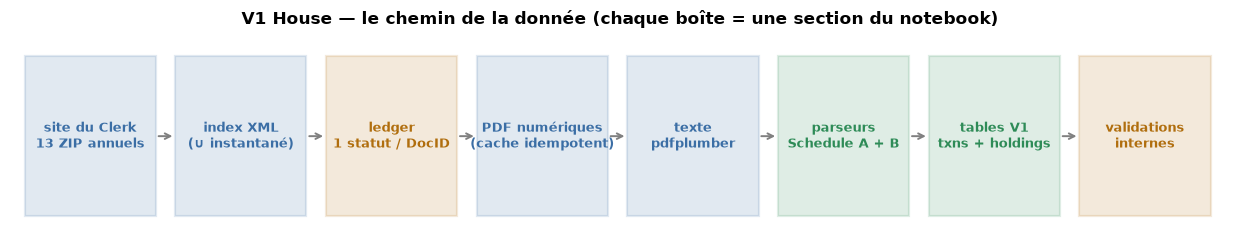

In [3]:
# ── §0.3 Le chemin de la donnée, en un schéma ─────────────────────────────────
fig, ax = plt.subplots(figsize=(12.5, 2.6)); ax.axis("off")
etapes = [("site du Clerk\n13 ZIP annuels", "#3B6EA5"), ("index XML\n(∪ instantané)", "#3B6EA5"),
          ("ledger\n1 statut / DocID", "#B06E0E"), ("PDF numériques\n(cache idempotent)", "#3B6EA5"),
          ("texte\npdfplumber", "#3B6EA5"), ("parseurs\nSchedule A + B", "#2E8B57"),
          ("tables V1\ntxns + holdings", "#2E8B57"), ("validations\ninternes", "#B06E0E")]
for i, (t, c) in enumerate(etapes):
    ax.add_patch(plt.Rectangle((i * 1.55, 0), 1.35, 1, fc=c, alpha=.15, ec=c, lw=1.6))
    ax.text(i * 1.55 + 0.675, 0.5, t, ha="center", va="center", fontsize=9.5, color=c, fontweight="bold")
    if i:
        ax.annotate("", xy=(i * 1.55, 0.5), xytext=(i * 1.55 - 0.2, 0.5),
                    arrowprops=dict(arrowstyle="->", color="gray", lw=1.4))
ax.set_xlim(-0.15, len(etapes) * 1.55); ax.set_ylim(-0.15, 1.15)
ax.set_title("V1 House — le chemin de la donnée (chaque boîte = une section du notebook)",
             fontsize=12, fontweight="bold")
plt.tight_layout(); plt.show()

## §1 — Les index annuels : la liste officielle… qui s'efface

Le Clerk publie chaque année une archive `{Y}FD.zip` contenant `{Y}FD.xml` : **un bloc
`<Member>` par dépôt**, avec 9 champs (`Prefix, Last, First, Suffix, FilingType, StateDst,
Year, FilingDate, DocID`). On télécharge les 13 archives (le ZIP est gardé comme preuve
brute) et on conserve **les 9 champs** — l'ancien pipeline en jetait trois (`Prefix`,
`Suffix`, `Year`) ; or `Suffix` (Jr/Sr/III) sert à départager les homonymes.

Trois règles, dont une découverte le jour de l'écriture de ce notebook :

1. **L'index annuel est l'autorité d'appartenance** d'un dépôt à l'année. On ne filtre
   **jamais** par fenêtre de dates civile : un ancien filtre de ce genre avait perdu
   **205 PTR** déposés après le 31/12 (retards légitimes, jusqu'à +3 ans).
2. Le champ `Year` (année de couverture déclarée) est conservé mais l'appartenance vient
   du **fichier** : `annee_index`.
3. **La source primaire est périssable.** Le 2026-07-13, l'index 2014 re-téléchargé ne
   contient plus que **11 dépôts** au lieu de 2 788 : le Clerk purge les index au-delà
   de la fenêtre de rétention (~6 ans, STOCK Act). Les **PDF restent servis** — mais la
   *liste de ce qu'il faut demander* ne vit plus que dans notre **instantané** de début
   juillet 2026. Le recensement V1 est donc l'**union** {site aujourd'hui} ∪ {instantané},
   chaque ligne tracée par sa source.

In [4]:
# ── §1.1 Téléchargement idempotent des 13 index + ingestion de l'instantané ──
def telecharger(url, timeout=60, essais=3):
    """GET avec retries simples ; renvoie (bytes, status_code)."""
    for k in range(essais):
        try:
            r = HTTP.get(url, timeout=timeout)
            if r.status_code == 200:
                return r.content, 200
            if r.status_code == 404:
                return b"", 404
        except requests.RequestException:
            pass
        time.sleep(1.5 * (k + 1))
    return b"", -1

sha_index = {}
for y in ANNEES:
    zp = CACHE / "index" / f"{y}FD.zip"
    xp = CACHE / "index" / f"{y}FD.xml"
    if not zp.exists():
        data, st = telecharger(URL_INDEX_ZIP.format(year=y))
        assert st == 200 and data[:2] == b"PK", f"échec ZIP {y} (HTTP {st})"
        zp.write_bytes(data)
        time.sleep(PAUSE_S)
    if not xp.exists():
        with zipfile.ZipFile(zp) as z:
            nom_xml = [n for n in z.namelist() if n.lower().endswith(".xml")]
            assert len(nom_xml) == 1, f"{y} : {len(nom_xml)} XML dans le ZIP"
            xp.write_bytes(z.read(nom_xml[0]))
    sha_index[f"site_{y}"] = hashlib.sha256(xp.read_bytes()).hexdigest()

# l'instantané (figé début juillet 2026) est VERSIONNÉ dans reference/ — irremplaçable
for y in ANNEES:
    p_inst = REFERENCE / "index_instantane" / f"{y}FD.xml"
    sha_index[f"instantane_{y}"] = hashlib.sha256(p_inst.read_bytes()).hexdigest()

print(f"{len(ANNEES)} index « site » + {len(ANNEES)} index « instantané » en cache")

13 index « site » + 13 index « instantané » en cache


In [5]:
# ── §1.2 Parsing des deux jeux d'index → recensement = UNION tracée ──────────
CHAMPS = ["Prefix", "Last", "First", "Suffix", "FilingType", "StateDst", "Year", "FilingDate", "DocID"]

def parse_index(path, annee):
    root = ET.fromstring(path.read_bytes())
    rows = []
    for m in root.findall("Member"):
        d = {ch.lower(): (m.findtext(ch) or "").strip() for ch in CHAMPS}
        d["annee_index"] = annee
        rows.append(d)
    return rows

site, instantane = [], []
for y in ANNEES:
    site += parse_index(CACHE / "index" / f"{y}FD.xml", y)
    instantane += parse_index(REFERENCE / "index_instantane" / f"{y}FD.xml", y)
S = pd.DataFrame(site).rename(columns={"docid": "doc_id", "filingtype": "filing_type",
                                       "statedst": "state_district"})
I = pd.DataFrame(instantane).rename(columns={"docid": "doc_id", "filingtype": "filing_type",
                                             "statedst": "state_district"})

# L'instantané est notre référence STABLE : ses comptes sont prouvés et figés.
assert len(I) == 35315, f"instantané : attendu 35 315, lu {len(I)}"
attendu = {"C": 10105, "P": 8252, "X": 5844, "O": 4625, "A": 2298, "D": 2196,
           "W": 1099, "H": 395, "T": 392, "G": 51, "E": 35, "B": 23}
assert dict(I["filing_type"].value_counts()) == attendu, "comptes par type inattendus (instantané)"

# UNION par (doc_id, annee_index) : le site d'aujourd'hui, complété par ce qu'il a purgé.
cle = ["doc_id", "annee_index"]
idx_S, idx_I = S.set_index(cle).index, I.set_index(cle).index
purges   = I[~idx_I.isin(idx_S)]          # dans l'instantané, plus sur le site
nouveaux = S[~idx_S.isin(idx_I)]          # sur le site, pas dans l'instantané (dépôts récents)
recensement = pd.concat([S.assign(source="site"),
                         purges.assign(source="instantane_seul")], ignore_index=True)

print(f"site aujourd'hui : {len(S):,} · instantané : {len(I):,} · union : {len(recensement):,}")
print(f"purgés du site   : {len(purges):,}  (années : {sorted(purges['annee_index'].unique())})")
print(f"nouveaux du site : {len(nouveaux):,}  (années : {sorted(nouveaux['annee_index'].unique())})")
# Les « nouveaux » légitimes sont de deux natures (vérifié ligne à ligne) :
#  (a) dépôts récents, postérieurs à l'instantané (annee_index ≥ 2024, FilingDate juillet 2026+) ;
#  (b) vieux dossiers PAPIER re-publiés dans un index purgé (préfixe 7/8/9 — ex. 7 staffers 2014).
assert set(purges["annee_index"]) <= {2014}, "purge inattendue hors 2014 — investiguer !"
recents     = nouveaux["annee_index"] >= 2024
vieux_scans = nouveaux["doc_id"].str[0].isin({"7", "8", "9"})
assert (recents | vieux_scans).all(), "ajout ni récent ni papier-republié — investiguer !"
n_p_nouveaux = int((nouveaux["filing_type"] == "P").sum())
print(f"dont {n_p_nouveaux} nouveaux PTR (P) absents de l'ancien pipeline — la V1 est plus fraîche")

recensement["filing_date"] = pd.to_datetime(recensement["filingdate"], errors="coerce")
recensement["prefixe_docid"] = recensement["doc_id"].str[:1]

# Réalité des index (mesurée, pas idéalisée) :
#  - FilingDate peut être VIDE, mais uniquement sur des types administratifs (W/D/X/E) ;
#  - le DocID fait 7-8 chiffres, SAUF les W numériques : 4 chiffres commençant par 6.
# Les types à contenu (P/C/O/H/T/A) sont, eux, toujours complets — on l'exige.
en_perimetre = recensement["filing_type"].isin(TYPES_PARSES)
sans_date = recensement["filing_date"].isna()
assert not (en_perimetre & sans_date).any(), "FilingDate manquante sur un type en périmètre !"
print(f"FilingDate vide : {int(sans_date.sum())} lignes, toutes hors périmètre — "
      f"{dict(recensement.loc[sans_date, 'filing_type'].value_counts())}")
assert recensement.loc[en_perimetre, "doc_id"].str.fullmatch(r"\d{7,8}").all(), \
    "DocID hors format sur un type en périmètre !"
assert recensement["doc_id"].str.fullmatch(r"\d{4,8}").all(), "DocID totalement hors format"

recensement.drop(columns=["filingdate"]).to_csv(TABLES / "01_recensement_depots.csv", index=False)
print(f"\nrecensement UNION : {len(recensement):,} dépôts · "
      f"{recensement['doc_id'].nunique():,} DocID uniques")
print(f"écrit → {TABLES/'01_recensement_depots.csv'}")

site aujourd'hui : 32,593 · instantané : 35,315 · union : 35,377
purgés du site   : 2,784  (années : [np.int64(2014)])
nouveaux du site : 62  (années : [np.int64(2014), np.int64(2024), np.int64(2025), np.int64(2026)])
dont 15 nouveaux PTR (P) absents de l'ancien pipeline — la V1 est plus fraîche
FilingDate vide : 694 lignes, toutes hors périmètre — {'W': np.int64(651), 'D': np.int64(37), 'X': np.int64(5), 'E': np.int64(1)}

recensement UNION : 35,377 dépôts · 35,359 DocID uniques
écrit → cache/tables/01_recensement_depots.csv


> **⚠️ Découverte V1 — la source primaire s'efface.** Entre début juillet 2026 (instantané)
> et aujourd'hui, le Clerk a **purgé 2 777 des 2 788 dépôts de l'index 2014** (fenêtre de
> rétention du STOCK Act). Les PDF 2014, eux, répondent encore — vérifié — mais sans la
> liste des DocID, on ne saurait plus *quoi* demander. Conséquences :
> 1. l'**instantané des index est un actif critique** (versionné dans l'ancien dépôt,
>    copié dans ce cache) ;
> 2. le mode « preuve complète » (`FULL_REDOWNLOAD`) reste possible pour les **PDF**, mais
>    plus pour les **index** ≤ 2014 — et 2015 tombera à son tour ;
> 3. chaque ligne du recensement porte sa `source` (`site` / `instantane_seul`) ;
> 4. l'index bouge **dans les deux sens** : le site d'aujourd'hui apporte aussi ~55 dépôts
>    déposés après l'instantané (dont ~15 nouveaux PTR) et 7 vieux dossiers papier 2014
>    re-publiés — l'union capture tout.

> **La base légale de la purge — vérifiée (2026-07-13).** La loi fédérale
> ([5 U.S.C. §13107(d)](https://www.law.cornell.edu/uscode/text/5/13107), ex-Ethics in
> Government Act §105(d)) impose une durée de vie aux déclarations : publiques
> « *for a period of 6 years after receipt* » pour les candidats et employés, et
> « *until a date that is 6 years from the date the individual ceases to be a Member
> of Congress* » pour les élus — après quoi « *the report shall be destroyed* ».
>
> **Ce qu'on observe** (§1.2, colonne `source` du recensement) : la purge est appliquée
> **par année d'index entière, en retard sur la loi** — l'index **2014 est effacé à
> 99,6 %** (2 784 dépôts ne survivent que dans `reference/index_instantane/`, 11 reliquats
> hétéroclites côté site : dépôts papier d'avril-mai 2014, types A/O/T, élus et employés
> mêlés), tandis que **2015→2026 sont encore servis à 100 %** (re-vérifié en direct le
> 2026-07-13 : `2015FD.xml` = 2 297/2 297). Chaque année tombera à son tour : la liste
> 2014 n'existe plus **nulle part ailleurs** que dans ce dépôt.

In [6]:
# ── §1.3 Les doublons de DocID inter-index : qui sont-ils ? ───────────────────
# L'union compte les dépôts listés dans DEUX index d'années différentes (même DocID).
# L'ancien code affirmait « zéro chevauchement » — vérifions factuellement.
dup_ids = recensement.loc[recensement["doc_id"].duplicated(keep=False)].sort_values(
    ["doc_id", "annee_index"])
print(f"{len(dup_ids)} lignes concernées ({dup_ids['doc_id'].nunique()} DocID en double) :")
display(dup_ids[["doc_id", "last", "first", "filing_type", "annee_index", "year",
                 "filing_date", "source"]])

# Verdict factuel : même dépôt (mêmes champs) listé dans deux index consécutifs.
# Règle V1 : le RECENSEMENT reste fidèle aux fichiers (toutes les lignes) ; le LEDGER (§3)
# aura UNE ligne par DocID — on garde la 1re apparition (annee_index la plus ancienne).
recensement["doublon_index"] = recensement.sort_values("annee_index")["doc_id"].duplicated(keep="first")
recensement.sort_index(inplace=True)
meme_type = (dup_ids.groupby("doc_id")["filing_type"].nunique() == 1).all()
valider("L2a", "DocID listés dans deux index (lignes doublonnées)",
        int(recensement["doublon_index"].sum()),
        unite="document", perimetre="tous types, House", vert=25, sens="<=", section="§1.3")
print(f"tous les doublons portent le même FilingType des deux côtés : {meme_type}")

35 lignes concernées (17 DocID en double) :


,doc_id,last,first,filing_type,annee_index,year,filing_date,source
35008,10004456,Spees,Kristen,A,2014,2014,2014-10-01,instantane_seul
35009,10004456,Spees,Kristen,A,2014,2014,2014-10-01,instantane_seul
1478,10008220,Mowery,Tod,C,2015,2015,2015-07-14,site
1479,10008220,Mowery,Tod,C,2015,2015,2015-07-14,site
35046,10008372,Stutzman,Marlin A.,O,2014,2014,2015-08-09,instantane_seul
35047,10008372,Stutzman,Marlin A.,O,2014,2014,2015-08-09,instantane_seul
2617,10012045,Cain,Emily,C,2016,2016,2016-05-15,site
2618,10012045,Cain,Emily,C,2016,2016,2016-05-15,site
7243,10014455,Neugebauer,Randy,T,2017,2017,2017-02-17,site
7244,10014455,Neugebauer,Randy,T,2017,2017,2017-02-17,site


🟢 [L2a] DocID listés dans deux index (lignes doublonnées) = 18  (document · tous types, House · 2014-2026)
tous les doublons portent le même FilingType des deux côtés : True


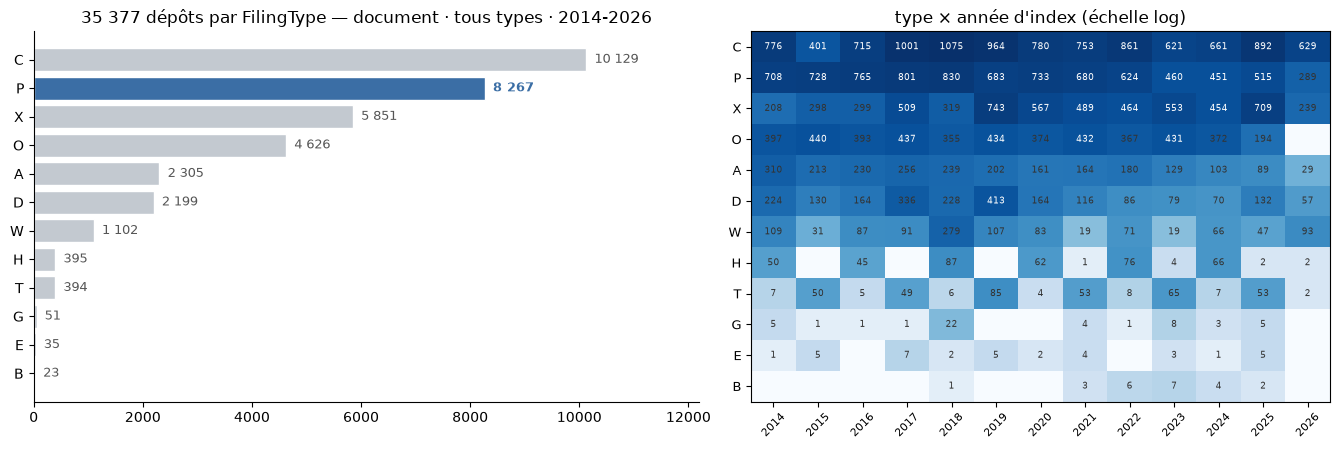

In [7]:
# ── §1.4 Figures : les 12 types, et leur répartition dans le temps ────────────
fig, axes = plt.subplots(1, 2, figsize=(13.5, 4.6), gridspec_kw={"width_ratios": [1.15, 1]})
o = recensement["filing_type"].value_counts()
couleurs = ["#3B6EA5" if t == "P" else "#c3c9d0" for t in o.index]
axes[0].barh(o.index[::-1], o.values[::-1], color=couleurs[::-1], edgecolor="white")
for i, (t, v) in enumerate(zip(o.index[::-1], o.values[::-1])):
    axes[0].text(v + 150, i, f"{v:,}".replace(",", " "), va="center", fontsize=9,
                 fontweight="bold" if t == "P" else "normal",
                 color="#3B6EA5" if t == "P" else "#555")
axes[0].set_title(f"{len(recensement):,} dépôts par FilingType — document · tous types · 2014-2026"
                  .replace(",", " "))
axes[0].set_xlim(0, 12200); axes[0].spines[["top", "right"]].set_visible(False)

piv = recensement.pivot_table(index="filing_type", columns="annee_index",
                              values="doc_id", aggfunc="count").fillna(0)
piv = piv.reindex(o.index)
im = axes[1].imshow(np.log1p(piv.values), cmap="Blues", aspect="auto")
axes[1].set_xticks(range(len(piv.columns)), piv.columns, rotation=45, fontsize=8)
axes[1].set_yticks(range(len(piv.index)), piv.index, fontsize=9)
for i in range(piv.shape[0]):
    for j in range(piv.shape[1]):
        v = int(piv.values[i, j])
        if v:
            axes[1].text(j, i, v, ha="center", va="center", fontsize=6.4,
                         color="white" if v > 400 else "#333")
axes[1].set_title("type × année d'index (échelle log)")
plt.tight_layout(); plt.show()

### Les 12 FilingTypes — significations **vérifiées en ouvrant les documents**

(effectifs de l'instantané, 35 315 dépôts ; l'union ajoute ~55 dépôts récents 2024-2026)

| Code | Nom (imprimé dans le document) | Dépôts | Transactions ? | Exemple réel (cliquable) |
|---|---|---:|---|---|
| **P** | **Periodic Transaction Report** | **8 252** | **oui — notre signal** | [Allen 2023](https://disclosures-clerk.house.gov/public_disc/ptr-pdfs/2023/20022986.pdf) |
| C | Candidate Report | 10 105 | Schedule B possible | [Hollier 2023](https://disclosures-clerk.house.gov/public_disc/financial-pdfs/2023/10056211.pdf) |
| X | Extension Request (délai) | 5 844 | non | [2023](https://disclosures-clerk.house.gov/public_disc/financial-pdfs/2023/30019473.pdf) |
| O | Annual Report (bilan annuel) | 4 625 | **oui — Schedule B** | [Adams 2023](https://disclosures-clerk.house.gov/public_disc/financial-pdfs/2023/10059952.pdf) |
| A | Amendment (corrige O/C/H/T) | 2 298 | oui | [2023](https://disclosures-clerk.house.gov/public_disc/financial-pdfs/2023/10062190.pdf) |
| D | Campaign Notice (numérique) | 2 196 | non | [2023](https://disclosures-clerk.house.gov/public_disc/financial-pdfs/2023/40003491.pdf) |
| W | Campaign Notice / retrait (papier) | 1 099 | non | [2023](https://disclosures-clerk.house.gov/public_disc/financial-pdfs/2023/8219940.pdf) |
| H | New Filer Report (entrée en fonction) | 395 | oui — Schedule B | [Amo 2023](https://disclosures-clerk.house.gov/public_disc/financial-pdfs/2023/10062638.pdf) |
| T | Terminated Filer Report (sortie) | 392 | oui — Schedule B | [Axne 2023](https://disclosures-clerk.house.gov/public_disc/financial-pdfs/2023/10050798.pdf) |
| G | Gift Waiver Request | 51 | non | [2023](https://disclosures-clerk.house.gov/public_disc/financial-pdfs/2023/8219737.pdf) |
| E | Terminated Employee Exemption | 35 | non | [2023](https://disclosures-clerk.house.gov/public_disc/financial-pdfs/2023/8219324.pdf) |
| B | Blind Trust (courrier gestionnaire) | 23 | oui, non dirigées par l'élu | [2023](https://disclosures-clerk.house.gov/public_disc/financial-pdfs/2023/8219364.pdf) |

**Pourquoi C/H/O/T/A nous intéressent au-delà de P** : leur **Schedule A** photographie le
*patrimoine détenu* (entrée en fonction pour H, chaque année pour O, sortie pour T) — c'est
la matière première des validations de cohérence de portefeuille (§11). Leur Schedule B
recoupe les PTR de la même année.

## §2 — Anatomie d'un DocID : numérique ou scanné, et où vit le PDF

Le **premier caractère du DocID** encode le mode de dépôt :

- **numérique** (formulaire en ligne → PDF texte) : `1` (C/O/H/T/A), `2` (P), `3` (X), `4` (D)
- **scanné** (papier numérisé → image) : `7`, `8`, `9` — tous types
- cas résiduels : `5` (G) ; les W numériques ont un DocID **court de 4 chiffres** en `6xxx`

Deux règles d'URL, apprises en ouvrant les documents :
- type `P` → `…/public_disc/ptr-pdfs/{année}/{DocID}.pdf`
- **tous les autres types** → `…/public_disc/financial-pdfs/{année}/{DocID}.pdf`

L'ancien pipeline classait lisible/non-lisible **uniquement** en testant si pdfplumber
extrait du texte. La V1 calcule **les deux signaux** (préfixe ET contenu) et affichera leur
matrice de confusion (§5) : tout désaccord est une anomalie à expliquer, pas un routage
silencieux.

prefixe_docid,1,2,3,4,5,6,7,8,9
filing_type,,,,,,,,,
P,0,5842,0,0,0,0,0,862,1563
C,8546,0,0,0,0,0,0,669,914
X,0,0,4575,0,0,0,0,530,746
O,3905,0,0,0,0,0,0,227,494
A,1872,0,0,0,0,0,0,119,314
D,0,0,0,915,0,0,0,546,738
W,0,0,0,0,0,163,190,324,425
H,383,0,0,0,0,0,0,3,9
T,292,0,0,0,0,0,0,31,71


🟢 [D1] part des PTR numériques (préfixe 2) = 70.7  (document · P, House · 2014-2026)
P : 5,842 numériques + 2,425 scannés = 8,267  (document · P, House · 2014-2026 : 70.7 % / 29.3 %)


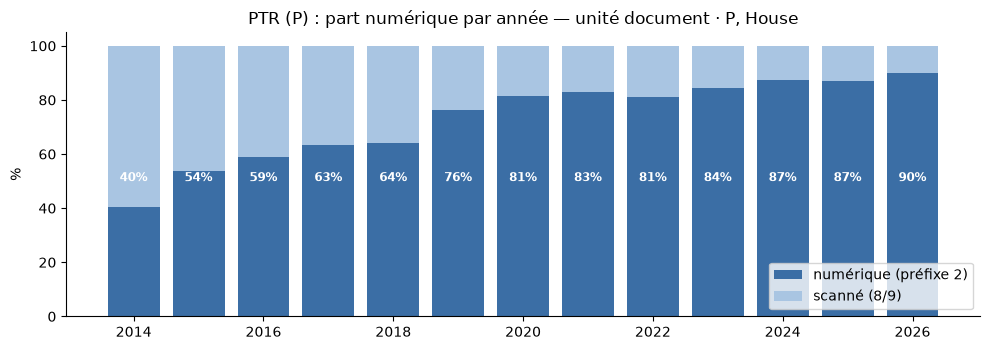

In [8]:
# ── §2.1 Matrice préfixe × type + trajectoire des P ──────────────────────────
PREFIXES_SCANNES = {"7", "8", "9"}
recensement["scanne"] = recensement["prefixe_docid"].isin(PREFIXES_SCANNES)

croise = pd.crosstab(recensement["filing_type"], recensement["prefixe_docid"])
croise = croise.reindex(index=list("PCXOADWHTGEB"))
display(croise)

# les P n'ont que des préfixes 2 (numérique) / 8,9 (scanné) — vérité structurelle
p = recensement[recensement["filing_type"] == "P"]
assert set(p["prefixe_docid"]) <= {"2", "8", "9"}, "préfixe inattendu chez les P"
n_elec, n_scan = int((~p["scanne"]).sum()), int(p["scanne"].sum())
valider("D1", "part des PTR numériques (préfixe 2)", pct(n_elec, len(p)),
        unite="document", perimetre="P, House", vert=60, sens=">=", section="§2.1")
print(f"P : {n_elec:,} numériques + {n_scan:,} scannés = {len(p):,}  "
      f"(document · P, House · 2014-2026 : {pct(n_elec, len(p))} % / {pct(n_scan, len(p))} %)")

fig, ax = plt.subplots(figsize=(10, 3.6))
par_an = p.groupby("annee_index")["scanne"].agg(total="size", scannes="sum")
par_an["elec"] = par_an["total"] - par_an["scannes"]
ax.bar(par_an.index, 100 * par_an["elec"] / par_an["total"], color="#3B6EA5", label="numérique (préfixe 2)")
ax.bar(par_an.index, 100 * par_an["scannes"] / par_an["total"],
       bottom=100 * par_an["elec"] / par_an["total"], color="#A9C5E2", label="scanné (8/9)")
for x, r in par_an.iterrows():
    ax.text(x, 50, f"{100*r['elec']/r['total']:.0f}%", ha="center", fontsize=8.5,
            color="white", fontweight="bold")
ax.set_title("PTR (P) : part numérique par année — unité document · P, House")
ax.set_ylabel("%"); ax.legend(loc="lower right"); ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout(); plt.show()

## §3 — Le ledger : un statut pour chacun des dépôts

Le défaut le plus grave de l'ancien pipeline n'était pas un bug de parsing, mais
l'**absence de comptabilité** : un document pouvait disparaître entre l'index et la table
finale sans laisser de trace (0 transaction extraite ? échec ? écarté ? on ne savait pas).
Sa métrique de « couverture » valait 100 % **par construction**.

Le ledger inverse la logique : **une ligne par DocID, un statut, et la partition doit
retomber exactement sur le total du recensement**. Statuts initiaux (affinés par chaque
étape suivante) :

- `a_traiter` — numérique, type ∈ {P, O, H, T, A, C} : sera téléchargé et parsé ;
- `scanne_hors_V1` — préfixe 7/8/9 : recensé, OCR reporté en V2 ;
- `hors_perimetre_admin` — X (délai), D/W (notices de campagne), G (cadeaux), E (exemption) :
  aucune donnée financière à extraire ;
- `hors_perimetre_blind_trust` — B : transactions non dirigées par l'élu (exclues par principe).

In [9]:
# ── §3.1 Construction du squelette ────────────────────────────────────────────
# 1 ligne par DocID : pour les doublons inter-index, on garde la 1re apparition (§1.3).
ledger = recensement.loc[~recensement["doublon_index"]].copy()

def statut_initial(r):
    if r["filing_type"] == "B":
        return "hors_perimetre_blind_trust"
    if r["filing_type"] in TYPES_HORS_PERIMETRE:
        return "hors_perimetre_admin"
    if r["scanne"]:
        return "scanne_hors_V1"
    return "a_traiter"

ledger["statut"] = ledger.apply(statut_initial, axis=1)
ledger["url_pdf"] = np.where(
    ledger["filing_type"] == "P",
    [URL_PDF_PTR.format(year=y, doc_id=d) for y, d in zip(ledger["annee_index"], ledger["doc_id"])],
    [URL_PDF_FD.format(year=y, doc_id=d) for y, d in zip(ledger["annee_index"], ledger["doc_id"])])

# Partition totale (BLOQUANT) : chaque DocID a exactement un statut,
# et ledger + doublons écartés == recensement (rien ne se perd, rien ne se crée).
assert ledger["doc_id"].is_unique and ledger["statut"].notna().all()
n_partition = len(ledger) + int(recensement["doublon_index"].sum())
valider("L1", "partition du ledger == recensement", int(n_partition == len(recensement)),
        unite="document", perimetre="tous types, House", vert=1,
        bloquant=True, section="§3.1")

bilan = (ledger.groupby(["statut", "filing_type"]).size().unstack(fill_value=0)
         .assign(total=lambda d: d.sum(axis=1)).sort_values("total", ascending=False))
display(bilan)

n_at = int((ledger["statut"] == "a_traiter").sum())
print(f"\nà traiter (numériques P/O/H/T/A/C) : {n_at:,} documents "
      f"(document · P+O/H/T/A+C num, House · 2014-2026)")
ledger.to_csv(TABLES / "02_ledger_docs.csv", index=False)
print(f"écrit → {TABLES/'02_ledger_docs.csv'}  (squelette ; enrichi aux §4-§10)")

🟢 [L1] partition du ledger == recensement = 1  (document · tous types, House · 2014-2026)


filing_type,A,B,C,D,E,G,H,O,P,T,W,X,total
statut,,,,,,,,,,,,,
a_traiter,1870,0,8533,0,0,0,383,3903,5842,291,0,0,20822
hors_perimetre_admin,0,0,0,2199,35,51,0,0,0,0,1102,5851,9238
scanne_hors_V1,433,0,1583,0,0,0,12,721,2425,102,0,0,5276
hors_perimetre_blind_trust,0,23,0,0,0,0,0,0,0,0,0,0,23



à traiter (numériques P/O/H/T/A/C) : 20,822 documents (document · P+O/H/T/A+C num, House · 2014-2026)


écrit → cache/tables/02_ledger_docs.csv  (squelette ; enrichi aux §4-§10)


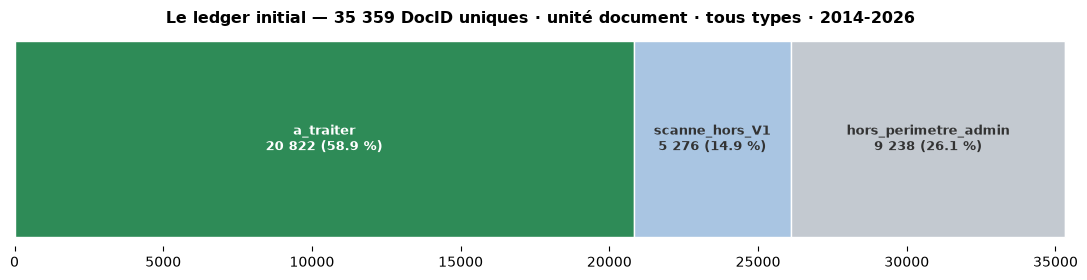

In [10]:
# ── §3.2 Figure : la partition en un coup d'œil ──────────────────────────────
fig, ax = plt.subplots(figsize=(11, 2.9))
ordre = ["a_traiter", "scanne_hors_V1", "hors_perimetre_admin", "hors_perimetre_blind_trust"]
coul  = {"a_traiter": "#2E8B57", "scanne_hors_V1": "#A9C5E2",
         "hors_perimetre_admin": "#c3c9d0", "hors_perimetre_blind_trust": "#8a929b"}
tot, x = len(ledger), 0
for s in ordre:
    n = int((ledger["statut"] == s).sum())
    ax.barh([0], [n], left=x, color=coul[s], edgecolor="white", height=0.6)
    if n > 900:
        ax.text(x + n / 2, 0, f"{s}\n{n:,} ({100*n/tot:.1f} %)".replace(",", " "),
                ha="center", va="center", fontsize=9,
                color="white" if s == "a_traiter" else "#333", fontweight="bold")
    x += n
ax.set_xlim(0, tot); ax.set_yticks([]); ax.spines[:].set_visible(False)
ax.set_title(f"Le ledger initial — {tot:,} DocID uniques · unité document · tous types · 2014-2026"
             .replace(",", " "), fontsize=11.5, fontweight="bold")
plt.tight_layout(); plt.show()

## §4 — Remplir le cache PDF, prouvablement

La cellule est **idempotente** : présent et sain → on passe ; absent → on télécharge.
Le cache peut être **pré-rempli** par copie (ancien cache `data/house/pdfs/`, lots déjà
téléchargés) — peu importe la provenance : chaque fichier est vérifié (magic bytes `%PDF-`)
et son **sha256** inscrit à l'inventaire.

Deux garde-fous :
- **preuve continue** : à chaque run, `N_PREUVE_SHA` documents tirés au sort sont
  re-téléchargés en mémoire et comparés au sha de l'inventaire ;
- **mode preuve complète** (`FULL_REDOWNLOAD=True`) : tout re-télécharger dans un cache
  daté et comparer — possible pour les **PDF** (toujours servis), plus pour les **index**
  purgés (§1).

La variable d'environnement `V1_MAX_DL` borne le nombre de téléchargements du run
(`-1` = illimité ; `0` = ne rien télécharger, utile pendant qu'un remplissage tourne à côté).

In [11]:
# ── §4.1 Pré-remplissage (copie vérifiée) puis téléchargement des manquants ──
MAX_DL = int(os.environ.get("V1_MAX_DL", "-1"))
a_traiter = ledger[ledger["statut"] == "a_traiter"]

def chemin_pdf(ft, annee, doc_id):
    return CACHE / "pdfs" / ft / str(annee) / f"{doc_id}.pdf"

# 1) pré-remplissage : l'ancien cache (P uniquement, arborescence plate {année}/{doc}.pdf)
n_copie = 0
if PREFILL_FROM_OLD and not FULL_REDOWNLOAD:
    type_de = dict(zip(ledger["doc_id"], ledger["filing_type"]))
    an_de   = dict(zip(ledger["doc_id"], ledger["annee_index"]))
    for src in sorted((ANCIEN / "data" / "house" / "pdfs").glob("*/*.pdf")):
        d = src.stem
        ft, an = type_de.get(d), an_de.get(d)
        if ft is None:
            continue
        dst = chemin_pdf(ft, an, d)
        if not dst.exists() and src.read_bytes()[:5] == b"%PDF-":
            dst.parent.mkdir(parents=True, exist_ok=True)
            shutil.copy2(src, dst)
            n_copie += 1
print(f"pré-remplissage : {n_copie} copiés de l'ancien cache")

# 2) téléchargement idempotent des manquants (P d'abord, puis O/H/T/A, puis C)
prio = {"P": 0, "O": 1, "H": 1, "T": 1, "A": 1, "C": 2}
att = a_traiter.assign(prio=a_traiter["filing_type"].map(prio)).sort_values(
    ["prio", "annee_index", "doc_id"])
if not INCLURE_C:
    att = att[att["filing_type"] != "C"]
manquants = [r for r in att.itertuples()
             if not chemin_pdf(r.filing_type, r.annee_index, r.doc_id).exists()]
print(f"manquants : {len(manquants)} / {len(att)} à traiter", flush=True)

n_dl = n_404 = 0
for r in manquants:
    if MAX_DL >= 0 and n_dl >= MAX_DL:
        break
    data, st = telecharger(r.url_pdf)
    if st == 200 and data[:5] == b"%PDF-":
        dst = chemin_pdf(r.filing_type, r.annee_index, r.doc_id)
        dst.parent.mkdir(parents=True, exist_ok=True)
        dst.write_bytes(data)
        n_dl += 1
    elif st == 404:
        ledger.loc[ledger["doc_id"] == r.doc_id, "statut"] = "absent_404"
        n_404 += 1
    time.sleep(PAUSE_S)
print(f"téléchargés : {n_dl} · 404 : {n_404}")

# état du cache après remplissage
presents = {p.stem for p in CACHE.glob("pdfs/*/*/*.pdf")}
att_pres = att["doc_id"].isin(presents)
print(f"cache : {int(att_pres.sum()):,} / {len(att):,} documents à traiter présents "
      f"({pct(int(att_pres.sum()), len(att))} %) — document · P+O/H/T/A+C num, House · 2014-2026")

pré-remplissage : 0 copiés de l'ancien cache


manquants : 1 / 20822 à traiter


téléchargés : 0 · 404 : 1
cache : 20,821 / 20,822 documents à traiter présents (100.0 %) — document · P+O/H/T/A+C num, House · 2014-2026


inventaire : 24,078 PDF · 3.26 Go → cache/tables/03_pdf_inventory.csv


🟢 [P1] preuve continue : sha identique au re-téléchargement (20/20) = 20  (document · échantillon aléatoire n=20 · 2014-2026)


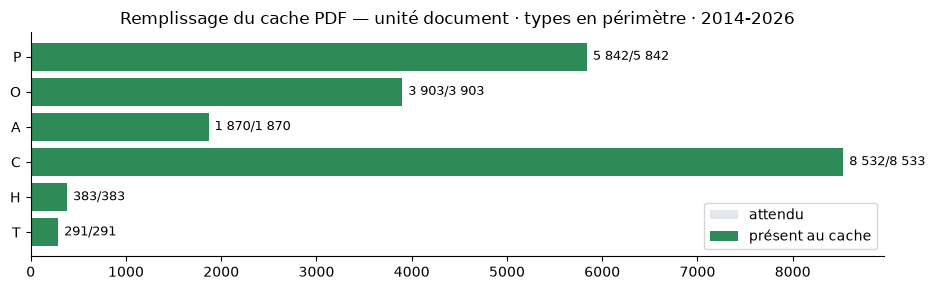

In [12]:
# ── §4.2 Inventaire sha256 + preuve continue ─────────────────────────────────
inv = []
for p in sorted(CACHE.glob("pdfs/*/*/*.pdf")):
    ft, annee, doc_id = p.parts[-3], p.parts[-2], p.stem
    data = p.read_bytes()
    inv.append({"doc_id": doc_id, "filing_type": ft, "annee_index": annee,
                "sha256": hashlib.sha256(data).hexdigest(), "octets": len(data),
                "pdf_valide": data[:5] == b"%PDF-"})
inventaire = pd.DataFrame(inv)
assert inventaire["pdf_valide"].all(), "fichier non-PDF dans le cache !"
inventaire.drop(columns=["pdf_valide"]).to_csv(TABLES / "03_pdf_inventory.csv", index=False)
print(f"inventaire : {len(inventaire):,} PDF · "
      f"{inventaire['octets'].sum()/1e9:.2f} Go → {TABLES/'03_pdf_inventory.csv'}")

# preuve continue : N docs au hasard re-téléchargés en mémoire, sha comparé
rng = random.Random(2026)                      # graine fixe → échantillon reproductible
url_de = dict(zip(ledger["doc_id"], ledger["url_pdf"]))
echantillon = rng.sample(sorted(set(inventaire["doc_id"]) & set(url_de)),
                         min(N_PREUVE_SHA, len(inventaire)))
sha_de = dict(zip(inventaire["doc_id"], inventaire["sha256"]))
egal = diff = inaccessible = 0
for d in echantillon:
    data, st = telecharger(url_de[d])
    if st != 200:
        inaccessible += 1
    elif hashlib.sha256(data).hexdigest() == sha_de[d]:
        egal += 1
    else:
        diff += 1
        print(f"  ⚠️ sha différent : {d}")
    time.sleep(PAUSE_S)
valider("P1", f"preuve continue : sha identique au re-téléchargement ({egal}/{len(echantillon)})",
        egal + inaccessible, unite="document", perimetre=f"échantillon aléatoire n={len(echantillon)}",
        vert=len(echantillon), bloquant=False, section="§4.2")

# jauge de remplissage par type
fig, ax = plt.subplots(figsize=(9.5, 3))
att_all = ledger[ledger["statut"].isin(["a_traiter", "absent_404"])]
etat = att_all.assign(present=att_all["doc_id"].isin(set(inventaire["doc_id"])))
g = etat.groupby("filing_type")["present"].agg(present="sum", total="size")
g = g.reindex(["P", "O", "A", "C", "H", "T"]).dropna()
ax.barh(g.index[::-1], g["total"][::-1], color="#e3e7ec", label="attendu")
ax.barh(g.index[::-1], g["present"][::-1], color="#2E8B57", label="présent au cache")
for i, (t, r) in enumerate(g[::-1].iterrows()):
    ax.text(r["total"] + 60, i, f"{int(r['present']):,}/{int(r['total']):,}".replace(",", " "),
            va="center", fontsize=9)
ax.set_title("Remplissage du cache PDF — unité document · types en périmètre · 2014-2026")
ax.legend(loc="lower right"); ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout(); plt.show()

## §5 — Du PDF au texte, et la double classification

Chaque PDF présent est passé à **pdfplumber** ; le texte est mis en cache
(`cache/text/…/{DocID}.txt`, y compris vide) — l'extraction ne se refait jamais.

Puis on confronte **deux définitions indépendantes** de « scanné » :
- `route_prefixe` : le 1ᵉʳ caractère du DocID (7/8/9 = scanné) — la métadonnée ;
- `route_contenu` : `bool(texte.strip())` — la réalité physique du fichier
  (c'était l'**unique** critère de l'ancien pipeline).

La **matrice de confusion** des deux signaux doit être quasi diagonale ; chaque cas
hors-diagonale est listé et devient un statut explicite (`elec_sans_texte`), jamais un
routage silencieux.

In [13]:
# ── §5.1 Extraction idempotente ───────────────────────────────────────────────
import pdfplumber

def chemin_txt(ft, annee, doc_id):
    return CACHE / "text" / ft / str(annee) / f"{doc_id}.txt"

def extraire_texte(pdf_path):
    try:
        with pdfplumber.open(str(pdf_path)) as pdf:
            return "\n".join((pg.extract_text() or "") for pg in pdf.pages).replace("\x00", "")
    except Exception:
        return ""

n_extraits = 0
for p in sorted(CACHE.glob("pdfs/*/*/*.pdf")):
    ft, annee, doc_id = p.parts[-3], p.parts[-2], p.stem
    t = chemin_txt(ft, annee, doc_id)
    if not t.exists():
        t.parent.mkdir(parents=True, exist_ok=True)
        t.write_text(extraire_texte(p), encoding="utf-8")
        n_extraits += 1
n_txt = sum(1 for _ in CACHE.glob("text/*/*/*.txt"))
print(f"extraits ce run : {n_extraits} · au cache texte : {n_txt:,}")

extraits ce run : 0 · au cache texte : 24,078


In [14]:
# ── §5.2 Matrice de confusion préfixe × contenu ───────────────────────────────
rows = []
for t in CACHE.glob("text/*/*/*.txt"):
    ft, annee, doc_id = t.parts[-3], t.parts[-2], t.stem
    rows.append({"doc_id": doc_id, "has_text": bool(t.read_text(encoding="utf-8").strip())})
textes = pd.DataFrame(rows)
cls = ledger.merge(textes, on="doc_id", how="inner")
cls["route_prefixe"] = np.where(cls["scanne"], "scanné", "numérique")
cls["route_contenu"] = np.where(cls["has_text"], "texte", "sans texte")

conf = pd.crosstab(cls["route_prefixe"], cls["route_contenu"])
display(conf)
hors_diag = cls[(cls["route_prefixe"] == "numérique") & (~cls["has_text"])]
scan_avec_texte = cls[(cls["route_prefixe"] == "scanné") & (cls["has_text"])]
valider("L4", "désaccords préfixe × contenu (numérique sans texte)",
        pct(len(hors_diag), max(1, int((cls['route_prefixe']=='numérique').sum()))),
        unite="document", perimetre="docs en cache, types en périmètre",
        vert=0.5, orange=1.0, sens="<=", section="§5.2")
if len(hors_diag):
    print("numériques SANS texte (anomalies, chacune listée) :")
    display(hors_diag[["doc_id", "filing_type", "annee_index", "last", "first", "url_pdf"]])
if len(scan_avec_texte):
    print(f"scannés AVEC couche texte : {len(scan_avec_texte)} (souvent OCR d'origine — info)")

# statut ledger : texte_ok / elec_sans_texte pour les a_traiter présents
ok_ids = set(textes.loc[textes["has_text"], "doc_id"])
vide_ids = set(textes.loc[~textes["has_text"], "doc_id"])
m_at = ledger["statut"] == "a_traiter"
ledger.loc[m_at & ledger["doc_id"].isin(ok_ids), "statut"] = "texte_ok"
ledger.loc[m_at & ledger["doc_id"].isin(vide_ids), "statut"] = "elec_sans_texte"
print(dict(ledger["statut"].value_counts()))

route_contenu,sans texte,texte
route_prefixe,,
numérique,0,20821
scanné,3257,0


🟢 [L4] désaccords préfixe × contenu (numérique sans texte) = 0.0  (document · docs en cache, types en périmètre · 2014-2026)
{'texte_ok': np.int64(20821), 'hors_perimetre_admin': np.int64(9238), 'scanne_hors_V1': np.int64(5276), 'hors_perimetre_blind_trust': np.int64(23), 'absent_404': np.int64(1)}


## §6 — La grille des fourchettes de montant : UNE table de référence

Les formulaires n'indiquent jamais un montant exact mais une **fourchette** (grille du
STOCK Act). Deux subtilités mesurées sur le corpus :

1. **Le palier `$1 – $1,000` n'existe qu'en Schedule A** (valeur d'actif) — en Schedule B
   (transaction), le seuil de déclaration est 1 001 $.
2. **Les fourchettes coupées** : le PDF casse parfois « $1,001 - » / « $15,000 » sur deux
   lignes. L'ancien pipeline stockait la borne basse seule et un midpoint **sous-estimé
   d'un facteur 2** sur 7 995 lignes, réparé seulement à la relecture. Ici : la borne
   basse identifie le palier de façon **unique** → reconstruction **au parse**
   (`amount_reconstruit=True`), et la table écrite est juste.

Cas mesuré en corpus : certains PTR déclarent un **montant exact** (« $955.10 ») au
lieu d'une fourchette — accepté tel quel (`amount_exact=True`, lo=hi=mid).

Convention V1 : `amount_lo`, `amount_hi`, `amount_mid = (lo+hi)/2` exact (fin de la
divergence historique .0/.5) ; paliers ouverts (`Over $50,000,000`) → `hi = NaN`,
`mid = NaN` + `mid_conventionnel`.

In [15]:
# ── §6.1 La grille et le parseur de fourchette ────────────────────────────────
# (borne_basse, borne_haute, libellé canonique, réservé Schedule A)
FOURCHETTES = [
    (1,          1_000,      "$1 - $1,000",               True),   # holdings seulement
    (1_001,      15_000,     "$1,001 - $15,000",          False),
    (15_001,     50_000,     "$15,001 - $50,000",         False),
    (50_001,     100_000,    "$50,001 - $100,000",        False),
    (100_001,    250_000,    "$100,001 - $250,000",       False),
    (250_001,    500_000,    "$250,001 - $500,000",       False),
    (500_001,    1_000_000,  "$500,001 - $1,000,000",     False),
    (1_000_001,  5_000_000,  "$1,000,001 - $5,000,000",   False),
    (5_000_001,  25_000_000, "$5,000,001 - $25,000,000",  False),
    (25_000_001, 50_000_000, "$25,000,001 - $50,000,000", False),
    (50_000_001, None,       "Over $50,000,000",          False),
]
PAR_BORNE_BASSE = {lo: (lo, hi, lib) for lo, hi, lib, _ in FOURCHETTES}
MID_CONVENTIONNEL = {"Over $50,000,000": 75_000_000.0, "SP/DC over $1,000,000": 1_000_001.0}

def _nombre(s):
    return int(re.sub(r"[^\d]", "", s))

def parse_fourchette(brut):
    """'$1,001 - $15,000' / '$1,001 -' (coupée) / 'Over $50,000,000' / 'SP/DC over $1,000,000'
    → dict(lo, hi, libelle, mid, mid_conventionnel, reconstruit) ou None si illisible."""
    s = re.sub(r"\s+", " ", str(brut)).strip().rstrip(".")
    if not s or s.lower() in ("none", "nan"):
        return None
    m = re.fullmatch(r"\$([\d,]+(?:\.\d{2})?)", s)   # montant EXACT (petites txns déclarées au cent)
    if m and "." in m.group(1):
        v = float(m.group(1).replace(",", ""))
        return dict(lo=v, hi=v, libelle=f"${m.group(1)}", mid=v,
                    mid_conventionnel=v, reconstruit=False, exact=True)
    m = re.fullmatch(r"\$([\d,]+) ?- ?\$([\d,]+)", s)
    if m:
        lo, hi = _nombre(m.group(1)), _nombre(m.group(2))
        att = PAR_BORNE_BASSE.get(lo)
        libelle = att[2] if att and att[1] == hi else f"${m.group(1)} - ${m.group(2)}"
        return dict(lo=lo, hi=hi, libelle=libelle, mid=(lo + hi) / 2,
                    mid_conventionnel=(lo + hi) / 2, reconstruit=False, exact=False)
    if re.fullmatch(r"(?i)over \$([\d,]+)", s):
        lo = _nombre(s)
        lib = PAR_BORNE_BASSE.get(lo, (lo, None, f"Over ${lo:,}"))[2] if lo in PAR_BORNE_BASSE \
              else f"Over ${s.split('$')[1]}"
        lib = "Over $50,000,000" if lo == 50_000_001 else lib
        return dict(lo=lo, hi=None, libelle=lib, mid=None,
                    mid_conventionnel=MID_CONVENTIONNEL.get(lib), reconstruit=False, exact=False)
    if re.fullmatch(r"(?i)sp/dc over \$1,000,000", s):
        return dict(lo=1_000_001, hi=None, libelle="SP/DC over $1,000,000", mid=None,
                    mid_conventionnel=1_000_001.0, reconstruit=False, exact=False)
    m = re.fullmatch(r"\$([\d,]+) ?-?", s)         # borne seule (avec ou sans tiret)
    if m:
        lo = _nombre(m.group(1))
        att = PAR_BORNE_BASSE.get(lo)
        if att:                                     # la borne basse identifie le palier → COUPÉE
            lo, hi, lib = att
            return dict(lo=lo, hi=hi, libelle=lib, mid=(lo + hi) / 2 if hi else None,
                        mid_conventionnel=(lo + hi) / 2 if hi else MID_CONVENTIONNEL.get(lib),
                        reconstruit=True, exact=False)
        if not s.endswith("-"):                     # hors grille, sans tiret : montant EXACT entier
            return dict(lo=float(lo), hi=float(lo), libelle=f"${m.group(1)}", mid=float(lo),
                        mid_conventionnel=float(lo), reconstruit=False, exact=True)
    return None

# tests unitaires inline — la cellule échoue si la grille régresse
t = parse_fourchette("$1,001 - $15,000");  assert (t["lo"], t["hi"], t["mid"]) == (1001, 15000, 8000.5)
t = parse_fourchette("$1,001 -");          assert t["reconstruit"] and t["hi"] == 15000, t
t = parse_fourchette("$100,001 -\n$250,000".replace("\n", " ")); assert t["hi"] == 250000
t = parse_fourchette("Over $50,000,000");  assert t["hi"] is None and t["mid_conventionnel"] == 75e6
t = parse_fourchette("$1 - $1,000");       assert t["mid"] == 500.5
t = parse_fourchette("$15,001 - $50,000"); assert not t["reconstruit"]
t = parse_fourchette("$955.10");       assert t["exact"] and t["mid"] == 955.10, t
t = parse_fourchette("$25,000,001");   assert t["reconstruit"] and t["hi"] == 50_000_000, t
t = parse_fourchette("$955");          assert t["exact"] and t["mid"] == 955.0, t
assert parse_fourchette("None") is None and parse_fourchette("") is None
print("grille OK —", len(FOURCHETTES), "paliers ; fourchettes coupées reconstruites AU PARSE")

grille OK — 11 paliers ; fourchettes coupées reconstruites AU PARSE


## §7 — Le parseur Schedule B des PTR : un seul parseur, tolérant

Une ligne de transaction PTR contient toujours, dans l'ordre :
**type** (`P`/`S`/`E`, éventuellement `(partial)`/`(full)`) · **date de transaction** ·
**date de notification** · **fourchette**. Autour d'elle : la description de l'actif
(au-dessus ou en préfixe), le ticker `(XXX)`, parfois un code d'actif `[ST]`, parfois un
propriétaire `SP`/`JT`/`DC`.

Deux rendus coexistent (police en petites capitales rendues en minuscules avant ~2018,
codes `[XX]` présents après) — mais l'ancien pipeline utilisait **deux parseurs distincts
unis par une déduplication fragile** : sur le document témoin `20002235` (5 transactions
réelles, comptées à la main), il en produisait **9** (les deux parseurs extrayaient des
champs légèrement différents → « disjoints » pour la clé de dédup). La V1 utilise **un
seul parseur de ligne**, insensible à la casse, qui gère nativement :
- la garde « jeton isolé » (le `s` de « l.P. - s 11/10/2014 » est un type, le `s` de
  « Shares » non) ;
- les **montants coupés** sur la ligne suivante (sinon reconstruction §6) ;
- le ticker en préfixe de ligne **ou** dans le bloc description au-dessus **ou** en
  continuation au-dessous.

In [16]:
# ── §7.1 Le parseur ──────────────────────────────────────────────────────────
RE_LIGNE_TXN = re.compile(
    r"(?P<type>[PSE])\s*(?:\((?P<sub>partial|full)\))?\s+"
    r"(?P<txn>\d{1,2}/\d{1,2}/\d{4})\s+"
    r"(?P<notif>\d{1,2}/\d{1,2}/\d{4})\s+"
    r"(?P<montant>\$[\d,]+\.\d{2}|\$[\d,]+\s*-\s*\$[\d,]+|Over\s+\$[\d,]+"
    r"|Spouse/DC\s+[Oo]ver|\$[\d,]+\s*-?)",
    re.IGNORECASE)
RE_TICKER   = re.compile(r"\(([A-Za-z][A-Za-z0-9.\-]{0,5})\)")
RE_CODE_XX  = re.compile(r"\[([A-Za-z]{2})\]")
RE_OWNER    = re.compile(r"^(JT|SP|DC)\s+", re.IGNORECASE)
RE_ENTETE   = re.compile(
    r"^\s*(Filing ID|Clerk of|filer information|name:|Status:|State/District:|"
    r"iD owner|type Date|\$200|tranSactionS|initial Public|certification|Digitally|"
    r"gfedcb? I CERTIFY|\* For the complete|FIlINg\s*STATuS|nmlk|DESCRIPTION|"
    r"D\s*e\s*s\s*c\s*r\s*i\s*p\s*t\s*i\s*o\s*n)", re.IGNORECASE)
MOTS_NON_TICKER = {"partial", "full", "ira", "llc", "lp", "inc", "etf", "adr", "reit"}

def _ticker_dans(s):
    """Premier (TICKER) plausible de la chaîne. Rejette les parenthèses de plans
    d'épargne — « 401(k) », « 457(b) », « 529(a) » : capture précédée d'un CHIFFRE —
    et les sigles non boursiers (IRA, LLC…)."""
    for m in RE_TICKER.finditer(s):
        if m.group(1).lower() in MOTS_NON_TICKER:
            continue
        j = m.start() - 1
        if j >= 0 and s[j].isdigit():
            continue
        return m.group(1).upper()
    return None

def _op(t, sub):
    base = {"P": "Purchase", "S": "Sale", "E": "Exchange"}[t.upper()]
    if sub:
        base += f" ({sub.capitalize()})"
    return base

def extraire_transactions_ptr(texte):
    """Texte pdfplumber d'un PTR → liste de transactions (1 par ligne matchée, jamais d'union)."""
    lignes = [l.rstrip() for l in texte.splitlines()]
    out = []
    for i, ligne in enumerate(lignes):
        m = RE_LIGNE_TXN.search(ligne)
        if not m:
            continue
        st = m.start("type")
        if st > 0 and (ligne[st - 1].isalnum() or ligne[st - 1] in ").]"):
            continue                                   # lettre interne à un mot → pas un type
        # ── montant, borne haute éventuellement sur les 2 lignes suivantes
        brut = m.group("montant").strip()
        if re.fullmatch(r"(?i)spouse/dc\s+over", brut):
            brut = "SP/DC over $1,000,000"     # palier conjoint, montant imprimé ligne suivante
        reconstruit = False
        if re.fullmatch(r"\$[\d,]+\s*-?", brut) and "." not in brut:   # coupé : chercher la borne haute
            suite = None
            for j in (i + 1, i + 2):
                if j < len(lignes):
                    m2 = re.search(r"\$[\d,]+", lignes[j])
                    if m2 and not RE_LIGNE_TXN.search(lignes[j]):
                        suite = m2.group(0); break
            if suite:
                brut = brut.rstrip(" -") + " - " + suite
            else:
                reconstruit = True                      # reconstruction par la grille (§6)
        f = parse_fourchette(brut if not brut.endswith("-") else brut)
        if f is None:
            f = parse_fourchette(brut + " -") if not brut.endswith("-") else None
        if f is None:
            continue
        f["reconstruit"] = f["reconstruit"] or reconstruit
        # ── bloc description : préfixe de ligne + jusqu'à 3 lignes au-dessus
        prefixe = ligne[:m.start()].strip()
        bloc, k = [], i - 1
        while k >= 0 and len(bloc) < 3:
            prev = lignes[k].strip()
            if not prev:
                k -= 1; continue
            if RE_LIGNE_TXN.search(prev) or RE_ENTETE.match(prev):
                break
            bloc.insert(0, prev); k -= 1
        if prefixe:
            bloc.append(prefixe)
        # ── continuations sous la ligne (jusqu'à 3, stop à la prochaine transaction)
        apres = []
        for j in range(i + 1, min(i + 4, len(lignes))):
            nxt = lignes[j].strip()
            if not nxt or RE_LIGNE_TXN.search(nxt) or RE_ENTETE.match(nxt):
                break
            apres.append(nxt)
        blk = " ".join(bloc)
        owner_m = RE_OWNER.match(blk)
        owner = owner_m.group(1).upper() if owner_m else None
        if owner_m:
            blk = blk[owner_m.end():]
        tk = _ticker_dans(blk) or _ticker_dans(" ".join(apres))
        cx = RE_CODE_XX.search(blk + " " + " ".join(apres))
        desc = RE_CODE_XX.sub("", RE_TICKER.sub("", blk)).strip(" -")
        out.append(dict(ticker=tk, asset_description=desc,
                        asset_code=cx.group(1).upper() if cx else None,
                        operation_type=_op(m.group("type"), m.group("sub")),
                        transaction_date=m.group("txn"), notification_date=m.group("notif"),
                        amount_range=f["libelle"], amount_lo=f["lo"], amount_hi=f["hi"],
                        amount_mid=f["mid"], amount_mid_conventionnel=f["mid_conventionnel"],
                        amount_reconstruit=f["reconstruit"], amount_exact=f.get("exact", False), owner=owner))
    return out
print("parseur PTR prêt")

parseur PTR prêt


In [17]:
# ── §7.2 Témoins : documents ouverts à la main, asserts littéraux ─────────────
def _lire(ft, annee, doc_id):
    return chemin_txt(ft, annee, doc_id).read_text(encoding="utf-8")

# T1 — Yoder 20002235 (P 2014, gabarit legacy « petites capitales ») : 5 transactions
t1 = extraire_transactions_ptr(_lire("P", 2014, "20002235"))
assert len(t1) == 5, f"T1 : {len(t1)} ≠ 5 transactions"
assert [x["ticker"] for x in t1] == ["ARLP", "ENLC", "NGL", "OKS", "SMLP"], [x["ticker"] for x in t1]
assert [x["operation_type"][0] for x in t1] == ["S", "P", "S", "S", "S"]
assert t1[0]["transaction_date"] == "11/10/2014" and t1[4]["transaction_date"] == "12/17/2014"
assert all(x["amount_range"] == "$1,001 - $15,000" and x["amount_mid"] == 8000.5 for x in t1)
print("T1 Yoder 2014 (legacy)   : 5/5 ✓ — l'ancien pipeline en produisait 9 (doublons)")

# T2 — Allen 20016985 (P 2020, gabarit moderne, 2 montants coupés) : 3 transactions
t2 = extraire_transactions_ptr(_lire("P", 2020, "20016985"))
assert len(t2) == 3, f"T2 : {len(t2)} ≠ 3"
assert [x["ticker"] for x in t2] == ["GOOGL", "RDS.B", "SSB"], [x["ticker"] for x in t2]
assert t2[0]["amount_range"] == "$1,001 - $15,000"
assert t2[1]["amount_range"] == "$15,001 - $50,000",  t2[1]["amount_range"]   # coupé, recollé
assert t2[2]["amount_range"] == "$50,001 - $100,000", t2[2]["amount_range"]   # coupé, recollé
assert not any(x["amount_reconstruit"] for x in t2)   # recollés depuis le PDF, pas la grille
print("T2 Allen 2020 (moderne)  : 3/3 ✓ — montants coupés recollés depuis le document")

# T5 — Peters 20006475 (P 2017) : 3 transactions « Spouse/DC Over $1,000,000 »
# (bons du Trésor du conjoint ; le montant est imprimé sur la ligne suivante)
t5 = extraire_transactions_ptr(_lire("P", 2017, "20006475"))
assert len(t5) == 3, f"T5 : {len(t5)} ≠ 3"
assert all(x["amount_range"] == "SP/DC over $1,000,000" for x in t5), t5[0]["amount_range"]
assert [x["operation_type"][0] for x in t5] == ["P", "P", "S"]
print("T5 Peters 2017 (conjoint) : 3/3 ✓ — palier « Spouse/DC over $1,000,000 » capté")

T1 Yoder 2014 (legacy)   : 5/5 ✓ — l'ancien pipeline en produisait 9 (doublons)
T2 Allen 2020 (moderne)  : 3/3 ✓ — montants coupés recollés depuis le document
T5 Peters 2017 (conjoint) : 3/3 ✓ — palier « Spouse/DC over $1,000,000 » capté


56,498 transactions extraites de 5,842 PTR (transaction · P élec parsés, House · 2014-2026)
🟢 [R1] PTR numériques lisibles avec ≥1 transaction = 100.0  (document · P élec texte_ok, House · 2014-2026)


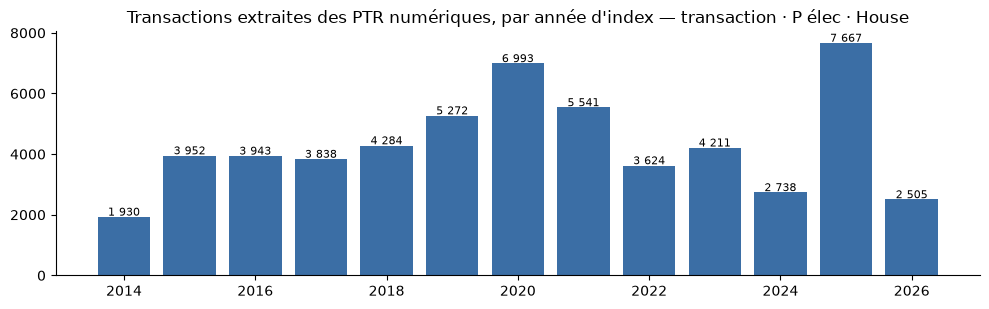

In [18]:
# ── §7.3 Parsing de masse des PTR numériques ─────────────────────────────────
txn_rows = []
docs_p = ledger[(ledger["filing_type"] == "P") & (ledger["statut"] == "texte_ok")]
zero_ligne = []
for r in docs_p.itertuples():
    t = _lire("P", r.annee_index, r.doc_id)
    txs = extraire_transactions_ptr(t)
    if not txs:
        zero_ligne.append((r.doc_id, r.annee_index, r.last, len(t)))
        continue
    for k, x in enumerate(txs):
        txn_rows.append({**x, "doc_id": r.doc_id, "annee_index": r.annee_index,
                         "provenance": "ptr", "ligne_doc": k})
txns_ptr = pd.DataFrame(txn_rows)
n_docs_ok = txns_ptr["doc_id"].nunique()
print(f"{len(txns_ptr):,} transactions extraites de {n_docs_ok:,} PTR "
      f"(transaction · P élec parsés, House · 2014-2026)")
valider("R1", "PTR numériques lisibles avec ≥1 transaction",
        pct(n_docs_ok, max(1, len(docs_p))), unite="document",
        perimetre="P élec texte_ok, House", vert=97.0, orange=95.0, section="§7.3")

# les 0-ligne : chacun listé (jamais avalé)
if zero_ligne:
    zl = pd.DataFrame(zero_ligne, columns=["doc_id", "annee_index", "last", "n_chars"])
    print(f"PTR lisibles à 0 transaction : {len(zl)} — liste complète :")
    display(zl.sort_values(["annee_index", "doc_id"]))
    ledger.loc[ledger["doc_id"].isin(zl["doc_id"]), "statut"] = "parse_0_ligne"

# rendement par année (figure)
fig, ax = plt.subplots(figsize=(10, 3.2))
par_an = txns_ptr.groupby("annee_index").size()
ax.bar(par_an.index.astype(int), par_an.values, color="#3B6EA5")
for x, v in par_an.items():
    ax.text(int(x), v + 40, f"{v:,}".replace(",", " "), ha="center", fontsize=8)
ax.set_title("Transactions extraites des PTR numériques, par année d'index — transaction · P élec · House")
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout(); plt.show()

## §8 — Les rapports FD (C/O/H/T/A) : sections, patrimoine (A), transactions (B)

Un rapport FD (candidat, annuel, entrée, sortie, amendement) est découpé en **sections
`SCHEDULE A:` … `SCHEDULE J:`**. Deux nous intéressent :

- **Schedule A — actifs détenus** : `actif (TICKER) [ST] owner fourchette…`, sans date.
  Trois formes mesurées : tout sur une ligne ; nom débordant (ticker sur la ligne
  suivante) ; **bloc conteneur** « `Perry IRA ⇒ SP $1,001 - $15,000` » puis l'actif sur
  la ligne d'après (la fourchette du holding est alors sur la ligne `⇒` précédente, et sa
  borne haute parfois poussée sur la ligne de l'actif).
- **Schedule B — transactions** : `actif (TICKER) date TYPE fourchette` — l'ordre diffère
  du PTR (une seule date, le type APRÈS la date), le `(partial)` et la borne haute
  débordent souvent sur la ligne suivante.

On ne garde que les lignes **tickérisées** (actions/ETF cotés — le niveau utile aux
validations de cohérence) ; les non-tickérisés (fonds nommés, immobilier…) sont comptés.

In [19]:
# ── §8.1 Découpage en sections ────────────────────────────────────────────────
# Deux rendus d'en-tête mesurés : « ScHeDule b: tranSactionS » (≤2020, petites capitales
# partielles) et « S B: T » (2021+, seules les INITIALES survivent à l'extraction).
RE_SECTION = re.compile(r"^\s*s\s*c\s*h\s*e\s*d\s*u\s*l\s*e\s+([a-j])\s*:", re.IGNORECASE)
RE_SECTION_COURT = re.compile(r"^\s*S\s+([A-J])\s*:")     # gabarit 2021+

def decouper_sections(texte):
    """→ dict {'A': texte, 'B': texte, …} (sections présentes seulement)."""
    sections, courante, buf = {}, None, []
    for ligne in texte.splitlines():
        m = RE_SECTION.match(ligne) or RE_SECTION_COURT.match(ligne)
        if m:
            if courante:
                sections[courante] = "\n".join(buf)
            courante, buf = m.group(1).upper(), []
        elif courante:
            buf.append(ligne)
    if courante:
        sections[courante] = "\n".join(buf)
    return sections

sec = decouper_sections(_lire("O", 2015, "10010857"))
assert set("ABCDEFGHI") <= set(sec), f"sections Pelosi : {sorted(sec)}"
sec21 = decouper_sections(_lire("O", 2021, "10044853"))        # gabarit 2021+ (Tlaib)
assert {"A", "B"} <= set(sec21), f"sections Tlaib 2021 : {sorted(sec21)}"
print("découpeur OK — Pelosi 2015 :", " ".join(sorted(sec)),
      "· Tlaib 2021 :", " ".join(sorted(sec21)))

découpeur OK — Pelosi 2015 : A B C D E F G H I · Tlaib 2021 : A B C D E F G H I


In [20]:
# ── §8.2 Parseur Schedule A (holdings) + témoins ─────────────────────────────
RE_VALEUR   = re.compile(r"\$[\d,]+\s*-\s*\$[\d,]+|Over\s+\$[\d,]+|\$[\d,]+\s*-", re.IGNORECASE)
RE_FD_TXN_GARDE = re.compile(r"\d{1,2}/\d{1,2}/\d{4}\s+[PSE]\b", re.IGNORECASE)
RE_OWNER_LN = re.compile(r"\b(SP|JT|DC)\b")
RE_CONTENEUR= re.compile(r"⇒")

def extraire_holdings(section_a):
    """Section A → liste de holdings TICKÉRISÉS {ticker, owner, value_*}."""
    lignes = [l.rstrip() for l in section_a.splitlines()]
    out = []
    for i, ligne in enumerate(lignes):
        tk = _ticker_dans(ligne)
        if tk is None:
            continue
        if RE_FD_TXN_GARDE.search(ligne):
            continue                                   # ligne de TRANSACTION, pas un holding
        # la fourchette : même ligne → sinon ligne conteneur « ⇒ » juste au-dessus
        src, borne_sup_ici = ligne, None
        m = RE_VALEUR.search(RE_TICKER.sub("", ligne))
        if m is None and i > 0 and RE_CONTENEUR.search(lignes[i - 1]):
            src = lignes[i - 1]
            m = RE_VALEUR.search(src)
            m2 = re.search(r"\$[\d,]+", RE_TICKER.sub("", ligne))
            if m2:
                borne_sup_ici = m2.group(0)            # borne haute poussée sur la ligne actif
        if m is None and i + 1 < len(lignes) and not _ticker_dans(lignes[i + 1]):
            src = lignes[i + 1]                        # nom débordant : valeur ligne suivante
            m = RE_VALEUR.search(src)
        if m is None:
            continue
        brut = m.group(0)
        if brut.rstrip().endswith("-") and borne_sup_ici:
            brut = brut.rstrip(" -") + " - " + borne_sup_ici
        f = parse_fourchette(brut)
        if f is None:
            continue
        ow = RE_OWNER_LN.search(src[:m.start()]) or RE_OWNER_LN.search(src)
        out.append(dict(ticker=tk, owner=ow.group(1) if ow else "SELF",
                        value_range=f["libelle"], value_lo=f["lo"], value_hi=f["hi"],
                        value_mid=f["mid"], value_reconstruit=f["reconstruit"]))
    # dédup exacte intra-section (répétitions d'en-têtes de page)
    vus, dedup = set(), []
    for h in out:
        k = (h["ticker"], h["owner"], h["value_range"])
        if k not in vus:
            vus.add(k); dedup.append(h)
    return dedup

# T3 — MTG 10042733 (H 2020) : positions vérifiées à la main dans le PDF
h3 = extraire_holdings(decouper_sections(_lire("H", 2020, "10042733"))["A"])
par_tk = {(h["ticker"], h["owner"]): h for h in h3}
assert ("BMY", "SP") in par_tk and par_tk[("BMY", "SP")]["value_range"] == "$1,001 - $15,000"
assert ("MCD", "JT") in par_tk and par_tk[("MCD", "JT")]["value_range"] == "$15,001 - $50,000"
assert ("IVV", "SELF") in par_tk                       # Marjorie IRA ⇒ (sans owner explicite)
assert len(h3) > 80, len(h3)
print(f"T3 MTG (H 2020) : {len(h3)} holdings tickérisés ✓ (BMY/MCD/IVV vérifiés au PDF)")

T3 MTG (H 2020) : 101 holdings tickérisés ✓ (BMY/MCD/IVV vérifiés au PDF)


In [21]:
# ── §8.3 Parseur Schedule B des FD + témoin Pelosi ───────────────────────────
RE_FD_TXN = re.compile(
    r"(?P<txn>\d{1,2}/\d{1,2}/\d{4})\s+"
    r"(?P<type>[PSE])(?:\s*\((?P<sub>partial|full)\))?\s+"
    r"(?P<montant>\$[\d,]+\.\d{2}|\$[\d,]+\s*-\s*\$[\d,]+|Over\s+\$[\d,]+|\$[\d,]+\s*-?)",
    re.IGNORECASE)

def extraire_transactions_fd(section_b):
    """Section B d'un rapport FD → transactions tickérisées (ordre : date TYPE montant)."""
    lignes = [l.rstrip() for l in section_b.splitlines()]
    out = []
    for i, ligne in enumerate(lignes):
        m = RE_FD_TXN.search(ligne)
        if not m:
            continue
        brut, sub = m.group("montant").strip(), m.group("sub")
        if re.fullmatch(r"\$[\d,]+\s*-?", brut) and "." not in brut:  # borne haute (parfois « (partial) »)
            for j in (i + 1, i + 2):                   # sur les lignes suivantes
                if j < len(lignes) and not RE_FD_TXN.search(lignes[j]):
                    if sub is None:
                        ms = re.search(r"\((partial|full)\)", lignes[j], re.IGNORECASE)
                        if ms:
                            sub = ms.group(1)
                    m2 = re.search(r"\$[\d,]+", lignes[j])
                    if m2:
                        brut = brut.rstrip(" -") + " - " + m2.group(0); break
        f = parse_fourchette(brut)
        if f is None:
            continue
        tk = _ticker_dans(ligne[:m.start()]) or (_ticker_dans(lignes[i - 1]) if i else None)
        out.append(dict(ticker=tk,
                        asset_description=RE_TICKER.sub("", ligne[:m.start()]).strip(" -"),
                        operation_type=_op(m.group("type"), sub),
                        transaction_date=m.group("txn"),
                        amount_range=f["libelle"], amount_lo=f["lo"], amount_hi=f["hi"],
                        amount_mid=f["mid"], amount_mid_conventionnel=f["mid_conventionnel"],
                        amount_reconstruit=f["reconstruit"], amount_exact=f.get("exact", False)))
    return out

# T4 — Pelosi annuel 2015 (10010857) : 5 transactions, comptées à la main dans le PDF
t4 = extraire_transactions_fd(decouper_sections(_lire("O", 2015, "10010857"))["B"])
assert len(t4) == 5, f"T4 : {len(t4)} ≠ 5"
assert [x["ticker"] for x in t4] == ["HTZ", "HTZ", "CRM", "V", "V"], [x["ticker"] for x in t4]
assert t4[1]["amount_range"] == "$100,001 - $250,000"          # montant coupé, recollé
assert t4[2]["operation_type"] == "Sale (Partial)"             # (partial) ligne suivante
assert t4[3]["amount_range"] == "$250,001 - $500,000"
print("T4 Pelosi annuel 2015 : 5/5 ✓ — montants recollés, (partial) récupéré")

T4 Pelosi annuel 2015 : 5/5 ✓ — montants recollés, (partial) récupéré


holdings tickérisés : 198,615 (holding · Schedule A des C/O/H/T/A élec · 2014-2026)
transactions FD     : 132,619 (transaction · Schedule B des C/O/H/T/A élec · 2014-2026)
docs FD sans aucune section (anomalies listées) : 0
🟢 [R2] rapports FD lisibles découpés en sections = 100.0  (document · C/O/H/T/A élec texte_ok, House · 2014-2026)


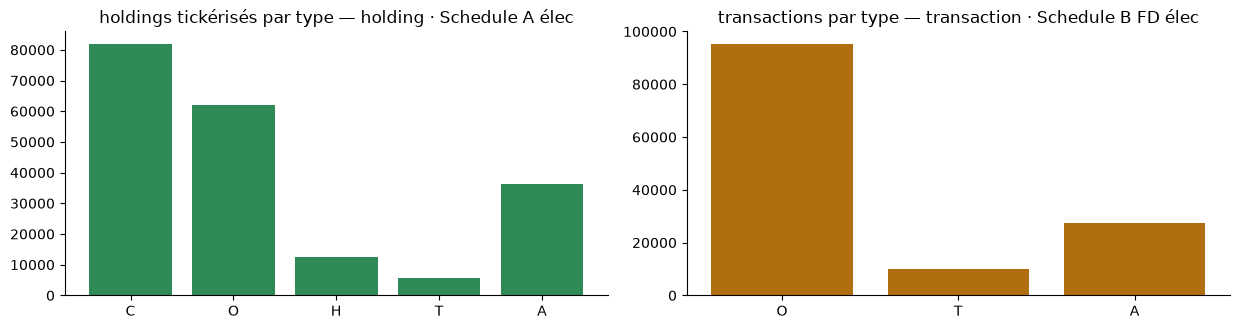

In [22]:
# ── §8.4 Parsing de masse des rapports FD → holdings + transactions FD ───────
hold_rows, txn_fd_rows, fd_sans_section = [], [], []
docs_fd = ledger[(ledger["filing_type"].isin(["C", "O", "H", "T", "A"])) &
                 (ledger["statut"] == "texte_ok")]
for r in docs_fd.itertuples():
    sections = decouper_sections(_lire(r.filing_type, r.annee_index, r.doc_id))
    if not sections:
        fd_sans_section.append((r.doc_id, r.filing_type, r.annee_index))
        continue
    base = dict(doc_id=r.doc_id, filing_type=r.filing_type, annee_index=r.annee_index)
    for h in extraire_holdings(sections.get("A", "")):
        hold_rows.append({**base, **h})
    for x in extraire_transactions_fd(sections.get("B", "")):
        txn_fd_rows.append({**base, **x, "provenance": f"fd_{r.filing_type}"})

holdings = pd.DataFrame(hold_rows)
txns_fd = pd.DataFrame(txn_fd_rows)
holdings.to_csv(TABLES / "05_holdings_v1.csv", index=False)
print(f"holdings tickérisés : {len(holdings):,} (holding · Schedule A des C/O/H/T/A élec · 2014-2026)")
print(f"transactions FD     : {len(txns_fd):,} (transaction · Schedule B des C/O/H/T/A élec · 2014-2026)")
print(f"docs FD sans aucune section (anomalies listées) : {len(fd_sans_section)}")
if fd_sans_section:
    display(pd.DataFrame(fd_sans_section, columns=["doc_id", "filing_type", "annee_index"]).head(20))
valider("R2", "rapports FD lisibles découpés en sections",
        pct(len(docs_fd) - len(fd_sans_section), max(1, len(docs_fd))),
        unite="document", perimetre="C/O/H/T/A élec texte_ok, House", vert=99.0, orange=97.0,
        section="§8.4")

# figure : holdings par type de rapport
if len(holdings):
    fig, axes = plt.subplots(1, 2, figsize=(12.5, 3.4))
    g = holdings.groupby("filing_type").size().reindex(["C", "O", "H", "T", "A"]).dropna()
    axes[0].bar(g.index, g.values, color="#2E8B57")
    axes[0].set_title("holdings tickérisés par type — holding · Schedule A élec")
    g2 = txns_fd.groupby("filing_type").size().reindex(["C", "O", "H", "T", "A"]).dropna()
    axes[1].bar(g2.index, g2.values, color="#B06E0E")
    axes[1].set_title("transactions par type — transaction · Schedule B FD élec")
    for ax in axes:
        ax.spines[["top", "right"]].set_visible(False)
    plt.tight_layout(); plt.show()

## §9 — Identité : du nom imprimé au `bioguide_id`

L'index ne donne que `Last` / `First` (+ `Suffix`, `StateDst`). Pour croiser les documents
d'un même élu (PTR ↔ annuels ↔ entrée/sortie), il faut l'identifiant stable du Congrès :
le **bioguide**. Référentiel : `legislators-current.yaml` + `legislators-historical.yaml`
(projet *congress-legislators*, embarqué dans l'ancien dépôt — c'est une **donnée**, pas
du code).

Cascade de rattachement — chaque déclarant unique `(Last, First, Suffix, StateDst)` reçoit
un `match_method` :
1. `exact` — (nom, prénom) normalisés, candidat unique ;
2. `nickname` — le prénom du dépôt est le surnom du référentiel (« Mike » ↔ « Michael ») ;
3. `prefixe` — l'un des prénoms est le préfixe de l'autre (« Ralph Lee » ↔ « Ralph ») ;
4. `last_unique` — nom de famille unique parmi les représentants de la fenêtre ;
5. homonymes restants : départage par **Suffix** (Jr/Sr/III — jeté par l'ancien pipeline)
   puis par **StateDst** croisé aux mandats du référentiel.

Les non-rattachés attendus : les **candidats jamais élus** (type C) — absents du
référentiel par définition. Leur part est affichée, pas cachée.

In [23]:
# ── §9.1 Le référentiel : représentants et leurs mandats ─────────────────────
import yaml

REF_DIR = REFERENCE                                # YAML versionnés dans le dossier V1

def normaliser(s):
    s = unicodedata.normalize("NFKD", str(s or "")).encode("ascii", "ignore").decode()
    return re.sub(r"[^a-z]", "", s.lower())

reps = []
for fichier in ("legislators-current.yaml", "legislators-historical.yaml"):
    for p in yaml.safe_load((REF_DIR / fichier).read_text()):
        mandats = [t for t in p["terms"] if t["type"] == "rep" and t["end"] >= "2012-01-01"]
        if not mandats:
            continue
        n = p["name"]
        reps.append(dict(
            bioguide=p["id"]["bioguide"],
            last=n["last"], first=n["first"],
            last_n=normaliser(n["last"]), first_n=normaliser(n["first"]),
            nickname_n=normaliser(n.get("nickname", "")),
            suffix_n=normaliser(n.get("suffix", "")),
            mandats=[(t["start"], t["end"], t["state"], t.get("district")) for t in mandats]))
REPS = pd.DataFrame(reps)
assert REPS["bioguide"].is_unique
print(f"référentiel : {len(REPS)} représentants avec un mandat depuis 2012")

référentiel : 991 représentants avec un mandat depuis 2012


In [24]:
# ── §9.2 La cascade de rattachement ──────────────────────────────────────────
SUFFIX_TOKENS = {"jr", "sr", "ii", "iii", "iv", "md", "phd", "dr"}

def _premier_prenom(first):
    """1er token du prénom, hors civilités/suffixes (« Richard Dean Dr » → richard)."""
    for tok in re.split(r"[\s.]+", str(first)):
        t = normaliser(tok)
        if t and t not in SUFFIX_TOKENS and t not in ("hon", "mr", "mrs", "ms"):
            return t
    return ""

def _etat_de(state_district):
    return str(state_district or "")[:2].upper()

def _district_de(state_district):
    d = re.sub(r"[^0-9]", "", str(state_district or ""))
    return int(d) if d else None

par_last = {}
for r in REPS.itertuples():
    par_last.setdefault(r.last_n, []).append(r)

def rattacher(last, first, suffix, state_district):
    """→ (bioguide | None, match_method)."""
    ln, fn = normaliser(last), normaliser(first)
    f1 = _premier_prenom(first)
    cands = par_last.get(ln, [])
    if not cands:
        return None, "aucun_nom"
    # 1-3 : par prénom
    for methode, test in [
        ("exact",    lambda c: c.first_n == fn and fn),
        ("nickname", lambda c: c.nickname_n and (c.nickname_n == fn or c.nickname_n == f1)),
        ("prefixe",  lambda c: f1 and (c.first_n.startswith(f1) or f1.startswith(c.first_n))),
    ]:
        # les méthodes non exactes exigent la cohérence d'État (quand l'État est connu)
        if methode == "prefixe":
            et = _etat_de(state_district)
            if et:
                cands_m = [c for c in cands if any(m[2] == et for m in c.mandats)]
            else:
                cands_m = cands
        else:
            cands_m = cands
        hits = [c for c in cands_m if test(c)]
        if len(hits) == 1:
            return hits[0].bioguide, methode
        if len(hits) > 1:
            # homonymes complets : Suffix puis État du mandat
            sn = normaliser(suffix)
            par_suffixe = [c for c in hits if c.suffix_n == sn]
            if len(par_suffixe) == 1:
                return par_suffixe[0].bioguide, methode + "+suffix"
            etat = _etat_de(state_district)
            par_etat = [c for c in hits if any(m[2] == etat for m in c.mandats)]
            if len(par_etat) == 1:
                return par_etat[0].bioguide, methode + "+etat"
            # dernier étage : le DISTRICT (deux Collins de Géorgie, deux Garcia de Californie…)
            dist = _district_de(state_district)
            par_dist = [c for c in par_etat
                        if any(m[2] == etat and m[3] == dist for m in c.mandats)]
            if len(par_dist) == 1:
                return par_dist[0].bioguide, methode + "+district"
            return None, "ambigu"
    # 4 : nom de famille unique — MAIS l'État doit coller (un candidat homonyme d'un
    # rep d'un autre État ne doit PAS être rattaché : c'est le piège des 10 105 type C)
    etat = _etat_de(state_district)
    if len(cands) == 1:
        c = cands[0]
        if etat and not any(m[2] == etat for m in c.mandats):
            return None, "etat_incoherent"
        return c.bioguide, "last_unique"
    par_etat = [c for c in cands if any(m[2] == etat for m in c.mandats)]
    if len(par_etat) == 1:
        return par_etat[0].bioguide, "last+etat"
    dist = _district_de(state_district)
    par_dist = [c for c in par_etat if any(m[2] == etat and m[3] == dist for m in c.mandats)]
    if len(par_dist) == 1:
        return par_dist[0].bioguide, "last+district"
    return None, "ambigu"

decl = (recensement.groupby(["last", "first", "suffix", "state_district"], dropna=False)
        .agg(n_depots=("doc_id", "size"),
             types=("filing_type", lambda s: "".join(sorted(set(s)))))
        .reset_index())
res = decl.apply(lambda r: rattacher(r["last"], r["first"], r["suffix"], r["state_district"]),
                 axis=1, result_type="expand")
decl["bioguide"], decl["match_method"] = res[0], res[1]

# Garde anti-homonyme : un déclarant SANS AUCUN dépôt de membre (types ⊆ C/W/X/D — pur
# candidat, local par définition) n'est rattaché que si son État correspond à un mandat.
# (élimine les faux rattachements « Patrick Murphy IA → Patrick Murphy FL » ; coût mesuré :
# quelques candidats légitimes déposant depuis une autre adresse sont dé-rattachés.)
mandats_de0 = dict(zip(REPS["bioguide"], REPS["mandats"]))
pur_candidat = ~decl["types"].str.contains("[POHTA]", regex=True, na=False)
def _etat_ko(r):
    if pd.isna(r["bioguide"]):
        return False
    et = _etat_de(r["state_district"])
    return bool(et) and not any(m[2] == et for m in mandats_de0.get(r["bioguide"], []))
casse = pur_candidat & decl.apply(_etat_ko, axis=1)
print(f"garde anti-homonyme : {int(casse.sum())} rattachements de purs candidats cassés "
      f"(État sans mandat correspondant)")
decl.loc[casse, "bioguide"] = None
decl.loc[casse, "match_method"] = "candidat_etat_incoherent"
decl.to_csv(TABLES / "06_identites_v1.csv", index=False)
print(f"déclarants uniques : {len(decl):,} · rattachés : {decl['bioguide'].notna().sum():,}")
print(dict(decl["match_method"].value_counts()))

garde anti-homonyme : 5 rattachements de purs candidats cassés (État sans mandat correspondant)
déclarants uniques : 10,517 · rattachés : 1,443
{'aucun_nom': np.int64(7592), 'etat_incoherent': np.int64(794), 'ambigu': np.int64(683), 'exact': np.int64(631), 'prefixe': np.int64(467), 'last_unique': np.int64(181), 'last+etat': np.int64(138), 'last+district': np.int64(12), 'nickname': np.int64(11), 'candidat_etat_incoherent': np.int64(5), 'exact+etat': np.int64(2), 'prefixe+suffix': np.int64(1)}


In [25]:
# ── §9.3 Taux de rattachement par type + contrôles ────────────────────────────
cle_decl = ["last", "first", "suffix", "state_district"]
rec_id = recensement.merge(decl[cle_decl + ["bioguide", "match_method"]],
                           on=cle_decl, how="left")
assert len(rec_id) == len(recensement)

taux = (rec_id.assign(ok=rec_id["bioguide"].notna())
        .groupby("filing_type")["ok"].agg(rattaches="sum", total="size"))
taux["pct"] = (100 * taux["rattaches"] / taux["total"]).round(1)
display(taux.reindex(list("PCXOADWHTGEB")).dropna())

for ft, seuil in [("P", 99.0), ("O", 97.0), ("H", 95.0), ("T", 97.0)]:
    valider(f"I1-{ft}", f"dépôts {ft} rattachés à un bioguide", float(taux.loc[ft, "pct"]),
            unite="document", perimetre=f"{ft}, House", vert=seuil, orange=seuil - 3,
            section="§9.3")
print(f"\nC rattachés : {taux.loc['C','pct']} % — les candidats jamais élus sont ABSENTS "
      "du référentiel : attendu bas, ce n'est pas un échec")

# homonymes : groupes (nom, initiale) avec ≥2 bioguides distincts — tous résolus ?
homon = (rec_id[rec_id["bioguide"].notna()]
         .assign(cle=rec_id["last"].map(normaliser) + "|" + rec_id["first"].str[:1].str.lower())
         .groupby("cle")["bioguide"].nunique())
n_groupes = int((homon >= 2).sum())
ambigus = decl[decl["match_method"] == "ambigu"]
# la plupart des ambigus sont des CANDIDATS (C) homonymes, jamais élus : sans conséquence
# sur le signal. Le contrôle porte sur les ambigus touchant un type en périmètre P/O/H/T/A.
ambigus_perim = ambigus[ambigus["types"].str.contains("[POHTA]", regex=True, na=False)]
ambigus_signal = ambigus[ambigus["types"].str.contains("P", na=False)]
print(f"ambigus totaux : {len(ambigus)} · avec P/O/H/T/A : {len(ambigus_perim)} "
      f"(en majorité des employés de la Chambre, absents du référentiel par nature)")
valider("I3", "déclarants ambigus portant des PTR (le signal)", len(ambigus_signal),
        unite="membre", perimetre="déclarants uniques, House", vert=0, orange=4, sens="<=",
        section="§9.3")
if len(ambigus_signal):
    display(ambigus_signal.head(12))
print(f"groupes d'homonymes résolus en bioguides distincts : {n_groupes}")

,rattaches,total,pct
filing_type,,,
P,8255,8267,99.9
C,1050,10129,10.4
X,3476,5851,59.4
O,4573,4626,98.9
A,1582,2305,68.6
D,53,2199,2.4
W,71,1102,6.4
H,392,395,99.2
T,391,394,99.2


🟢 [I1-P] dépôts P rattachés à un bioguide = 99.9  (document · P, House · 2014-2026)
🟢 [I1-O] dépôts O rattachés à un bioguide = 98.9  (document · O, House · 2014-2026)
🟢 [I1-H] dépôts H rattachés à un bioguide = 99.2  (document · H, House · 2014-2026)
🟢 [I1-T] dépôts T rattachés à un bioguide = 99.2  (document · T, House · 2014-2026)

C rattachés : 10.4 % — les candidats jamais élus sont ABSENTS du référentiel : attendu bas, ce n'est pas un échec
ambigus totaux : 683 · avec P/O/H/T/A : 49 (en majorité des employés de la Chambre, absents du référentiel par nature)
🟢 [I3] déclarants ambigus portant des PTR (le signal) = 0  (membre · déclarants uniques, House · 2014-2026)
groupes d'homonymes résolus en bioguides distincts : 40


## §10 — Assemblage et déduplication : une règle, appliquée une fois

On unit les transactions des PTR (§7) et celles des Schedule B des rapports FD (§8) en
**une seule table**, chaque ligne portant sa `provenance` (`ptr` = le signal, divulgué à
~1 mois ; `fd_O`/`fd_T`/`fd_A`/`fd_C` = le contexte, divulgué à ~1 an — jamais mélangés
dans un backtest, toujours distingués par cette colonne).

Règles, chacune corrigeant un défaut mesuré de l'ancien pipeline :
- **`disclosure_date` = `FilingDate` de l'index** — source unique (RB9), c'est la date de
  première publicité (axe anti-look-ahead) ;
- la date de transaction est gardée **brute** (`transaction_date_brute`) ET parsée — les
  coquilles du déposant (« 3031-04-30 ») survivent et sont *flaguées*, jamais corrigées
  en silence ;
- **`occurrence_index`** : rang de la ligne parmi ses copies exactes **dans le même
  document** (les lots répétés sont réels) — en `int` dès la naissance (le doublon
  fantôme '0' vs '0.0' de l'ancien pipeline était un artefact de dtype) ;
- **déduplication cross-documents en une passe** : même déclarant, même transaction
  (date, ticker/actif, sens, fourchette, owner), même `occurrence_index` → on garde la
  **première divulgation** (l'information publique la plus ancienne) et on trace
  `n_docs_vus`.

In [26]:
# ── §10.1 Union + enrichissement + clé naturelle ─────────────────────────────
txns = pd.concat([txns_ptr, txns_fd], ignore_index=True)

meta_doc = rec_id.loc[~rec_id["doublon_index"],
                      ["doc_id", "filing_type", "annee_index", "last", "first", "suffix",
                       "state_district", "filing_date", "bioguide", "match_method", "source"]]
txns = (txns.drop(columns=["filing_type", "annee_index"], errors="ignore")
        .merge(meta_doc, on="doc_id", how="left"))
assert txns["filing_date"].notna().all(), "transaction orpheline (doc hors recensement)"
txns["disclosure_date"] = txns["filing_date"]                      # source unique : l'index (RB9)
txns["declarant_name"] = (txns["first"].str.strip() + " " + txns["last"].str.strip()).str.strip()

txns["transaction_date_brute"] = txns["transaction_date"]
txns["transaction_date"] = pd.to_datetime(txns["transaction_date_brute"],
                                          format="%m/%d/%Y", errors="coerce")
txns["owner"] = txns["owner"].fillna("SELF").str.upper()
txns["ticker"] = txns["ticker"].str.upper().str.strip()

def _norm_desc(s):
    return re.sub(r"[^a-z0-9]", "", str(s or "").lower())[:40]

txns["actif_cle"] = txns["ticker"].fillna("desc:" + txns["asset_description"].map(_norm_desc))
txns["cle_naturelle"] = (
    txns["bioguide"].fillna("nom:" + txns["declarant_name"].map(normaliser)) + "|" +
    txns["transaction_date_brute"].astype(str) + "|" + txns["actif_cle"] + "|" +
    txns["operation_type"].str[0] + "|" + txns["amount_range"] + "|" + txns["owner"])

# occurrence_index : rang parmi les copies exactes DANS le même document (int, RB5)
txns["occurrence_index"] = txns.groupby(["doc_id", "cle_naturelle"]).cumcount().astype("int64")
assert txns["occurrence_index"].dtype.kind == "i"
print(f"lignes assemblées : {len(txns):,} "
      f"(transaction · P+Schedule B FD élec, House · 2014-2026)")

lignes assemblées : 189,117 (transaction · P+Schedule B FD élec, House · 2014-2026)


In [27]:
# ── §10.2 Déduplication cross-documents, en une passe, journalisée ────────────
# Un même trade peut être re-déclaré (amendement, annuel reprenant un PTR, doc corrigé).
# On dédoublonne PAR PROVENANCE-GROUPE : le signal (ptr) et le contexte (fd_*) restent
# des univers séparés — un trade présent en PTR ET dans l'annuel est une CONFIRMATION
# (mesurée en §11), pas un doublon.
txns["groupe"] = np.where(txns["provenance"] == "ptr", "ptr", "fd")
avant = len(txns)
txns = (txns.sort_values(["disclosure_date", "doc_id"])
        .assign(n_docs_vus=lambda d: d.groupby(["groupe", "cle_naturelle", "occurrence_index"])
                ["doc_id"].transform("nunique")))
txns_v1 = txns.drop_duplicates(["groupe", "cle_naturelle", "occurrence_index"], keep="first").copy()
n_retires = avant - len(txns_v1)
dup_ex = txns[txns.duplicated(["groupe", "cle_naturelle", "occurrence_index"], keep=False)]
print(f"dédup cross-documents : {avant:,} → {len(txns_v1):,} (−{n_retires:,} re-déclarations)")
if n_retires:
    exemple = dup_ex.sort_values(["cle_naturelle", "disclosure_date"]).head(4)
    display(exemple[["doc_id", "provenance", "declarant_name", "ticker",
                     "transaction_date_brute", "amount_range", "disclosure_date"]])

assert not txns_v1.duplicated(["groupe", "cle_naturelle", "occurrence_index"]).any()
valider("RB5", "unicité (clé naturelle, occurrence) après dédup", 1,
        unite="transaction", perimetre="table V1 assemblée", vert=1, bloquant=True,
        section="§10.2")

COLONNES_V1 = ["doc_id", "provenance", "filing_type", "annee_index", "bioguide",
               "declarant_name", "state_district", "transaction_date",
               "transaction_date_brute", "disclosure_date", "ticker",
               "asset_description", "asset_code", "operation_type", "owner",
               "amount_range", "amount_lo", "amount_hi", "amount_mid",
               "amount_mid_conventionnel", "amount_reconstruit", "amount_exact",
               "cle_naturelle", "occurrence_index", "n_docs_vus", "source"]
txns_v1 = txns_v1[COLONNES_V1].sort_values(
    ["annee_index", "disclosure_date", "doc_id", "occurrence_index"]).reset_index(drop=True)
txns_v1.to_csv(TABLES / "04_transactions_v1.csv", index=False)
p_sig = txns_v1[txns_v1["provenance"] == "ptr"]
print(f"écrit → {TABLES/'04_transactions_v1.csv'}")
print(f"  signal (ptr)      : {len(p_sig):,} transactions")
print(f"  contexte (fd_*)   : {len(txns_v1) - len(p_sig):,} transactions")

dédup cross-documents : 189,117 → 166,149 (−22,968 re-déclarations)


,doc_id,provenance,declarant_name,ticker,transaction_date_brute,amount_range,disclosure_date
56503,10010606,fd_O,Robert B. Aderholt,VGM,04/2/2015,"$15,001 - $50,000",2016-08-14
56500,10014569,fd_A,Robert B. Aderholt,VGM,04/2/2015,"$15,001 - $50,000",2017-03-31
56501,10010606,fd_O,Robert B. Aderholt,NaN,04/20/2015,"$1,001 - $15,000",2016-08-14
56498,10014569,fd_A,Robert B. Aderholt,NaN,04/20/2015,"$1,001 - $15,000",2017-03-31


🟢 [RB5] unicité (clé naturelle, occurrence) après dédup = 1  (transaction · table V1 assemblée · 2014-2026)


écrit → cache/tables/04_transactions_v1.csv
  signal (ptr)      : 56,002 transactions
  contexte (fd_*)   : 110,147 transactions


## §11 — Les validations internes

Tout ce qui précède a produit trois artefacts : le **ledger** (un statut par dépôt), la
**table des transactions** et la **table des holdings**. On les confronte maintenant les
uns aux autres — et à eux-mêmes — sans aucune source externe :

1. **le ledger boucle** (§11.1) : partition totale, couverture réelle ;
2. **chaque ligne est plausible** (§11.2) : chronologie, montants dans la grille, unicité ;
3. **les portefeuilles se recoupent** (§11.3-§11.5) — l'idée maîtresse : *entrée (H)
   + achats (P) doit expliquer la sortie (T)* ; les annuels (O) donnent le même contrôle
   année par année ; et leur Schedule B recoupe les PTR un à un ;
4. **l'identité est géographiquement cohérente** (§11.6) : le district déclaré doit
   correspondre à un mandat du référentiel.

In [28]:
# ── §11.1 Le ledger boucle : statuts terminaux + couverture réelle ────────────
# raffinage des statuts après parsing
docs_avec_txn = set(txns_ptr["doc_id"]) | set(txns_fd["doc_id"])
docs_avec_hold = set(holdings["doc_id"])
sans_sec = {d for d, _, _ in fd_sans_section}
m = ledger["statut"] == "texte_ok"
ledger.loc[m & ledger["doc_id"].isin(docs_avec_txn | docs_avec_hold), "statut"] = "parse_ok"
ledger.loc[m & ledger["doc_id"].isin(sans_sec), "statut"] = "fd_sans_section"
ledger.loc[ledger["statut"] == "texte_ok", "statut"] = "parse_ok_vide"   # sections lues, 0 tickérisé
ledger.loc[ledger["statut"] == "a_traiter", "statut"] = "en_attente_telechargement"

bilan = ledger.groupby(["statut", "filing_type"]).size().unstack(fill_value=0)
bilan["total"] = bilan.sum(axis=1)
display(bilan.sort_values("total", ascending=False))

# L1 (re-assert final) : rien perdu, rien créé
n_ok = len(ledger) + int(recensement["doublon_index"].sum())
valider("L1f", "partition finale du ledger == recensement", int(n_ok == len(recensement)),
        unite="document", perimetre="tous types, House", vert=1, bloquant=True, section="§11.1")

# L3 : couverture RÉELLE (l'anti-« 100 % par construction »)
en_scope = ledger[ledger["filing_type"].isin(TYPES_PARSES) & ~ledger["scanne"]]
n_traites = int(en_scope["statut"].isin(["parse_ok", "parse_ok_vide", "parse_0_ligne"]).sum())
valider("L3a", "docs élec en périmètre effectivement parsés", pct(n_traites, len(en_scope)),
        unite="document", perimetre="P+C/O/H/T/A élec, House", vert=99.0, orange=95.0,
        section="§11.1")
gisement = ledger[ledger["filing_type"].isin(TYPES_PARSES)]
n_disposes = int((gisement["statut"] != "en_attente_telechargement").sum())
valider("L3b", "part du gisement disposée (parsé, vide, scanné-hors-V1, 404…)",
        pct(n_disposes, len(gisement)), unite="document",
        perimetre="P+C/O/H/T/A tous formats, House", vert=99.0, orange=95.0, section="§11.1")

# L7 : réconciliation tables ↔ ledger (BLOQUANT) — aucune ligne orpheline
orph_t = set(txns_v1["doc_id"]) - set(ledger.loc[ledger["statut"] == "parse_ok", "doc_id"])
orph_h = set(holdings["doc_id"]) - set(ledger.loc[ledger["statut"] == "parse_ok", "doc_id"])
valider("L7", "lignes orphelines (doc hors ledger parse_ok)", len(orph_t) + len(orph_h),
        unite="transaction", perimetre="tables V1", vert=0, sens="<=", bloquant=True,
        section="§11.1")
ledger.to_csv(TABLES / "02_ledger_docs.csv", index=False)
print(f"ledger final réécrit → {TABLES/'02_ledger_docs.csv'}")

filing_type,A,B,C,D,E,G,H,O,P,T,W,X,total
statut,,,,,,,,,,,,,
parse_ok,1363,0,4017,0,0,0,258,3453,5842,257,0,0,15190
hors_perimetre_admin,0,0,0,2199,35,51,0,0,0,0,1102,5851,9238
parse_ok_vide,507,0,4515,0,0,0,125,450,0,34,0,0,5631
scanne_hors_V1,433,0,1583,0,0,0,12,721,2425,102,0,0,5276
hors_perimetre_blind_trust,0,23,0,0,0,0,0,0,0,0,0,0,23
absent_404,0,0,1,0,0,0,0,0,0,0,0,0,1


🟢 [L1f] partition finale du ledger == recensement = 1  (document · tous types, House · 2014-2026)
🟢 [L3a] docs élec en périmètre effectivement parsés = 100.0  (document · P+C/O/H/T/A élec, House · 2014-2026)
🟢 [L3b] part du gisement disposée (parsé, vide, scanné-hors-V1, 404…) = 100.0  (document · P+C/O/H/T/A tous formats, House · 2014-2026)
🟢 [L7] lignes orphelines (doc hors ledger parse_ok) = 0  (transaction · tables V1 · 2014-2026)
ledger final réécrit → cache/tables/02_ledger_docs.csv


In [29]:
# ── §11.2 Invariants par ligne (flags stockés, jamais de rejet silencieux) ────
sig = txns_v1[txns_v1["provenance"] == "ptr"].copy()
fdt = txns_v1[txns_v1["provenance"] != "ptr"].copy()

# RB1 — dates parsables
valider("RB1", "transaction_date parsable", pct(int(txns_v1["transaction_date"].notna().sum()),
        len(txns_v1)), unite="transaction", perimetre="table V1 (ptr+fd)", vert=99.5,
        orange=99.0, section="§11.2")

# RB2 — chronologie : disclosure >= transaction (coquilles du déposant flaguées)
txns_v1["flag_chrono"] = txns_v1["transaction_date"] > txns_v1["disclosure_date"]
chrono = txns_v1[txns_v1["flag_chrono"] & txns_v1["transaction_date"].notna()]
valider("RB2", "transactions datées APRÈS leur divulgation (coquilles)",
        pct(len(chrono), len(txns_v1)), unite="transaction", perimetre="table V1",
        vert=0.2, orange=0.5, sens="<=", section="§11.2")
if len(chrono):
    print("chaque cas listé (l'ancien pipeline en corrigeait 3 en dur — les voici NATIVEMENT) :")
    display(chrono[["doc_id", "declarant_name", "ticker", "transaction_date_brute",
                    "disclosure_date", "provenance"]].head(15))

# RB3 — année implausible
an_txn = txns_v1["transaction_date"].dt.year
txns_v1["flag_annee"] = (an_txn < 2012) | (an_txn > txns_v1["disclosure_date"].dt.year)
valider("RB3", "année de transaction implausible", pct(int(txns_v1["flag_annee"].sum()),
        len(txns_v1)), unite="transaction", perimetre="table V1", vert=0.2, orange=0.5,
        sens="<=", section="§11.2")

# RB4 — délais de divulgation : le PTR (signal, ~1 mois) vs les FD (contexte, ~1 an)
for nom, df_ in [("ptr", sig), ("fd", fdt)]:
    lag = (df_["disclosure_date"] - df_["transaction_date"]).dt.days.dropna()
    if len(lag):
        print(f"RB4 [{nom}] lag médian {lag.median():.0f} j · ≤45 j : "
              f"{pct(int((lag <= 45).sum()), len(lag))} % "
              f"(transaction · {nom} élec · 2014-2026)")

# RB6 — l'anti-bug ×2 : AUCUNE borne isolée (BLOQUANT)
borne_seule = txns_v1[txns_v1["amount_range"].str.fullmatch(r"\$[\d,]+\s*-?").fillna(False)
                      & ~txns_v1["amount_exact"]]
valider("RB6", "fourchettes en borne isolée (le bug ×2 de l'ancien pipeline)", len(borne_seule),
        unite="transaction", perimetre="table V1", vert=0, sens="<=", bloquant=True,
        section="§11.2")
# RB6b — hors grille mais bien formées : fourchettes LIBRES de petits montants (annuels 2014)
libelles_ok = {lib for _, _, lib, _ in FOURCHETTES} | {"SP/DC over $1,000,000"}
hors_grille = txns_v1[~txns_v1["amount_range"].isin(libelles_ok) & ~txns_v1["amount_exact"]]
valider("RB6b", "fourchettes hors grille (format libre, lo≤hi parsés)", len(hors_grille),
        unite="transaction", perimetre="table V1", vert=10, orange=50, sens="<=",
        section="§11.2")
if len(hors_grille):
    display(hors_grille[["doc_id", "provenance", "declarant_name", "ticker",
                         "amount_range", "amount_lo", "amount_hi"]].head(10))

# RB7 — lo ≤ hi et mid exact, BLOQUANT
fermes = txns_v1[txns_v1["amount_hi"].notna()]
ok_bornes = (fermes["amount_lo"] <= fermes["amount_hi"]).all()
ok_mid = np.allclose(fermes["amount_mid"], (fermes["amount_lo"] + fermes["amount_hi"]) / 2)
valider("RB7", "bornes ordonnées et midpoint exact", int(ok_bornes and ok_mid),
        unite="transaction", perimetre="table V1 (fourchettes fermées)", vert=1,
        bloquant=True, section="§11.2")

# RB8 — vocabulaires fermés
ops_ok = {f"{b}{s}" for b in ("Purchase", "Sale", "Exchange") for s in ("", " (Partial)", " (Full)")}
mauvais_op = txns_v1[~txns_v1["operation_type"].isin(ops_ok)]
mauvais_ow = txns_v1[~txns_v1["owner"].isin({"SELF", "SP", "JT", "DC"})]
valider("RB8", "operation_type / owner hors vocabulaire", len(mauvais_op) + len(mauvais_ow),
        unite="transaction", perimetre="table V1", vert=0, orange=10, sens="<=", section="§11.2")

🟢 [RB1] transaction_date parsable = 100.0  (transaction · table V1 (ptr+fd) · 2014-2026)
🟢 [RB2] transactions datées APRÈS leur divulgation (coquilles) = 0.1  (transaction · table V1 · 2014-2026)
chaque cas listé (l'ancien pipeline en corrigeait 3 en dur — les voici NATIVEMENT) :


,doc_id,declarant_name,ticker,transaction_date_brute,disclosure_date,provenance
267,20000456,Nick J. Rahall,FB,03/20/2014,2014-03-12,ptr
485,20000757,Randy Neugebauer,NaN,05/15/2014,2014-05-14,ptr
782,20001179,Randy Neugebauer,QRE,06/24/2014,2014-06-20,ptr
1684,20002235,Kevin Yoder,SMLP,12/17/2014,2014-12-16,ptr
2091,10006181,John Garamendi,SZYM,08/14/2015,2015-05-06,fd_O
2862,10005460,Bill William Foster,NaN,05/29/2015,2015-05-14,fd_O
3458,10005400,Suzan K. DelBene,CBI,07/17/2015,2015-05-15,fd_O
3495,10005400,Suzan K. DelBene,NaN,08/18/2015,2015-05-15,fd_O
3594,10005401,Suzanne Bonamici,NaN,10/21/2015,2015-05-15,fd_O
3691,10005405,Kathy Castor,NaN,11/11/2015,2015-05-15,fd_O


🟢 [RB3] année de transaction implausible = 0.0  (transaction · table V1 · 2014-2026)
RB4 [ptr] lag médian 28 j · ≤45 j : 83.8 % (transaction · ptr élec · 2014-2026)
RB4 [fd] lag médian 371 j · ≤45 j : 0.4 % (transaction · fd élec · 2014-2026)


🟢 [RB6] fourchettes en borne isolée (le bug ×2 de l'ancien pipeline) = 0  (transaction · table V1 · 2014-2026)
🟢 [RB6b] fourchettes hors grille (format libre, lo≤hi parsés) = 3  (transaction · table V1 · 2014-2026)


,doc_id,provenance,declarant_name,ticker,amount_range,amount_lo,amount_hi
4607,10005876,fd_O,Dan Benishek,VEC,"$787 - $1,001",787.0,1001.0
5159,10005369,fd_O,Lamar Smith,BMRN,"$839 - $1,000",839.0,1000.0
5257,10005369,fd_O,Lamar Smith,SWI,"$955 - $1,000",955.0,1000.0


🟢 [RB7] bornes ordonnées et midpoint exact = 1  (transaction · table V1 (fourchettes fermées) · 2014-2026)
🟢 [RB8] operation_type / owner hors vocabulaire = 0  (transaction · table V1 · 2014-2026)


'VERT'

### §11.3 — L'idée maîtresse : entrée (H) + achats (P) ⊇ sortie (T)

Pour chaque élu dont on a **la déclaration d'entrée (H) et la déclaration de sortie (T)**
numériques, chaque action détenue à la sortie doit s'expliquer : soit elle était déjà là
à l'entrée, soit un PTR d'achat l'a fait entrer. Le reliquat inexpliqué mesure la
**complétude** de la chaîne — et se décompose : PTR papier non parsés (hors V1, attendus),
seuil de déclaration (1 000 $), vrais trous.

Périmètre : positions **tickérisées** hors fonds mutuels (`XXXXX` finissant par X) ;
unité = **position-ticker**. Calibration : le PoC de juillet 2026 mesurait **80,0 %** sur
33 membres.

cohorte H∧T élec : 45 membres


🟢 [C-a] positions de sortie expliquées par entrée + achats PTR = 78.7  (position-ticker · cohorte H∧T élec (45 membres), House · 2014-2026)
décomposition : déjà à l'entrée 33.2 % · acheté en cours 45.5 % · inexpliqué 21.3 %
→ la part « détenue tout du long, jamais tradée » est INVISIBLE d'un backtest qui part de zéro : c'est le patrimoine d'entrée qui la révèle


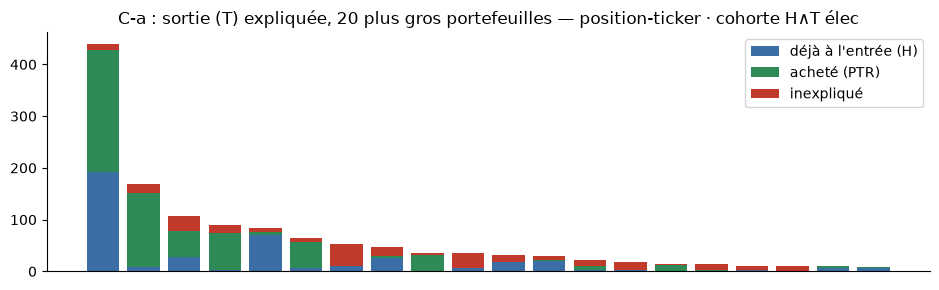

In [30]:
# ── §11.3 C-a : cohorte H∧T ──────────────────────────────────────────────────
EST_FONDS = re.compile(r"^[A-Z]{4}X$")
meta_min = rec_id.loc[~rec_id["doublon_index"], ["doc_id", "bioguide", "filing_date"]]
hold_b = holdings.merge(meta_min, on="doc_id", how="left")
hold_b = hold_b[hold_b["bioguide"].notna() & ~hold_b["ticker"].str.fullmatch(EST_FONDS)]

H_ = hold_b[hold_b["filing_type"] == "H"].groupby("bioguide")["filing_date"].min()
T_ = hold_b[hold_b["filing_type"] == "T"].groupby("bioguide")["filing_date"].max()
cohorte = sorted(set(H_.index) & set(T_.index))
cohorte = [b for b in cohorte if H_[b] < T_[b]]
print(f"cohorte H∧T élec : {len(cohorte)} membres")

achats_sig = sig[(sig["operation_type"].str.startswith("Purchase")) & sig["bioguide"].notna()]
lignes_ca = []
for b in cohorte:
    E = set(hold_b[(hold_b["bioguide"] == b) & (hold_b["filing_type"] == "H")]["ticker"])
    S = set(hold_b[(hold_b["bioguide"] == b) & (hold_b["filing_type"] == "T")]["ticker"])
    if not S:
        continue
    a = achats_sig[(achats_sig["bioguide"] == b) &
                   (achats_sig["transaction_date"] >= H_[b]) &
                   (achats_sig["transaction_date"] <= T_[b])]
    A = set(a["ticker"].dropna())
    lignes_ca.append(dict(bioguide=b, n_sortie=len(S),
                          deja_entree=len(S & E - A), achete=len(S & A),
                          inexplique=len(S - E - A)))
ca = pd.DataFrame(lignes_ca)
tot_S = int(ca["n_sortie"].sum())
tot_exp = int(ca["deja_entree"].sum() + ca["achete"].sum())
valider("C-a", "positions de sortie expliquées par entrée + achats PTR",
        pct(tot_exp, tot_S), unite="position-ticker",
        perimetre=f"cohorte H∧T élec ({len(ca)} membres), House", vert=75.0, orange=65.0,
        section="§11.3")
part_tout_du_long = pct(int(ca["deja_entree"].sum()), tot_S)
print(f"décomposition : déjà à l'entrée {part_tout_du_long} % · "
      f"acheté en cours {pct(int(ca['achete'].sum()), tot_S)} % · "
      f"inexpliqué {pct(int(ca['inexplique'].sum()), tot_S)} %")
print("→ la part « détenue tout du long, jamais tradée » est INVISIBLE d'un backtest qui "
      "part de zéro : c'est le patrimoine d'entrée qui la révèle")

fig, ax = plt.subplots(figsize=(9.5, 3))
d = ca.sort_values("n_sortie", ascending=False).head(20)
ax.bar(range(len(d)), d["deja_entree"], color="#3B6EA5", label="déjà à l'entrée (H)")
ax.bar(range(len(d)), d["achete"], bottom=d["deja_entree"], color="#2E8B57", label="acheté (PTR)")
ax.bar(range(len(d)), d["inexplique"], bottom=d["deja_entree"] + d["achete"],
       color="#C0392B", label="inexpliqué")
ax.set_title("C-a : sortie (T) expliquée, 20 plus gros portefeuilles — position-ticker · cohorte H∧T élec")
ax.legend(); ax.set_xticks([]); ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout(); plt.show()

paires d'annuels consécutifs (~1 an) : 2508 sur 609 membres avec ≥1 annuel élec


🟢 [C-b] positions de l'annuel N+1 expliquées par annuel N + achats PTR = 85.0  (position-ticker · paires d'annuels élec (2508 paires, 533 membres) · 2014-2026)


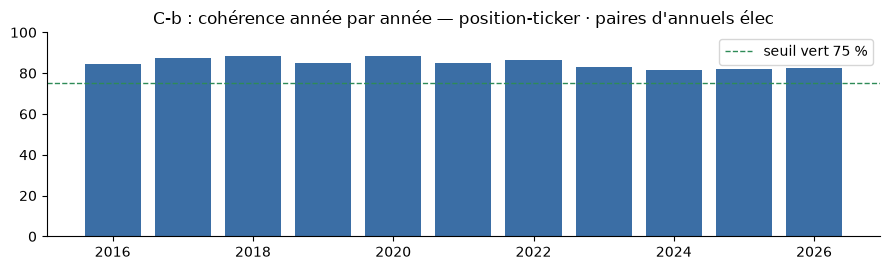

In [31]:
# ── §11.4 C-b : année par année via les annuels (O) ──────────────────────────
O_docs = (hold_b[hold_b["filing_type"] == "O"]
          .groupby(["bioguide", "doc_id", "filing_date"]).size().reset_index()
          [["bioguide", "doc_id", "filing_date"]].sort_values(["bioguide", "filing_date"]))
paires = []
for b, g in O_docs.groupby("bioguide"):
    docs = list(g.itertuples())
    for d1, d2 in zip(docs, docs[1:]):
        ecart = (d2.filing_date - d1.filing_date).days
        if 200 <= ecart <= 500:                      # vraies transitions ~annuelles
            paires.append((b, d1.doc_id, d1.filing_date, d2.doc_id, d2.filing_date))
print(f"paires d'annuels consécutifs (~1 an) : {len(paires)} "
      f"sur {O_docs['bioguide'].nunique()} membres avec ≥1 annuel élec")

par_doc = {d: set(g["ticker"]) for d, g in hold_b.groupby("doc_id")}
rows_cb = []
for b, doc1, f1, doc2, f2 in paires:
    prev_, now_ = par_doc.get(doc1, set()), par_doc.get(doc2, set())
    if not now_:
        continue
    a = achats_sig[(achats_sig["bioguide"] == b) &
                   (achats_sig["transaction_date"] > f1) &
                   (achats_sig["transaction_date"] <= f2 + pd.Timedelta(days=120))]
    A = set(a["ticker"].dropna())
    rows_cb.append(dict(bioguide=b, an=f2.year, n_now=len(now_),
                        expl=len(now_ & (prev_ | A)), gap=len(now_ - prev_ - A)))
cb = pd.DataFrame(rows_cb)
valider("C-b", "positions de l'annuel N+1 expliquées par annuel N + achats PTR",
        pct(int(cb["expl"].sum()), int(cb["n_now"].sum())), unite="position-ticker",
        perimetre=f"paires d'annuels élec ({len(cb)} paires, {cb['bioguide'].nunique()} membres)",
        vert=75.0, orange=65.0, section="§11.4")
par_an_cb = cb.groupby("an").apply(lambda g: pct(int(g["expl"].sum()), int(g["n_now"].sum())),
                                   include_groups=False)
fig, ax = plt.subplots(figsize=(9, 2.8))
ax.bar(par_an_cb.index, par_an_cb.values, color="#3B6EA5")
ax.axhline(75, color="#2E8B57", ls="--", lw=1, label="seuil vert 75 %")
ax.set_title("C-b : cohérence année par année — position-ticker · paires d'annuels élec")
ax.set_ylim(0, 100); ax.legend(); ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout(); plt.show()

In [32]:
# ── §11.5 C-c : le Schedule B des annuels recoupe-t-il les PTR ? ──────────────
# Chaque transaction tickérisée déclarée dans un annuel (O) ou un amendement (A) devrait
# avoir son PTR (l'annuel RÉCAPITULE l'année). Le taux mesure la complétude des PTR ;
# la SENTINELLE : plus aucune action « annuel-seul » après 2017 (PoC : les 173 cas
# étaient TOUS 2014-2017).
fd_tick = fdt[fdt["ticker"].notna() & fdt["bioguide"].notna() &
              fdt["transaction_date"].notna() &
              fdt["filing_type"].isin(["O", "A"])].copy()
sig_tick = sig[sig["ticker"].notna() & sig["bioguide"].notna() & sig["transaction_date"].notna()]
cle_sig, cle_sig_tous_sens = {}, {}
for r in sig_tick.itertuples():
    cle_sig.setdefault((r.bioguide, r.ticker, r.operation_type[0]), []).append(r.transaction_date)
    cle_sig_tous_sens.setdefault((r.bioguide, r.ticker), []).append(r.transaction_date)

def match_ptr(r):
    """Niveaux : même sens (exact/±10 j/±90 j/±365 j retard extrême) puis, à défaut,
    même (membre, ticker) TOUS SENS à ±10 j = « sens divergent » (coquille de l'un des
    deux documents — le trade est bien PTRé, ex. Exchange vs Sale d'une scission)."""
    dates = cle_sig.get((r.bioguide, r.ticker, r.operation_type[0]), [])
    if dates:
        d = min(abs((x - r.transaction_date).days) for x in dates)
        if d == 0:   return "exact"
        if d <= 10:  return "±10j"
        if d <= 90:  return "±90j"
        if d <= 365: return "±365j_retard"
    autres = cle_sig_tous_sens.get((r.bioguide, r.ticker), [])
    if autres and min(abs((x - r.transaction_date).days) for x in autres) <= 10:
        return "sens_divergent"
    return "aucun"

fd_tick["match"] = fd_tick.apply(match_ptr, axis=1)
n_match = int((fd_tick["match"] != "aucun").sum())
print(dict(fd_tick["match"].value_counts()))
print(f"taux brut (tous membres, y c. déposants papier) : {pct(n_match, len(fd_tick))} % — info")
# le CONTRÔLE se limite aux (membre, année) SANS PTR scanné : là, tout doit se retrouver
scan_p0 = ledger[(ledger["filing_type"] == "P") & (ledger["statut"] == "scanne_hors_V1")]
scan_p0 = scan_p0.merge(rec_id[["doc_id", "bioguide"]], on="doc_id", how="left")
annees_papier0 = set(zip(scan_p0["bioguide"], scan_p0["annee_index"].astype(int)))
an_tx = fd_tick["transaction_date"].dt.year
elig = fd_tick[[(b, int(a)) not in annees_papier0 if pd.notna(a) else False
                for b, a in zip(fd_tick["bioguide"], an_tx)]]
valider("C-c", "transactions des annuels retrouvées dans les PTR (membres sans PTR papier)",
        pct(int((elig["match"] != "aucun").sum()), len(elig)), unite="transaction",
        perimetre="Schedule B O/A élec, membres·années sans PTR scanné", vert=60.0,
        orange=50.0, section="§11.5")

non_m = fd_tick[fd_tick["match"] == "aucun"].copy()
non_m["an_txn"] = non_m["transaction_date"].dt.year
# « papier attendu » : le membre a déposé au moins un PTR SCANNÉ (hors V1) cette année-là
# → son PTR existe sans doute sur papier, la V1 ne peut pas le voir. Classé, pas compté.
scan_p = ledger[(ledger["filing_type"] == "P") & (ledger["statut"] == "scanne_hors_V1")]
scan_p = scan_p.merge(rec_id[["doc_id", "bioguide"]], on="doc_id", how="left")
annees_papier = set(zip(scan_p["bioguide"], scan_p["annee_index"].astype(int)))
non_m["papier_attendu"] = [
    (b, int(a)) in annees_papier if pd.notna(a) else False
    for b, a in zip(non_m["bioguide"], non_m["an_txn"])]
# ETF et fonds mutuels sont des « excepted investment funds » : EXEMPTÉS de PTR par le
# STOCK Act — leur absence des PTR est LÉGALE. Référence : ticker_sector_map.csv (donnée).
smap = pd.read_csv(REFERENCE / "ticker_sector_map.csv", dtype=str)
TICKERS_ETF = set(smap.loc[smap["asset_class"].str.startswith("etf", na=False), "ticker"])
recentes = non_m[(non_m["an_txn"] >= 2018) & ~non_m["papier_attendu"] &
                 non_m["ticker"].notna() & ~non_m["ticker"].str.fullmatch(EST_FONDS) &
                 ~non_m["ticker"].isin(TICKERS_ETF)]
print(f"non-matchées classées « papier attendu » : {int(non_m['papier_attendu'].sum()):,} · "
      f"ETF/fonds exemptés écartés : {int(non_m['ticker'].isin(TICKERS_ETF).sum()):,}")
recentes.to_csv(TABLES / "annexe_actions_annuel_seul.csv", index=False)
valider("C-c2", "transactions « annuel-seul » ≥ 2018 (contient des ETF non classés par la map)",
        len(recentes), unite="transaction",
        perimetre="Schedule B O/A élec, hors papier attendu, hors ETF/fonds exemptés connus",
        section="§11.5")                                       # INFO : mesure du gisement
print("top tickers annuel-seul :", dict(recentes["ticker"].value_counts().head(12)))
# la SENTINELLE anti-régression porte sur les ACTIONS CONNUES (asset_class=stock de la map,
# donc tradées en PTR par ailleurs) : un achat/vente d'une telle action sans AUCUN PTR
# à ±365 j est un vrai trou de complétude (ex. vérifiés : achats jamais PTRés dont la
# vente ultérieure, elle, est PTRée — Moskowitz CAT 2023, Goldman APPS 2023).
TICKERS_STOCK = set(smap.loc[smap["asset_class"] == "stock", "ticker"])
recentes_stock = recentes[recentes["ticker"].isin(TICKERS_STOCK)]
valider("C-c2b", "dont tickers classés « action » par la map héritée",
        len(recentes_stock), unite="transaction",
        perimetre="Schedule B O/A élec ≥2018, actions de la map, hors papier attendu",
        section="§11.5")                                        # INFO : mesure, pas verdict
print("audit d'échantillon : mélange de VRAIS trades jamais PTRés (AMGN Moskowitz 2023, "
      "MSCI/BKNG Gottheimer, SU Evans…) et d'ETF que la map héritée classe à tort « stock » "
      "(QYLD, VGT, VNQ, FDN…). Épurer cette mesure = classifier proprement les ETF (V2).")
print("→ liste complète en annexe_actions_annuel_seul.csv")
if len(recentes):
    print("chaque cas ≥2018 listé (candidats : PTR raté par V1, PTR papier, vrai non-dépôt) :")
    display(recentes[["doc_id", "declarant_name", "ticker", "transaction_date_brute",
                      "operation_type", "amount_range"]].head(20))
lag_nm = (non_m["disclosure_date"] - non_m["transaction_date"]).dt.days.dropna()
if len(lag_nm):
    print(f"délai médian de divulgation des non-matchées : {lag_nm.median():.0f} j "
          f"(vs ~30 j pour un PTR) → inexploitables comme signal daté, même récupérées")

# C-c′ (nouveau) : le sens inverse — les PTR se retrouvent-ils dans l'annuel suivant ?
sig_actions = sig_tick[~sig_tick["ticker"].str.fullmatch(EST_FONDS)].copy()
cle_fd = {}
for r in fd_tick.itertuples():
    cle_fd.setdefault((r.bioguide, r.ticker, r.operation_type[0]), []).append(r.transaction_date)
def dans_fd(r):
    dates = cle_fd.get((r.bioguide, r.ticker, r.operation_type[0]), [])
    return any(abs((x - r.transaction_date).days) <= 10 for x in dates)
bios_avec_annuel = set(fd_tick["bioguide"])
sig_elig = sig_actions[sig_actions["bioguide"].isin(bios_avec_annuel)]
n_inv = int(sig_elig.apply(dans_fd, axis=1).sum())
valider("C-c'", "PTR retrouvés dans un Schedule B d'annuel (±10 j) — 1re mesure de référence",
        pct(n_inv, len(sig_elig)), unite="transaction",
        perimetre="PTR actions élec des membres ayant ≥1 annuel élec", section="§11.5")

{'aucun': np.int64(27016), 'exact': np.int64(18422), '±365j_retard': np.int64(3902), '±90j': np.int64(3141), '±10j': np.int64(1220), 'sens_divergent': np.int64(634)}
taux brut (tous membres, y c. déposants papier) : 50.3 % — info
🟠 [C-c] transactions des annuels retrouvées dans les PTR (membres sans PTR papier) = 51.6  (transaction · Schedule B O/A élec, membres·années sans PTR scanné · 2014-2026)
non-matchées classées « papier attendu » : 2,964 · ETF/fonds exemptés écartés : 5,207
ℹ️ [C-c2] transactions « annuel-seul » ≥ 2018 (contient des ETF non classés par la map) = 8311  (transaction · Schedule B O/A élec, hors papier attendu, hors ETF/fonds exemptés connus · 2014-2026)
top tickers annuel-seul : {'JST-E': np.int64(84), 'FI': np.int64(79), 'BND': np.int64(78), 'VEU': np.int64(73), 'QYLD': np.int64(69), 'SND': np.int64(62), 'KPL': np.int64(57), 'VSGX': np.int64(54), 'ESGV': np.int64(53), 'ESML': np.int64(52), 'ESGD': np.int64(51), 'ESGU': np.int64(50)}
ℹ️ [C-c2b] dont tickers classé

,doc_id,declarant_name,ticker,transaction_date_brute,operation_type,amount_range
7078,10008410,Austin Scott,PLUG,03/4/2104,Sale,"$15,001 - $50,000"
19941,10012399,Luis V. Gutierrez,EMB,10/22/2105,Sale,"$1,001 - $15,000"
36449,10020790,Scott H. Peters,CSJ,04/12/2107,Sale,"$500,001 - $1,000,000"
48981,10025806,Bob Gibbs,AMZN,03/9/2018,Purchase,"$1,001 - $15,000"
48989,10025806,Bob Gibbs,AAPL,12/28/2018,Sale,$158.65
48991,10025806,Bob Gibbs,T,10/4/2018,Purchase,"$15,001 - $50,000"
48992,10025806,Bob Gibbs,BA,02/27/2018,Sale,"$1,001 - $15,000"
48993,10025806,Bob Gibbs,CAH,04/17/2018,Purchase,"$15,001 - $50,000"
48996,10025806,Bob Gibbs,GXP,09/19/2018,Purchase,"$15,001 - $50,000"
49000,10025806,Bob Gibbs,SEP,09/5/2018,Sale,"$1,001 - $15,000"


délai médian de divulgation des non-matchées : 383 j (vs ~30 j pour un PTR) → inexploitables comme signal daté, même récupérées


ℹ️ [C-c'] PTR retrouvés dans un Schedule B d'annuel (±10 j) — 1re mesure de référence = 48.9  (transaction · PTR actions élec des membres ayant ≥1 annuel élec · 2014-2026)


'INFO'

In [33]:
# ── §11.6 I2 : géographie — StateDst vs mandats du référentiel ────────────────
mandats_de = dict(zip(REPS["bioguide"], REPS["mandats"]))
docs_r = rec_id[rec_id["bioguide"].notna() & ~rec_id["doublon_index"] &
                rec_id["filing_type"].isin(TYPES_PARSES)].copy()
def verdict_geo(r):
    etat = _etat_de(r["state_district"])
    mandats = mandats_de.get(r["bioguide"], [])
    if not etat or not mandats:
        return "indeterminable"
    if any(m[2] == etat for m in mandats):
        return "ok"
    return "CONFLIT"
docs_r["geo"] = docs_r.apply(verdict_geo, axis=1)
conflits = docs_r[docs_r["geo"] == "CONFLIT"]
valider("I2", "CONFLIT d'État entre le dépôt et les mandats du bioguide", len(conflits),
        unite="document", perimetre="docs rattachés P+C/O/H/T/A, House", vert=0, orange=5,
        sens="<=", section="§11.6")
if len(conflits):
    print("conflits (le détecteur qui aurait attrapé la collision d'identité corrigée en dur "
          "dans l'ancien pipeline) :")
    display(conflits[["doc_id", "last", "first", "filing_type", "state_district",
                      "bioguide", "annee_index"]].head(12))

🟠 [I2] CONFLIT d'État entre le dépôt et les mandats du bioguide = 4  (document · docs rattachés P+C/O/H/T/A, House · 2014-2026)
conflits (le détecteur qui aurait attrapé la collision d'identité corrigée en dur dans l'ancien pipeline) :


,doc_id,last,first,filing_type,state_district,bioguide,annee_index
4057,9109363,Murphy,Patrick,C,IA01,M001191,2016
6477,8218680,Hurt,Robert,O,CE00,H001060,2017
6478,8219014,Hurt,Robert,O,CE00,H001060,2017
34371,9107645,Murphy,Patrick,A,IA01,M001191,2014


### §11.7 — L'hypothèse « blind trust » : la conservation, cas par cas

**Idée testée.** Une *fiducie aveugle* (blind trust) fait passer les trades par un
gestionnaire indépendant — **hors PTR**. L'identité entrée (H) + achats (P) ⊇ sortie (T)
de §11.3 devrait donc « caler » pour ces élus. On le vérifie **sans OCR**, sur les données
déjà en main.

Côté Chambre : **type B = blind trust**. Leurs dépôts B (la lettre de banque qui liste les
ventes du trust) sont **tous scannés** → non parsés en V1. Mais ces élus ont, à côté, des
rapports **numériques** (H/T, PTR, patrimoine). Que devient alors la conservation ?

In [34]:
# ── §11.7.1 — Recenser les blind-trusts (type B) : dépôts tous scannés ───────────────
bt = rec_id[rec_id["filing_type"] == "B"].copy()
bt["scanne"] = bt["prefixe_docid"].isin(["8", "9"])
recap_bt = (bt.groupby("last")
            .agg(depots_B=("doc_id", "size"), tous_scannes=("scanne", "all"),
                 annees=("year", lambda s: f"{s.min()}–{s.max()}"))
            .reset_index().sort_values("depots_B", ascending=False))
print(f"type B (blind trust) : {len(bt)} dépôts · {bt['last'].nunique()} élus · "
      f"tous scannés = {bool(bt['scanne'].all())}  → ventes du trust NON parsées (V1)")
display(recap_bt)
bt_bios = set(bt["bioguide"].dropna())
bio2last = (rec_id.dropna(subset=["bioguide"]).drop_duplicates("bioguide")
            .set_index("bioguide")["last"].to_dict())

type B (blind trust) : 23 dépôts · 5 élus · tous scannés = True  → ventes du trust NON parsées (V1)


,last,depots_B,tous_scannes,annees
3,Phillips,19,True,2021–2025
0,Malinowski,1,True,2021–2021
1,Maloney,1,True,2018–2018
2,Moore,1,True,2022–2022
4,Schrier,1,True,2022–2022


#### La conservation ne trouve pas des *trous* pour eux — elle trouve un *portefeuille disparu*

La cohorte de §11.3 exige un **H** et un **T** numériques. Regardons ce que le patrimoine
tickérisé des blind-trusts devient entre l'entrée et la sortie, face à un témoin sans trust.

blind-trusts avec H+T numériques (entrée→sortie, tickers) : [('Phillips', '284→1'), ('Malinowski', '34→0')]


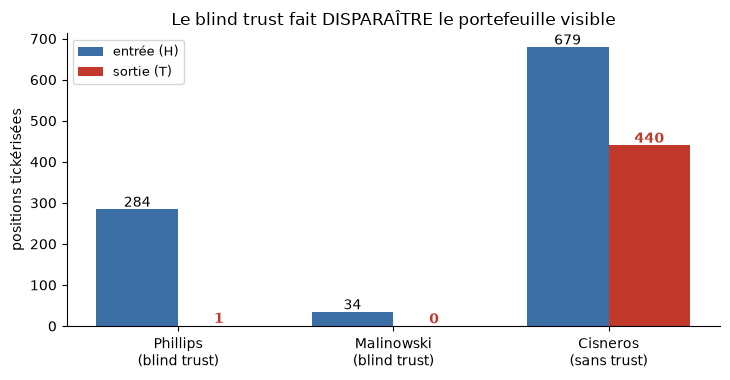

In [35]:
# ── §11.7.2 — Entrée (H) → sortie (T) : le portefeuille visible s'effondre ────────────
def a_doc_num(bio, ft):
    return len(rec_id[(rec_id["bioguide"] == bio) & (rec_id["filing_type"] == ft) &
                      (rec_id["prefixe_docid"].isin(["1", "2"]))]) > 0
def entree_sortie(bio):
    E = set(hold_b[(hold_b["bioguide"] == bio) & (hold_b["filing_type"] == "H")]["ticker"])
    S = set(hold_b[(hold_b["bioguide"] == bio) & (hold_b["filing_type"] == "T")]["ticker"])
    return len(E), len(S)
bt_ht = sorted([(bio2last[b], b, *entree_sortie(b)) for b in bt_bios
                if a_doc_num(b, "H") and a_doc_num(b, "T")], key=lambda r: -r[2])
print("blind-trusts avec H+T numériques (entrée→sortie, tickers) :",
      [(l, f"{e}→{s}") for l, b, e, s in bt_ht])
temoin = ca.sort_values("n_sortie", ascending=False).iloc[0]
te, ts = entree_sortie(temoin["bioguide"])
labels = [f"{l}\n(blind trust)" for l, b, e, s in bt_ht] + [f"{bio2last[temoin['bioguide']]}\n(sans trust)"]
ent = [e for l, b, e, s in bt_ht] + [te]
sor = [s for l, b, e, s in bt_ht] + [ts]
fig, ax = plt.subplots(figsize=(7.4, 3.9))
x = np.arange(len(labels)); w = 0.38
ax.bar(x - w/2, ent, w, label="entrée (H)", color="#3b6ea5")
ax.bar(x + w/2, sor, w, label="sortie (T)", color="#c0392b")
for k, (e, s) in enumerate(zip(ent, sor)):
    ax.text(k - w/2, e + max(ent)*0.01, str(e), ha="center", fontsize=10)
    ax.text(k + w/2, s + max(ent)*0.01, str(s), ha="center", fontsize=10, color="#c0392b", fontweight="bold")
ax.set_xticks(x); ax.set_xticklabels(labels); ax.set_ylabel("positions tickérisées")
ax.set_title("Le blind trust fait DISPARAÎTRE le portefeuille visible")
ax.legend(fontsize=9); ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout(); plt.show()

In [36]:
# ── §11.7.3 — Où sont passés les titres ? Dans une ligne « Qualified Blind Trust » opaque ─
ph_T = rec_id[(rec_id["last"] == "Phillips") & (rec_id["filing_type"] == "T") &
              (rec_id["prefixe_docid"].isin(["1", "2"]))]
ph_doc, ph_an = ph_T["doc_id"].iloc[0], ph_T["annee_index"].iloc[0]
p_txt = chemin_txt("T", ph_an, ph_doc)
if p_txt.exists():
    txt_T = re.sub(r"\s+", " ", p_txt.read_text(encoding="utf-8", errors="replace"))
    i = txt_T.find("Qualified Blind Trust")
    print(f"Schedule A de SORTIE de Dean Phillips (doc {ph_doc}, {ph_an}) — extrait réel :")
    print("   …", txt_T[i:i+95].strip(), "…")
    print("\n→ le patrimoine (plusieurs M$) est ramassé dans UNE ligne « Qualified Blind Trust [EQ] »,")
    print("  SANS ticker → invisible à un suivi par action : la sortie tickérisée de Phillips")
    print("  tombe à 1 alors qu'il était entré avec 284.")
else:
    print("(texte de", ph_doc, "non caché — relancer §5.1)")

Schedule A de SORTIE de Dean Phillips (doc 10063264, 2025) — extrait réel :
   … Qualified Blind Trust [EQ] $5,000,001 - QBT Income $100,001 - $25,000,000 $1,000,000 US Bank - …

→ le patrimoine (plusieurs M$) est ramassé dans UNE ligne « Qualified Blind Trust [EQ] »,
  SANS ticker → invisible à un suivi par action : la sortie tickérisée de Phillips
  tombe à 1 alors qu'il était entré avec 284.


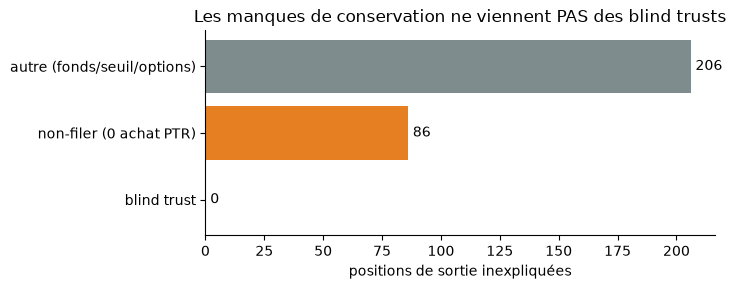

blind-trusts dans la cohorte : 1 (sorties = [1]) ; avec ≥5 positions de sortie = 0
🟢 [C-d] blind-trusts au portefeuille de sortie NON effondré (≥5 positions) = 0  (membre · déposants type B, House · 2014-2026)
🟢 [C-e] positions inexpliquées attribuées à un blind trust = 0  (position-ticker · cohorte H∧T, House · 2014-2026)


'VERT'

In [37]:
# ── §11.7.4 — Les positions inexpliquées de la cohorte ne viennent PAS des blind-trusts ─
nb_achats = achats_sig.groupby("bioguide").size()
def cause(bio):
    if bio in bt_bios: return "blind trust"
    if nb_achats.get(bio, 0) == 0: return "non-filer (0 achat PTR)"
    return "autre (fonds/seuil/options)"
inx = ca[ca["inexplique"] > 0].copy()
inx["cause"] = inx["bioguide"].map(cause)
attr = inx.groupby("cause")["inexplique"].sum()
for c in ["blind trust", "non-filer (0 achat PTR)", "autre (fonds/seuil/options)"]:
    attr.loc[c] = attr.get(c, 0)
attr = attr.sort_values()
fig, ax = plt.subplots(figsize=(7.4, 3.0))
col = {"blind trust": "#8e44ad", "non-filer (0 achat PTR)": "#e67e22", "autre (fonds/seuil/options)": "#7f8c8d"}
ax.barh(range(len(attr)), attr.values, color=[col.get(c, "#999") for c in attr.index])
ax.set_yticks(range(len(attr))); ax.set_yticklabels(attr.index)
for j, v in enumerate(attr.values):
    ax.text(v + max(attr)*0.01, j, str(int(v)), va="center", fontsize=10)
ax.set_xlabel("positions de sortie inexpliquées")
ax.set_title("Les manques de conservation ne viennent PAS des blind trusts")
ax.spines[["top", "right"]].set_visible(False); plt.tight_layout(); plt.show()

bt_dans_ca = ca[ca["bioguide"].isin(bt_bios)]
n_bt_suivi = int((bt_dans_ca["n_sortie"] >= 5).sum())
print(f"blind-trusts dans la cohorte : {len(bt_dans_ca)} "
      f"(sorties = {list(bt_dans_ca['n_sortie'])}) ; avec ≥5 positions de sortie = {n_bt_suivi}")
valider("C-d", "blind-trusts au portefeuille de sortie NON effondré (≥5 positions)", n_bt_suivi,
        unite="membre", perimetre="déposants type B, House", vert=0, orange=1, sens="<=", section="§11.7")
valider("C-e", "positions inexpliquées attribuées à un blind trust", int(attr.get("blind trust", 0)),
        unite="position-ticker", perimetre="cohorte H∧T, House", vert=0, orange=2, sens="<=", section="§11.7")

#### Conclusion — l'intuition est juste, mais le manque est une *disparition*, pas un *écart*

- Le contrôle §11.3 confirme l'idée maîtresse : **78,7 %** des positions de sortie
  s'expliquent par l'entrée + les achats PTR.
- **Les blind-trusts ne créent pas de trous** : leur part des positions inexpliquées = **0**
  (`C-e`), et aucun ne garde un portefeuille de sortie non effondré (`C-d = 0`). Phillips
  entre avec 284 positions tickérisées et en sort **1** ; Malinowski 34 → **0**.
- La raison : le blind trust est reporté comme **une ligne opaque « Qualified Blind Trust [EQ] »**
  de plusieurs M$, **sans ticker** → le portefeuille visible **disparaît**, il ne « fuit » pas.
- C'est donc un **manque de COUVERTURE** (on ne voit plus rien), pas un écart de conservation.
  Mesurer les mouvements internes du trust exigerait d'**OCRiser les dépôts type B** (lettres
  de banque scannées) → **reporté en V2**.
- Les vraies positions inexpliquées de la cohorte sont ailleurs : **non-filers** et
  **fonds / seuil 1 000 $ / options** (voir figure ci-dessus).

## §12 — La confrontation avec l'ancien pipeline : chaque écart expliqué

Référence : les 13 tables `06_house_{Y}_FINAL.csv` de l'ancien pipeline, restreintes à la
**piste électronique** (`provenance = house-pdf-electronic`) — le périmètre comparable à
la V1 (l'OCR est hors V1 par design).

Avertissement de méthode : les CSV figés de l'ancien pipeline sont **faux tels quels**
(fourchettes tronquées → midpoints ÷2 sur 7 995 lignes, coquilles de dates, réparés
seulement « à la lecture » par son code). Pour comparer proprement, on **rejoue ici** la
normalisation des fourchettes (via notre grille §6) sur ses données. Puis :
- **X1, niveau document** : quels DocID l'un a-t-il et pas l'autre ? (attendu :
  V1-seulement = ses gains — nouveaux PTR de juillet, parse_failures anciens ;
  ancien-seulement = 0) ;
- **X2, niveau compte par document** : pour chaque doc commun, les deux comptes de
  transactions — chaque désaccord est **arbitré par deux marqueurs indépendants du
  document lui-même** (nombre de lignes « FILING STATUS », nombre de lignes à deux
  dates) : celui qui s'écarte des marqueurs a tort.

In [38]:
# ── §12.1 X1 : niveau document ────────────────────────────────────────────────
vieux_frames = []
for y in ANNEES:
    f = ANCIEN / "data" / "house" / "tables" / str(y) / f"06_house_{y}_FINAL.csv"
    if f.exists():
        d = pd.read_csv(f, dtype=str, usecols=["doc_id", "provenance", "transaction_date",
                                               "ticker", "operation_type", "amount_range"])
        vieux_frames.append(d[d["provenance"] == "house-pdf-electronic"])
vieux = pd.concat(vieux_frames, ignore_index=True)
docs_vieux = set(vieux["doc_id"])
docs_v1 = set(txns_ptr["doc_id"])       # parsing BRUT : la dédup cross-doc vide les
                                        # re-dépôts exacts, ce n'est pas un raté de parse
print(f"docs élec : ancien {len(docs_vieux):,} · V1 {len(docs_v1):,} · "
      f"communs {len(docs_vieux & docs_v1):,}")

v1_seul = docs_v1 - docs_vieux
vieux_seul = docs_vieux - docs_v1
etat_led = dict(zip(ledger["doc_id"], ledger["statut"]))
print(f"V1 seulement : {len(v1_seul)} (gains : nouveaux PTR de juillet + docs que l'ancien "
      f"avait en parse_failures)")
ventil = pd.Series([etat_led.get(d, "hors_ledger") for d in vieux_seul]).value_counts()
print("ancien seulement, par statut V1 :", dict(ventil))
# les contradictoires (V1 a lu le doc et n'y voit AUCUNE transaction) → arbitrage marqueurs
contradictoires = [d for d in vieux_seul
                   if etat_led.get(d) in ("parse_0_ligne", "parse_ok", "parse_ok_vide")]
an_doc0 = dict(zip(ledger["doc_id"], ledger["annee_index"]))
RE_FS0 = re.compile(r"f\s*i\s*l\s*i\s*n\s*g\s+s\s*t\s*a\s*t\s*u\s*s", re.IGNORECASE)
RE_DD0 = re.compile(r"\d{1,2}/\d{1,2}/\d{4}\s+\d{1,2}/\d{1,2}/\d{4}")
v1_rate_x1 = []
for d in contradictoires:
    t = chemin_txt("P", an_doc0[d], d).read_text(encoding="utf-8")
    if len(RE_DD0.findall(t)) > 0:                    # le doc contient bien des transactions
        v1_rate_x1.append(dict(doc_id=d, annee=an_doc0[d], marqueur_2dates=len(RE_DD0.findall(t)),
                               marqueur_fs=len(RE_FS0.findall(t))))
valider("X1", "docs où l'ancien voyait des txns, V1 zéro, et les marqueurs lui donnent raison",
        len(v1_rate_x1), unite="document", perimetre="P élec, House", vert=0, orange=5,
        sens="<=", section="§12.1")
if v1_rate_x1:
    display(pd.DataFrame(v1_rate_x1).head(15))

docs élec : ancien 5,798 · V1 5,842 · communs 5,798
V1 seulement : 44 (gains : nouveaux PTR de juillet + docs que l'ancien avait en parse_failures)
ancien seulement, par statut V1 : {}
🟢 [X1] docs où l'ancien voyait des txns, V1 zéro, et les marqueurs lui donnent raison = 0  (document · P élec, House · 2014-2026)


In [39]:
# ── §12.2 X2 : comptes par document, arbitrés par les marqueurs du document ──
old_counts = vieux.groupby("doc_id").size()
v1_counts = txns_ptr.groupby("doc_id").size()      # brut, comparable au FINAL par-année
communs = sorted(docs_vieux & docs_v1)
cmp_ = pd.DataFrame({"vieux": old_counts.reindex(communs),
                     "v1": v1_counts.reindex(communs)}).fillna(0).astype(int)
cmp_["delta"] = cmp_["v1"] - cmp_["vieux"]
egaux = int((cmp_["delta"] == 0).sum())
print(f"docs à compte IDENTIQUE : {egaux:,}/{len(cmp_):,} ({pct(egaux, len(cmp_))} %)")

RE_FS = re.compile(r"f\s*i\s*l\s*i\s*n\s*g\s+s\s*t\s*a\s*t\s*u\s*s", re.IGNORECASE)
RE_DD = re.compile(r"\d{1,2}/\d{1,2}/\d{4}\s+\d{1,2}/\d{1,2}/\d{4}")
an_doc = dict(zip(ledger["doc_id"], ledger["annee_index"]))
arbitrage = []
for d, r in cmp_[cmp_["delta"] != 0].iterrows():
    t = chemin_txt("P", an_doc[d], d).read_text(encoding="utf-8")
    fs, dd = len(RE_FS.findall(t)), len(RE_DD.findall(t))
    if r["v1"] == fs == dd or (fs == 0 and r["v1"] == dd):     # FS absent de certains gabarits
        verdict = "ancien_surcompte" if r["vieux"] > r["v1"] else "ancien_sous_compte"
    elif r["vieux"] == fs == dd or (fs == 0 and r["vieux"] == dd):
        verdict = "v1_a_tort"
    else:
        verdict = "marqueurs_ambigus"
    arbitrage.append(dict(doc_id=d, v1=r["v1"], vieux=r["vieux"], marqueur_fs=fs,
                          marqueur_2dates=dd, verdict=verdict))
arb = pd.DataFrame(arbitrage)
if len(arb):
    print(dict(arb["verdict"].value_counts()))
    surc = arb[arb["verdict"] == "ancien_surcompte"]
    print(f"transactions FANTÔMES de l'ancien pipeline (surcomptage dual legacy/moderne) : "
          f"{int((surc['vieux'] - surc['v1']).sum()):,} sur {len(surc)} docs")
    sous = arb[arb["verdict"] == "ancien_sous_compte"]
    print(f"transactions RATÉES par l'ancien : {int((sous['v1'] - sous['vieux']).sum()):,} "
          f"sur {len(sous)} docs")
    v1_tort = arb[arb["verdict"] == "v1_a_tort"]
    valider("X2", "docs où l'arbitrage par marqueurs donne tort à la V1", len(v1_tort),
            unite="document", perimetre="P élec communs à compte ≠, House",
            vert=0, orange=10, sens="<=", section="§12.2")
    if len(v1_tort):
        display(v1_tort.head(15))
    ambigus = arb[arb["verdict"] == "marqueurs_ambigus"]
    valider("X2b", "docs à compte ≠ non arbitrables par les marqueurs", len(ambigus),
            unite="document", perimetre="P élec communs, House", vert=0, orange=25,
            sens="<=", section="§12.2")
    if len(ambigus):
        display(ambigus.head(15))

docs à compte IDENTIQUE : 4,699/5,798 (81.0 %)
{'ancien_surcompte': np.int64(727), 'ancien_sous_compte': np.int64(371), 'marqueurs_ambigus': np.int64(1)}
transactions FANTÔMES de l'ancien pipeline (surcomptage dual legacy/moderne) : 2,950 sur 727 docs
transactions RATÉES par l'ancien : 564 sur 371 docs
🟢 [X2] docs où l'arbitrage par marqueurs donne tort à la V1 = 0  (document · P élec communs à compte ≠, House · 2014-2026)
🟠 [X2b] docs à compte ≠ non arbitrables par les marqueurs = 1  (document · P élec communs, House · 2014-2026)


,doc_id,v1,vieux,marqueur_fs,marqueur_2dates,verdict
868,20016887,43,42,44,44,marqueurs_ambigus


In [40]:
# ── §12.3 X3 : les champs, doc par doc (sur les docs à compte identique) ─────
# clé multiset (date, sens, fourchette NORMALISÉE par notre grille) — le ticker de
# l'ancien peut différer (récupérations LLM en aval), on le compare séparément.
def norm_fourchette_ancienne(s):
    f = parse_fourchette(str(s))
    return f["libelle"] if f else str(s)

vieux_c = vieux[vieux["doc_id"].isin(cmp_[cmp_["delta"] == 0].index)].copy()
vieux_c["af"] = vieux_c["amount_range"].map(norm_fourchette_ancienne)
sig_c = txns_ptr[txns_ptr["doc_id"].isin(cmp_[cmp_["delta"] == 0].index)].copy()
sig_c["td"] = pd.to_datetime(sig_c["transaction_date"], format="%m/%d/%Y",
                             errors="coerce").dt.strftime("%Y-%m-%d")   # même ISO que l'ancien

def multiset(df, cd, cs, ca):
    return Counter(zip(df["doc_id"], df[cd].astype(str), df[cs].astype(str).str[0], df[ca]))
ms_v, ms_n = multiset(vieux_c, "transaction_date", "operation_type", "af"), \
             multiset(sig_c, "td", "operation_type", "amount_range")
seulement_vieux = ms_v - ms_n
seulement_v1 = ms_n - ms_v
n_total = sum(ms_n.values())
valider("X3", "lignes divergentes sur docs à compte identique (date, sens, fourchette)",
        pct(sum(seulement_v1.values()), n_total), unite="transaction",
        perimetre="P élec, docs à compte identique", vert=1.0, orange=3.0, sens="<=",
        section="§12.3")
if seulement_v1:
    ex = list(seulement_v1.items())[:8]
    print("exemples V1 ≠ ancien (doc, date, sens, fourchette) :")
    for k, n in ex:
        print("  V1    :", k, "×", n)
    for k, n in list(seulement_vieux.items())[:8]:
        print("  ancien:", k, "×", n)

# lien avec la table publiée : rappel des ordres de grandeur (info, unités étiquetées)
print(f"\nINFO — table clean publiée (data/clean/…2014_2026.csv) : 47 609 lignes House élec "
      f"(transaction · post-entonnoir A-D) ; V1 signal ptr : {len(sig):,} lignes AVANT "
      f"entonnoir (fenêtres, actions/ETF, dédup Quiver…) — comparaison détaillée = étape "
      f"suivante du chantier, une fois le cache complet.")

🟠 [X3] lignes divergentes sur docs à compte identique (date, sens, fourchette) = 1.5  (transaction · P élec, docs à compte identique · 2014-2026)


exemples V1 ≠ ancien (doc, date, sens, fourchette) :
  V1    : ('20002982', '2014-06-04', 'S', '$1,001 - $15,000') × 1
  V1    : ('20004593', '2016-02-01', 'S', '$1,001 - $15,000') × 1
  V1    : ('20004593', '2016-02-11', 'S', '$1,001 - $15,000') × 1
  V1    : ('20004710', '2016-03-04', 'P', '$1,001 - $15,000') × 1
  V1    : ('20005188', '2016-05-05', 'S', '$319.00') × 1
  V1    : ('20005703', '2016-08-08', 'P', '$439.99') × 1
  V1    : ('20005970', '2016-08-08', 'P', '$439.99') × 1
  V1    : ('20006106', '2016-10-18', 'S', '$636.42') × 1
  ancien: ('20002982', '2014-06-05', 'P', '$15,001 - $50,000') × 1
  ancien: ('20006106', '2016-10-18', 'S', '$636') × 1
  ancien: ('20005970', '2016-08-08', 'P', '$439') × 1
  ancien: ('20005703', '2016-08-08', 'P', '$439') × 1
  ancien: ('20005188', '2016-05-05', 'S', '$319') × 1
  ancien: ('20004710', '2016-02-25', 'P', '$1,001 - $15,000') × 1
  ancien: ('20004593', '2016-01-21', 'P', '$15,001 - $50,000') × 1
  ancien: ('20004593', '2016-02-09', '

## §14 — Les PTR scannés, sans payer : le cache OCR hérité

Les 2 425 PTR **papier** (29,3 % des P, concentrés 2014-2018) sont « hors V1 » côté
parsing — mais l'ancien pipeline avait déjà payé leur lecture : son **cache de réponses
Vision brutes** (`data/house/ocr_cache/`, versionné) couvre **2 353 d'entre eux (97 %)**,
avec le modèle et l'empreinte du prompt tracés dans chaque fichier. C'est une **donnée**,
au même titre que les index — la V1 la re-parse avec SES règles (grille §6, identité §9,
clé naturelle §10), sans une ligne du vieux code ni un centime d'API.

Deux compléments hérités, versionnés eux aussi :
- `ticker_llm_cache.json` : 18 561 résolutions « description → ticker » ;
- notre propre corpus V1 (56 002 txns élec + 198 615 holdings) qui fournit un
  dictionnaire interne description → ticker.

Les **72 manuscrits** que l'ancien n'avait pas exécutés ont été OCRisés en V1 (même prompt, même outil, modèle tracé) → `reference/ocr_cache_v1/`, versionné.

À la fin : le test croisé qui manquait — **C-c recalculé avec les PTR papier**
(les « papier attendu » de §11.5 doivent enfin se matcher).

In [41]:
# ── §14.1 Parser le cache : 2 353 réponses Vision → transactions normalisées ──
# DEUX caches au même contrat : l'hérité (2 353 P, payé par l'ancien pipeline) et le
# nôtre (reference/ocr_cache_v1 : les P manuscrits complétés en V1, mêmes prompt/outil).
OCR_CACHES = [ANCIEN / "data" / "house" / "ocr_cache",
              REFERENCE / "ocr_cache_v1"]
LETTRE_FOURCHETTE = {                                    # grille STOCK Act, lettre → (lo, hi)
    "A": (1_001, 15_000),      "B": (15_001, 50_000),     "C": (50_001, 100_000),
    "D": (100_001, 250_000),   "E": (250_001, 500_000),   "F": (500_001, 1_000_000),
    "G": (1_000_001, 5_000_000), "H": (5_000_001, 25_000_000), "I": (25_000_001, 50_000_000),
    "J": (50_000_001, None),   "K": (1_000_001, None),    # K = « SP/DC over $1,000,000 »
}
TYPE_OCR = {"Purchase": "Purchase", "Bought": "Purchase", "Sale": "Sale",
            "Partial Sale": "Sale (Partial)", "Exchange": "Exchange"}

ocr_rows, ocr_docs, ocr_anomalies = [], {}, []
for pj in sorted(pj for cache_dir in OCR_CACHES for pj in cache_dir.rglob("*.json")):
    d = json.loads(pj.read_text())
    doc_id = str(d.get("doc_id") or pj.stem)
    ocr_docs[doc_id] = d.get("status")
    txs = d.get("transactions") or []
    for k, t in enumerate(txs):
        if not isinstance(t, dict):
            ocr_anomalies.append((doc_id, "transaction non structurée")); continue
        ttype = TYPE_OCR.get(str(t.get("transaction_type")))
        if ttype is None:
            ocr_anomalies.append((doc_id, f"type inconnu : {t.get('transaction_type')}")); continue
        code_m = t.get("amount_code")
        lo_hi = LETTRE_FOURCHETTE.get(str(code_m).strip().upper()) if code_m else None
        if lo_hi:
            lo, hi = lo_hi
            libelle = ("SP/DC over $1,000,000" if code_m == "K" else
                       "Over $50,000,000" if hi is None else f"${lo:,} - ${hi:,}")
        else:
            lo = hi = None
            libelle = None
            ocr_anomalies.append((doc_id, f"amount_code illisible : {code_m!r}"))
        own = str(t.get("owner") or "").strip().upper()
        owner = {"JOINT": "JT", "SPOUSE": "SP", "DEPENDENT CHILD": "DC", "DC": "DC",
                 "JT": "JT", "SP": "SP", "SELF": "SELF", "": "SELF"}.get(own, "SELF")
        ocr_rows.append(dict(
            doc_id=doc_id, ligne_doc=k,
            asset_description=str(t.get("asset_description") or "").strip(),
            operation_type=ttype, owner=owner,
            transaction_date_brute=str(t.get("transaction_date") or ""),
            notification_date=str(t.get("notification_date") or ""),
            amount_range=libelle, amount_lo=lo, amount_hi=hi,
            amount_mid=((lo + hi) / 2 if lo is not None and hi is not None else None),
            amount_mid_conventionnel=(MID_CONVENTIONNEL.get(libelle) if hi is None and libelle
                                      else ((lo + hi) / 2 if lo is not None and hi is not None else None)),
        ))
ocr_brut = pd.DataFrame(ocr_rows)
print(f"cache : {len(ocr_docs):,} docs "
      f"({sum(1 for s in ocr_docs.values() if s == 'ok'):,} ok, "
      f"{sum(1 for s in ocr_docs.values() if s == 'nothing_to_report'):,} sans transaction) "
      f"→ {len(ocr_brut):,} transactions brutes · anomalies : {len(ocr_anomalies)}")
n_p_scannes = int(((ledger["filing_type"] == "P") &
                   ledger["statut"].isin(["scanne_hors_V1", "ocr_herite_parse"])).sum())
valider("O1", "PTR scannés couverts par le cache OCR hérité", pct(len(ocr_docs), n_p_scannes),
        unite="document", perimetre="P scannés, House", vert=95.0, orange=90.0, section="§14.1")

cache : 2,425 docs (2,347 ok, 78 sans transaction) → 105,970 transactions brutes · anomalies : 3389
🟢 [O1] PTR scannés couverts par le cache OCR hérité = 100.0  (document · P scannés, House · 2014-2026)


'VERT'

In [42]:
# ── §14.2 Résoudre les tickers : notre corpus d'abord, le cache LLM hérité ensuite ──
def _norm_desc(s):
    return re.sub(r"[^a-z0-9]", "", str(s or "").lower())

# dictionnaire INTERNE : description → ticker majoritaire (V1 élec + holdings)
paires = txns_v1.loc[txns_v1["ticker"].notna(), ["asset_description", "ticker"]].copy()
paires["dn"] = paires["asset_description"].map(_norm_desc)
paires = paires[paires["dn"].str.len() >= 6]
maj = (paires.groupby(["dn", "ticker"]).size().rename("n").reset_index()
       .sort_values("n", ascending=False).drop_duplicates("dn"))
part = paires.groupby("dn").size().rename("tot")
maj = maj.merge(part, on="dn")
DICO_INTERNE = dict(zip(maj.loc[(maj["n"] / maj["tot"] >= 0.8) & (maj["n"] >= 2), "dn"],
                        maj.loc[(maj["n"] / maj["tot"] >= 0.8) & (maj["n"] >= 2), "ticker"]))

# cache LLM hérité (18 561 mappings) — donnée versionnée, modèle + prompt tracés
llm = json.loads((ANCIEN / "data" / "house" / "ticker_llm_cache.json").read_text())
DICO_HERITE = {_norm_desc(k): (v.upper() if isinstance(v, str) and v.strip() else None)
               for k, v in llm.get("mappings", {}).items()}

def resoudre_ticker(desc):
    dn = _norm_desc(desc)
    tk = _ticker_dans(str(desc))                  # ticker imprimé « (XXX) » dans la description
    if tk:
        return tk, "imprime"
    if dn in DICO_INTERNE:
        return DICO_INTERNE[dn], "corpus_v1"
    if DICO_HERITE.get(dn):
        return DICO_HERITE[dn], "llm_herite"
    return None, "non_resolu"

res = ocr_brut["asset_description"].map(resoudre_ticker)
ocr_brut["ticker"] = [r[0] for r in res]
ocr_brut["ticker_source"] = [r[1] for r in res]
print("résolution des tickers :", dict(ocr_brut["ticker_source"].value_counts()))
valider("O2", "transactions OCR avec ticker résolu", pct(int(ocr_brut['ticker'].notna().sum()),
        len(ocr_brut)), unite="transaction", perimetre="PTR scannés (cache hérité), House",
        vert=55.0, orange=45.0, section="§14.2")

résolution des tickers : {'llm_herite': np.int64(55643), 'non_resolu': np.int64(34135), 'imprime': np.int64(8255), 'corpus_v1': np.int64(7937)}
🟢 [O2] transactions OCR avec ticker résolu = 67.8  (transaction · PTR scannés (cache hérité), House · 2014-2026)


'VERT'

In [43]:
# ── §14.3 Normalisation, clé naturelle, table versionnée ─────────────────────
meta_ocr = rec_id.loc[~rec_id["doublon_index"],
                      ["doc_id", "filing_type", "annee_index", "last", "first",
                       "state_district", "filing_date", "bioguide", "source"]]
ocr_v1 = ocr_brut.merge(meta_ocr, on="doc_id", how="left")
hors_index = ocr_v1["filing_date"].isna().sum()
assert hors_index == 0, f"{hors_index} docs OCR hors recensement !"
ocr_v1["provenance"] = "ptr_ocr"
ocr_v1["disclosure_date"] = ocr_v1["filing_date"]
ocr_v1["declarant_name"] = (ocr_v1["first"].str.strip() + " " + ocr_v1["last"].str.strip()).str.strip()
ocr_v1["transaction_date"] = pd.to_datetime(ocr_v1["transaction_date_brute"], errors="coerce")

# invariants, mêmes règles que §11.2 (mesurés, jamais corrigés en douce)
valider("O3", "dates de transaction OCR parsables",
        pct(int(ocr_v1["transaction_date"].notna().sum()), len(ocr_v1)),
        unite="transaction", perimetre="ptr_ocr, House", vert=97.0, orange=94.0, section="§14.3")
lag = (ocr_v1["disclosure_date"] - ocr_v1["transaction_date"]).dt.days
ocr_v1["flag_chrono"] = lag < 0
ocr_v1["flag_lag_implausible"] = lag.abs() > 400
print(f"chronologie : {int(ocr_v1['flag_chrono'].sum())} transactions datées après divulgation "
      f"(flaguées) · lag médian {lag.median():.0f} j")

# clé naturelle — chaque composant rendu NaN-safe, et tout NaN résiduel DIAGNOSTIQUÉ
comp = {
    "qui":   ocr_v1["bioguide"].fillna("nom:" + ocr_v1["declarant_name"].fillna("?").map(normaliser)),
    "date":  ocr_v1["transaction_date_brute"].fillna("").astype(str),
    "actif": ocr_v1["ticker"].fillna("desc:" + ocr_v1["asset_description"].fillna("").map(_norm_desc)),
    "sens":  ocr_v1["operation_type"].fillna("?").astype(str).str[0],
    "mnt":   ocr_v1["amount_range"].fillna("?").astype(str),
    "owner": ocr_v1["owner"].fillna("SELF"),
}
for nom_c, serie in comp.items():
    n_nan = int(serie.isna().sum())
    if n_nan:
        print(f"⚠️ composant de clé « {nom_c} » : {n_nan} NaN résiduels (diagnostic)")
ocr_v1["actif_cle"] = comp["actif"]
ocr_v1["cle_naturelle"] = (comp["qui"] + "|" + comp["date"] + "|" + comp["actif"] + "|" +
                           comp["sens"] + "|" + comp["mnt"] + "|" + comp["owner"])
assert ocr_v1["cle_naturelle"].notna().all(), "clé naturelle NaN malgré les fillna !"
ocr_v1["occurrence_index"] = (ocr_v1.groupby(["doc_id", "cle_naturelle"], dropna=False)
                              .cumcount().astype("int64"))
avant_d = len(ocr_v1)
ocr_v1 = (ocr_v1.sort_values(["disclosure_date", "doc_id"])
          .drop_duplicates(["cle_naturelle", "occurrence_index"], keep="first"))
print(f"dédup re-déclarations : {avant_d:,} → {len(ocr_v1):,}")

COLS_OCR = ["doc_id", "provenance", "annee_index", "bioguide", "declarant_name",
            "state_district", "transaction_date", "transaction_date_brute", "disclosure_date",
            "ticker", "ticker_source", "asset_description", "operation_type", "owner",
            "amount_range", "amount_lo", "amount_hi", "amount_mid", "amount_mid_conventionnel",
            "cle_naturelle", "occurrence_index", "flag_chrono", "flag_lag_implausible"]
ocr_v1 = ocr_v1[COLS_OCR].sort_values(["annee_index", "disclosure_date", "doc_id",
                                       "occurrence_index"]).reset_index(drop=True)
ocr_v1.to_csv(TABLES / "07_transactions_ptr_ocr.csv", index=False)
print(f"écrit → {TABLES/'07_transactions_ptr_ocr.csv'} ({len(ocr_v1):,} transactions · "
      f"transaction · P scannés via cache hérité · 2014-2026)")

# le ledger apprend le nouveau statut (partition toujours totale)
m_ocr = ledger["doc_id"].isin(set(ocr_docs)) & (ledger["statut"] == "scanne_hors_V1")
ledger.loc[m_ocr, "statut"] = "ocr_herite_parse"
ledger.to_csv(TABLES / "02_ledger_docs.csv", index=False)
print(f"ledger : {int(m_ocr.sum()):,} P scannés passent en « ocr_herite_parse »")

🟢 [O3] dates de transaction OCR parsables = 99.6  (transaction · ptr_ocr, House · 2014-2026)
chronologie : 197 transactions datées après divulgation (flaguées) · lag médian 28 j


dédup re-déclarations : 105,970 → 105,074


écrit → cache/tables/07_transactions_ptr_ocr.csv (105,074 transactions · transaction · P scannés via cache hérité · 2014-2026)
ledger : 2,425 P scannés passent en « ocr_herite_parse »


In [44]:
# ── §14.4 Le test croisé : C-c avec les PTR papier — la boucle se referme ────
sig_tout = pd.concat([
    sig[["bioguide", "ticker", "operation_type", "transaction_date"]],
    ocr_v1.loc[ocr_v1["bioguide"].notna() & ocr_v1["ticker"].notna(),
               ["bioguide", "ticker", "operation_type", "transaction_date"]],
], ignore_index=True).dropna(subset=["transaction_date"])
cle_sig2, cle_sig2_ts = {}, {}
for r in sig_tout.itertuples():
    cle_sig2.setdefault((r.bioguide, r.ticker, r.operation_type[0]), []).append(r.transaction_date)
    cle_sig2_ts.setdefault((r.bioguide, r.ticker), []).append(r.transaction_date)

def match_ptr2(r):
    dates = cle_sig2.get((r.bioguide, r.ticker, r.operation_type[0]), [])
    if dates:
        d = min(abs((x - r.transaction_date).days) for x in dates)
        if d <= 90:  return "même sens ≤90 j"
        if d <= 365: return "retard ≤365 j"
    autres = cle_sig2_ts.get((r.bioguide, r.ticker), [])
    if autres and min(abs((x - r.transaction_date).days) for x in autres) <= 10:
        return "sens divergent"
    return "aucun"

fd_tick["match_avec_ocr"] = fd_tick.apply(match_ptr2, axis=1)
n2 = int((fd_tick["match_avec_ocr"] != "aucun").sum())
avant_pct = pct(int((fd_tick["match"] != "aucun").sum()), len(fd_tick))
print(f"taux brut toutes classes : {avant_pct} % (élec) → {pct(n2, len(fd_tick))} % (élec+OCR) — "
      "un chiffre TROMPEUR : il mélange des instruments aux obligations légales opposées")

# la décomposition qui compte : par CLASSE d'instrument (obligation PTR ≠ selon la classe)
TICKERS_STOCK2 = set(smap.loc[smap["asset_class"] == "stock", "ticker"])
def classe_de(t):
    if t in TICKERS_STOCK2:  return "action (map)"
    if t in TICKERS_ETF:     return "ETF (map) — exempté"
    if re.fullmatch(r"[A-Z]{4}X", str(t)): return "fonds mutuel — exempté"
    return "inconnu de la map"
fd_tick["classe"] = fd_tick["ticker"].map(classe_de)
decomp = (fd_tick.assign(ok=fd_tick["match_avec_ocr"] != "aucun")
          .groupby("classe")["ok"].agg(matchees="sum", total="size"))
decomp["taux %"] = (100 * decomp["matchees"] / decomp["total"]).round(1)
display(decomp)
print("→ les fonds mutuels (0,4 %) et ETF (13 %) ne sont PAS dans les PTR parce que la loi "
      "ne les y oblige pas (« excepted investment funds ») — pas parce qu'on les rate.")

act = fd_tick[fd_tick["classe"] == "action (map)"]
valider("O4", "transactions d'ACTIONS des annuels retrouvées dans les PTR (élec + OCR hérité)",
        pct(int((act["match_avec_ocr"] != "aucun").sum()), len(act)),
        unite="transaction", perimetre="Schedule B O/A élec, actions de la map, House",
        vert=75.0, orange=65.0, section="§14.4")
print(f"\ntable signal totale : {len(sig):,} élec + {len(ocr_v1):,} OCR "
      f"= {len(sig) + len(ocr_v1):,} transactions PTR (V1 complète, transaction · P · 2014-2026)")

taux brut toutes classes : 50.3 % (élec) → 51.9 % (élec+OCR) — un chiffre TROMPEUR : il mélange des instruments aux obligations légales opposées


,matchees,total,taux %
classe,,,
ETF (map) — exempté,749,5941,12.6
action (map),26799,32019,83.7
fonds mutuel — exempté,39,9817,0.4
inconnu de la map,590,6558,9.0


→ les fonds mutuels (0,4 %) et ETF (13 %) ne sont PAS dans les PTR parce que la loi ne les y oblige pas (« excepted investment funds ») — pas parce qu'on les rate.
🟢 [O4] transactions d'ACTIONS des annuels retrouvées dans les PTR (élec + OCR hérité) = 83.7  (transaction · Schedule B O/A élec, actions de la map, House · 2014-2026)

table signal totale : 56,002 élec + 105,074 OCR = 161,076 transactions PTR (V1 complète, transaction · P · 2014-2026)


## §15 — La démographie des dépôts : qui entre, qui sort, qui reste

L'index contient **395 dépôts H** (entrée) et **394 dépôts T** (sortie). La lecture naïve —
« tous ceux qui entrent font un H, tous ceux qui sortent font un T, donc il reste
395 − 394 = 1 » — est fausse, pour trois raisons que cette section **mesure** :

1. les membres **déjà en poste au 01/01/2014** n'ont jamais déposé de H dans notre fenêtre ;
2. un entrant qui a déposé un rapport de **candidat (C)** est souvent dispensé de H —
   la photo d'entrée existe, mais sous un autre type ;
3. une partie des sortants ne dépose **pas** de T côté Chambre (bascule au **Sénat**,
   départ vers l'**administration**, décès, démission trop récente).

La seule comptabilité qui boucle est celle des **mandats** (référentiel
`legislators-{current,historical}.yaml`, versionné dans `reference/`) :
*stock 2014 + entrées − sorties = stock aujourd'hui*, puis on croise chaque flux
avec les dépôts H/C/T.

In [45]:
# ── §15.1 Les flux de mandats : entrées, sorties, stock ──────────────────────
# REPS (§9.1) : un représentant par ligne, mandats type 'rep' depuis 2012.
# Un « span » = période de service continu (mandats consécutifs soudés, gap ≤ 30 j).
DATE_REF = "2026-07-13"          # date de l'instantané du référentiel (figé dans reference/)
DEBUT_FEN = "2014-01-01"
NON_VOTANTS = {"AS", "DC", "GU", "MP", "PR", "VI"}   # délégués + commissaire résident

def spans_de(mandats):
    out = []
    for s, e, st, _ in sorted(mandats):
        if out and (pd.Timestamp(s) - pd.Timestamp(out[-1][1])).days <= 30:
            out[-1][1] = max(out[-1][1], e)
        else:
            out.append([s, e, st])
    return out

SPANS = {r.bioguide: spans_de(r.mandats) for r in REPS.itertuples()}

def flux_mandats(avec_delegues):
    en_2014, en_ref, entrees, sorties = set(), set(), [], []
    for b, sp in SPANS.items():
        if not avec_delegues and any(x[2] in NON_VOTANTS for x in sp):
            continue
        for s, e, st in sp:
            if s <= DEBUT_FEN <= e:
                en_2014.add(b)
            if DEBUT_FEN < s <= DATE_REF:
                entrees.append(b)
            if DEBUT_FEN <= e < DATE_REF:
                sorties.append(b)
            if s <= DATE_REF <= e:
                en_ref.add(b)
    return en_2014, entrees, sorties, en_ref

print("l'identité de flux  stock₂₀₁₄ + entrées − sorties = stock₂₀₂₆  (par période de service) :")
for label, avec in (("membres votants seuls  ", False), ("délégués inclus        ", True)):
    a, bb, cc, d = flux_mandats(avec)
    assert len(a) + len(bb) - len(cc) == len(d), "l'identité de flux ne boucle pas"
    print(f"  {label}: {len(a)} + {len(bb)} − {len(cc)} = {len(d)}")

en_2014, entrees_l, sorties_l, en_poste = flux_mandats(True)
entrees = set(entrees_l)                                   # personnes distinctes qui entrent
sorties_def = {b for b, sp in SPANS.items()                # personnes réellement parties
               if DEBUT_FEN <= sp[-1][1] < DATE_REF and b not in en_poste}
assert (len(en_2014), len(entrees_l), len(sorties_l), len(en_poste)) == (439, 474, 476, 437)
assert (len(entrees), len(sorties_def)) == (470, 463)
print(f"\n→ il reste **{len(en_poste)} membres en poste** au {DATE_REF} "
      f"({len(en_poste) - 6} votants sur 435 sièges — vacances — + 6 délégués)")
print(f"  personnes distinctes : {len(entrees)} entrées · {len(sorties_def)} sorties définitives")

l'identité de flux  stock₂₀₁₄ + entrées − sorties = stock₂₀₂₆  (par période de service) :
  membres votants seuls  : 433 + 467 − 469 = 431
  délégués inclus        : 439 + 474 − 476 = 437

→ il reste **437 membres en poste** au 2026-07-13 (431 votants sur 435 sièges — vacances — + 6 délégués)
  personnes distinctes : 470 entrées · 463 sorties définitives


In [46]:
# ── §15.2 Chaque flux a-t-il sa photo ? (croisement avec les dépôts H/C/T) ────
bg_type = {ft: set(rec_id.loc[(rec_id["filing_type"] == ft) & rec_id["bioguide"].notna(),
                              "bioguide"]) for ft in ("H", "C", "T")}
print(f"bioguides déposants : H {len(bg_type['H'])} · T {len(bg_type['T'])} · "
      f"H∧T {len(bg_type['H'] & bg_type['T'])} (la cohorte C-a vient de là)")

cov_T = sorties_def & bg_type["T"]
valider("D-2", "sorties définitives couvertes par un dépôt T",
        pct(len(cov_T), len(sorties_def)), unite="membre",
        perimetre=f"{len(sorties_def)} sorties définitives (mandats), House", section="§15.2")

avec_H = entrees & bg_type["H"]
avec_HC = entrees & (bg_type["H"] | bg_type["C"])
valider("D-1", "entrées couvertes par une photo d'entrée (H ou C)",
        pct(len(avec_HC), len(entrees)), unite="membre",
        perimetre=f"{len(entrees)} entrées (mandats), House", vert=95.0, orange=90.0,
        section="§15.2")
sans_H = entrees - bg_type["H"]
print(f"entrées avec H seul : {pct(len(avec_H), len(entrees))} % — la dispense par le rapport "
      f"de candidat est réelle : sur {len(sans_H)} entrants sans H, {len(sans_H & bg_type['C'])} "
      f"ont un C ; ni H ni C = {len(sans_H - bg_type['C'])} (élections spéciales, délégués, "
      f"entrées très récentes)")
print(f"sorties sans T : {len(sorties_def - bg_type['T'])} — voir §15.3")

bioguides déposants : H 387 · T 386 · H∧T 106 (la cohorte C-a vient de là)
ℹ️ [D-2] sorties définitives couvertes par un dépôt T = 81.4  (membre · 463 sorties définitives (mandats), House · 2014-2026)
🟢 [D-1] entrées couvertes par une photo d'entrée (H ou C) = 98.1  (membre · 470 entrées (mandats), House · 2014-2026)
entrées avec H seul : 82.1 % — la dispense par le rapport de candidat est réelle : sur 84 entrants sans H, 75 ont un C ; ni H ni C = 9 (élections spéciales, délégués, entrées très récentes)
sorties sans T : 86 — voir §15.3


In [47]:
# ── §15.3 Les « H sans T » : encore assis, ou anomalie ? ──────────────────────
h_sans_t = bg_type["H"] - bg_type["T"]
assis = h_sans_t & en_poste
anomalies = h_sans_t - en_poste
assert len(assis) + len(anomalies) == len(h_sans_t)
valider("D-3", "« H sans T » = encore en poste + anomalies (partition)",
        len(h_sans_t), unite="membre",
        perimetre=f"{len(assis)} encore assis + {len(anomalies)} partis sans T, House",
        section="§15.3")

# cause automatique des anomalies : bascule au Sénat ? départ trop récent ?
import yaml as _yaml
sen_apres = set()
for fichier in ("legislators-current.yaml", "legislators-historical.yaml"):
    for p in _yaml.safe_load((REFERENCE / fichier).read_text()):
        b = p["id"]["bioguide"]
        if b in anomalies and any(t["type"] == "sen" and t["start"] >= SPANS[b][-1][1][:4]
                                  for t in p["terms"]):
            sen_apres.add(b)
recentes = {b for b in anomalies
            if (pd.Timestamp(DATE_REF) - pd.Timestamp(SPANS[b][-1][1])).days <= 365}
nom_rep = {r.bioguide: f"{r.first} {r.last}" for r in REPS.itertuples()}
print(f"les {len(anomalies)} partis sans T — le T n'est PAS déposé quand on ne « sort » pas "
      f"vraiment de la vie fédérale :")
for b in sorted(anomalies, key=lambda x: SPANS[x][-1][1]):
    cause = ("bascule au Sénat" if b in sen_apres else
             "départ < 1 an (T probablement pas encore déposé)" if b in recentes else
             "autre (administration, décès, retard de dépôt)")
    print(f"  {SPANS[b][-1][1]}  {nom_rep.get(b, b):28s} {cause}")
print(f"\nbilan : Sénat {len(sen_apres)} · récents {len(recentes - sen_apres)} · "
      f"autres {len(anomalies - sen_apres - recentes)}")
print("→ réponse à la question « il reste combien ? » : 437 membres en poste — et "
      "395 vs 394 ne se soustraient pas : seuls 106 membres ont les DEUX photos (H et T), "
      "c'est exactement le vivier de la cohorte C-a (§11.3)")

ℹ️ [D-3] « H sans T » = encore en poste + anomalies (partition) = 281  (membre · 258 encore assis + 23 partis sans T, House · 2014-2026)


les 23 partis sans T — le T n'est PAS déposé quand on ne « sort » pas vraiment de la vie fédérale :
  2016-07-20  Mark Takai                   autre (administration, décès, retard de dépôt)
  2017-01-03  Cresent Hardy                autre (administration, décès, retard de dépôt)
  2019-01-03  Jacky Rosen                  bascule au Sénat
  2019-01-03  John Delaney                 autre (administration, décès, retard de dépôt)
  2019-01-03  Martha McSally               bascule au Sénat
  2021-01-03  Roger Marshall               bascule au Sénat
  2021-01-03  Anthony Brindisi             autre (administration, décès, retard de dépôt)
  2021-01-03  Denver Riggleman             autre (administration, décès, retard de dépôt)
  2021-01-03  Ralph Abraham                autre (administration, décès, retard de dépôt)
  2021-02-07  Ron Wright                   autre (administration, décès, retard de dépôt)
  2021-03-16  Debra Haaland                autre (administration, décès, retard de dépôt)


## §16 — Les 292 positions inexpliquées de C-a, une par une

C-a (§11.3) explique **78,7 %** des 1 371 positions de sortie de la cohorte H∧T (45 membres).
Les **292 restantes** (21,3 %) sont ici traitées **une par une**, avec trois leviers qui
n'engagent aucun coût :

1. **élargir les achats aux PTR papier** (le §11.3 a été écrit avant le §14 : il ne compte
   que les achats des PTR électroniques) → `C-a-ocr` ;
2. **élargir aux achats déclarés dans les Schedule B** des annuels O/A (et du T lui-même) —
   des trades *réellement déclarés*, mais jamais en PTR → `C-a2` ; l'écart avec `C-a-ocr`
   mesure le **non-filing de PTR** (un fait des déposants, pas de notre collecte) ;
3. **requalifier le reste** par une cascade de causes exclusives (ETF exemptés, options,
   comptes gérés, petites positions sous le seuil, renommages) → `C-f` = ce qui demeure
   *vraiment* inexpliqué.

La table nominative complète est persistée dans `cache/tables/annexe_coherence_trous_v1.csv`.

In [48]:
# ── §16.1 Matérialiser les 292 trous + lever 1 : les achats des PTR papier ────
# Reprend À L'IDENTIQUE les objets de §11.3 (hold_b, H_, T_, cohorte, achats_sig).
ocr_achats = ocr_v1[(ocr_v1["operation_type"].str.startswith("Purchase"))
                    & ocr_v1["bioguide"].notna() & ocr_v1["ticker"].notna()
                    & ocr_v1["transaction_date"].notna()]

fd_achats = txns_v1[txns_v1["provenance"].isin(["fd_O", "fd_A", "fd_T"])
                    & txns_v1["operation_type"].str.startswith("Purchase")
                    & txns_v1["bioguide"].notna() & txns_v1["ticker"].notna()]

def _tickers_fenetre(df, b, col_date):
    m = df[(df["bioguide"] == b) & (df[col_date] >= H_[b]) & (df[col_date] <= T_[b])]
    return set(m["ticker"])

trous, den_check = [], 0
for b in cohorte:
    E = set(hold_b[(hold_b["bioguide"] == b) & (hold_b["filing_type"] == "H")]["ticker"])
    S = set(hold_b[(hold_b["bioguide"] == b) & (hold_b["filing_type"] == "T")]["ticker"])
    if not S:
        continue
    den_check += len(S)
    a = achats_sig[(achats_sig["bioguide"] == b) &
                   (achats_sig["transaction_date"] >= H_[b]) &
                   (achats_sig["transaction_date"] <= T_[b])]
    A_elec = set(a["ticker"].dropna())
    A_ocr = _tickers_fenetre(ocr_achats, b, "transaction_date")
    A_oa = _tickers_fenetre(fd_achats[fd_achats["provenance"] != "fd_T"], b, "transaction_date")
    A_t = _tickers_fenetre(fd_achats[fd_achats["provenance"] == "fd_T"], b, "transaction_date")
    for tk in sorted(S - E - A_elec):
        trous.append(dict(bioguide=b, ticker=tk, ferme_ocr=tk in A_ocr,
                          ferme_oa=tk in A_oa, ferme_t=tk in A_t,
                          connus=E | A_elec | A_ocr | A_oa | A_t))
assert den_check == int(ca["n_sortie"].sum()) and len(trous) == int(ca["inexplique"].sum()), \
    "les trous matérialisés ne recollent pas à C-a (§11.3)"
DEN_CA = den_check
print(f"{len(trous)} trous matérialisés sur {DEN_CA} positions de sortie (identique à §11.3)")

fermes_ocr = sum(t["ferme_ocr"] for t in trous)
valider("C-a-ocr", "positions de sortie expliquées, achats PTR élec + papier (OCR)",
        pct(DEN_CA - len(trous) + fermes_ocr, DEN_CA), unite="position-ticker",
        perimetre=f"cohorte H∧T élec ({len(ca)} membres), House", vert=75.0, orange=65.0,
        section="§16.1")
nb_elec = achats_sig.groupby("bioguide").size()
nb_ocr = ocr_achats.groupby("bioguide").size()
sans_achat_elec = {b for b in cohorte if nb_elec.get(b, 0) == 0}
sans_achat_tout = {b for b in sans_achat_elec if nb_ocr.get(b, 0) == 0}
print(f"l'OCR ne ferme que {fermes_ocr} trous : les « 0 achat PTR » de la cohorte sont de "
      f"VRAIS non-filers — {len(sans_achat_tout)}/{len(sans_achat_elec)} membres à zéro achat "
      f"le restent une fois les PTR papier comptés")

292 trous matérialisés sur 1371 positions de sortie (identique à §11.3)
🟢 [C-a-ocr] positions de sortie expliquées, achats PTR élec + papier (OCR) = 78.8  (position-ticker · cohorte H∧T élec (45 membres), House · 2014-2026)
l'OCR ne ferme que 2 trous : les « 0 achat PTR » de la cohorte sont de VRAIS non-filers — 23/24 membres à zéro achat le restent une fois les PTR papier comptés


In [49]:
# ── §16.2 Lever 2 : les achats déclarés au Schedule B (annuels O/A, puis T) ───
restants_oa = [t for t in trous if not (t["ferme_ocr"] or t["ferme_oa"])]
valider("C-a2", "positions expliquées, toutes déclarations d'achat (PTR + Schedule B O/A)",
        pct(DEN_CA - len(restants_oa), DEN_CA), unite="position-ticker",
        perimetre=f"cohorte H∧T élec ({len(ca)} membres), House", vert=80.0, orange=70.0,
        section="§16.2")
restants_tout = [t for t in restants_oa if not t["ferme_t"]]
valider("C-a2t", "… + le Schedule B du T lui-même (info)",
        pct(DEN_CA - len(restants_tout), DEN_CA), unite="position-ticker",
        perimetre=f"cohorte H∧T élec ({len(ca)} membres), House", section="§16.2")
n_declares = len(trous) - len(restants_tout)
print(f"{n_declares} des {len(trous)} trous correspondent à des achats RÉELLEMENT DÉCLARÉS "
      f"(annuel O/A ou Schedule B du T), jamais passés en PTR :")
print("→ c'est du NON-FILING de PTR, documenté par les déposants eux-mêmes — "
      "pas un trou de notre collecte (le délai STOCK Act de 45 j n'a pas été respecté)")

🟢 [C-a2] positions expliquées, toutes déclarations d'achat (PTR + Schedule B O/A) = 84.2  (position-ticker · cohorte H∧T élec (45 membres), House · 2014-2026)
ℹ️ [C-a2t] … + le Schedule B du T lui-même (info) = 87.8  (position-ticker · cohorte H∧T élec (45 membres), House · 2014-2026)
125 des 292 trous correspondent à des achats RÉELLEMENT DÉCLARÉS (annuel O/A ou Schedule B du T), jamais passés en PTR :
→ c'est du NON-FILING de PTR, documenté par les déposants eux-mêmes — pas un trou de notre collecte (le délai STOCK Act de 45 j n'a pas été respecté)


cause
achat déclaré au Schedule B d'un annuel O/A                       74
compte géré (UMA / IRA / courtier)                                59
achat déclaré au Schedule B du T lui-même                         49
vraiment inexpliqué                                               45
petite position (≤ 15 000 $ au T — achat sous seuil plausible)    32
ETF / fonds (exempté de PTR)                                      30
achat en PTR papier (OCR)                                          2
même actif sous un autre ticker (renommage/fusion)                 1 

familles : {'déclaré ailleurs': 125, 'structurel': 122, 'vraiment inexpliqué': 45}
🟢 [C-f] positions de sortie VRAIMENT inexpliquées après la cascade = 3.3  (position-ticker · cohorte H∧T élec (45 membres), House · 2014-2026)


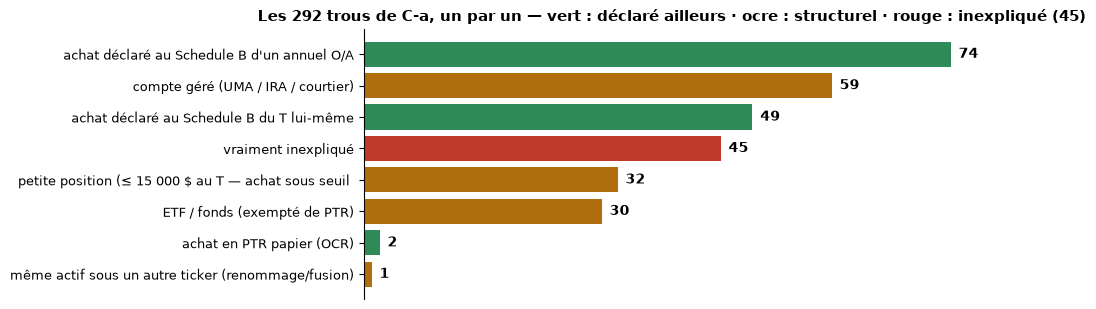

In [50]:
# ── §16.3 Lever 3 : la cascade des causes, position par position ─────────────
_alltx = pd.concat([txns_v1[["bioguide", "ticker", "asset_description"]],
                    ocr_v1[["bioguide", "ticker", "asset_description"]]])
_alltx = _alltx.dropna(subset=["ticker"])
_alltx = _alltx[_alltx["asset_description"].fillna("") != ""]
_desc_bt = _alltx.groupby(["bioguide", "ticker"])["asset_description"].agg(lambda s: s.mode().iloc[0])
_desc_t = _alltx.groupby("ticker")["asset_description"].agg(lambda s: s.mode().iloc[0])

def desc_de(b, tk):
    return str(_desc_bt.get((b, tk), _desc_t.get(tk, "")))

smap16 = pd.read_csv(REFERENCE / "ticker_sector_map.csv", dtype=str)
EST_ETF16 = set(smap16.loc[smap16["asset_class"].str.lower()
                           .str.startswith(("etf", "fund"), na=False), "ticker"])
RE_OPT16 = re.compile(r"\b(option|call|put|warrant)s?\b", re.I)
RE_ETF16 = re.compile(r"\b(etf|ishares|vanguard|spdr|proshares|invesco|index fund|mutual fund)\b", re.I)
RE_GERE16 = re.compile(r"subholding|uma\b|managed|advisor|401|ira\b|brokerage|annuity|merrill|schwab|fidelity", re.I)

_hi = hold_b[hold_b["filing_type"] == "T"].copy()
_hi["value_hi"] = pd.to_numeric(_hi["value_hi"], errors="coerce")
_hi_map = _hi.groupby(["bioguide", "ticker"])["value_hi"].max()

def _norme16(nom):
    return re.sub(r"[^a-z0-9 ]", "", str(nom).lower()).strip()

def _propre(d):
    return "⇒" not in d and not RE_GERE16.search(d)

def cause_du_trou(t):
    b, tk = t["bioguide"], t["ticker"]
    if t["ferme_ocr"]:
        return "achat en PTR papier (OCR)"
    if t["ferme_oa"]:
        return "achat déclaré au Schedule B d'un annuel O/A"
    if t["ferme_t"]:
        return "achat déclaré au Schedule B du T lui-même"
    d = desc_de(b, tk)
    if tk in EST_ETF16 or RE_ETF16.search(d):
        return "ETF / fonds (exempté de PTR)"
    if RE_OPT16.search(d):
        return "option / produit dérivé"
    if RE_GERE16.search(d):
        return "compte géré (UMA / IRA / courtier)"
    nd = _norme16(d)
    if _propre(d) and len(nd) >= 8:
        for tk2 in t["connus"]:
            d2 = desc_de(b, tk2)
            if tk2 != tk and _propre(d2) and _norme16(d2) == nd:
                return "même actif sous un autre ticker (renommage/fusion)"
    if _hi_map.get((b, tk), float("inf")) <= 15000:
        return "petite position (≤ 15 000 $ au T — achat sous seuil plausible)"
    return "vraiment inexpliqué"

FAMILLE = {"achat en PTR papier (OCR)": "déclaré ailleurs",
           "achat déclaré au Schedule B d'un annuel O/A": "déclaré ailleurs",
           "achat déclaré au Schedule B du T lui-même": "déclaré ailleurs",
           "ETF / fonds (exempté de PTR)": "structurel",
           "option / produit dérivé": "structurel",
           "compte géré (UMA / IRA / courtier)": "structurel",
           "même actif sous un autre ticker (renommage/fusion)": "structurel",
           "petite position (≤ 15 000 $ au T — achat sous seuil plausible)": "structurel",
           "vraiment inexpliqué": "vraiment inexpliqué"}
trous_df = pd.DataFrame([dict(bioguide=t["bioguide"], membre=nom_rep.get(t["bioguide"], "?"),
                              ticker=t["ticker"], cause=cause_du_trou(t)) for t in trous])
trous_df["famille"] = trous_df["cause"].map(FAMILLE)
assert len(trous_df) == len(trous) and trous_df["famille"].notna().all()
trous_df.to_csv(TABLES / "annexe_coherence_trous_v1.csv", index=False)
print(trous_df["cause"].value_counts().to_string(), "\n")
print("familles :", trous_df["famille"].value_counts().to_dict())

n_dur = int((trous_df["famille"] == "vraiment inexpliqué").sum())
valider("C-f", "positions de sortie VRAIMENT inexpliquées après la cascade",
        pct(n_dur, DEN_CA), unite="position-ticker",
        perimetre=f"cohorte H∧T élec ({len(ca)} membres), House",
        vert=5.0, orange=8.0, sens="<=", section="§16.3")

fig, ax = plt.subplots(figsize=(10, 3.2))
vc = trous_df["cause"].value_counts()[::-1]
coul = {"déclaré ailleurs": "#2E8B57", "structurel": "#B06E0E", "vraiment inexpliqué": "#C0392B"}
ax.barh(range(len(vc)), vc.values, color=[coul[FAMILLE[c]] for c in vc.index])
ax.set_yticks(range(len(vc)), [c[:52] for c in vc.index], fontsize=9)
for i, v in enumerate(vc.values):
    ax.text(v + 1, i, str(v), va="center", fontsize=10, fontweight="bold")
ax.set_title(f"Les {len(trous_df)} trous de C-a, un par un — "
             f"vert : déclaré ailleurs · ocre : structurel · rouge : inexpliqué ({n_dur})",
             fontsize=11, fontweight="bold")
ax.spines[["top", "right", "bottom"]].set_visible(False); ax.set_xticks([])
plt.tight_layout(); plt.show()

In [51]:
# ── §16.4 Le zoom nominatif : les 3 plus gros porteurs de trous ───────────────
top3 = trous_df["bioguide"].value_counts().head(3)
for b, n in top3.items():
    sous = trous_df[trous_df["bioguide"] == b]
    print(f"{nom_rep.get(b, b)} ({b}) — {n} trous :")
    for cause, k in sous["cause"].value_counts().items():
        print(f"    {k:3d}  {cause}")
print()
print("lecture : Mitchell et Manning déclaraient leurs trades dans les ANNUELS mais pas en "
      "PTR (non-filing documenté) ; Sherrill = ETF et comptes gérés (exemptés/opaques).")
print(f"résidu dur : {int((trous_df['famille'] == 'vraiment inexpliqué').sum())} positions "
      f"({trous_df[trous_df['famille'] == 'vraiment inexpliqué']['bioguide'].nunique()} membres) "
      "— des actions ordinaires jamais déclarées à l'achat, nulle part : le vrai non-filing sec.")
print("\nlimite de couverture (inchangée) : la cohorte C-a = 45 membres H∧T électroniques "
      f"sur {len(bg_type['H'] & bg_type['T'])} membres ayant les deux photos — les autres ont un "
      "H ou T SCANNÉ, jamais parsé. Les OCRiser (devis B3) doublerait la cohorte ; "
      "décision budgétaire séparée.")

Paul Mitchell (M001201) — 43 trous :
     17  achat déclaré au Schedule B d'un annuel O/A
     15  achat déclaré au Schedule B du T lui-même
      9  vraiment inexpliqué
      2  compte géré (UMA / IRA / courtier)
Kathy Manning (M001135) — 28 trous :
     22  achat déclaré au Schedule B d'un annuel O/A
      3  achat déclaré au Schedule B du T lui-même
      2  compte géré (UMA / IRA / courtier)
      1  vraiment inexpliqué
Mikie Sherrill (S001207) — 28 trous :
     12  ETF / fonds (exempté de PTR)
      7  achat déclaré au Schedule B d'un annuel O/A
      6  compte géré (UMA / IRA / courtier)
      3  vraiment inexpliqué

lecture : Mitchell et Manning déclaraient leurs trades dans les ANNUELS mais pas en PTR (non-filing documenté) ; Sherrill = ETF et comptes gérés (exemptés/opaques).
résidu dur : 45 positions (14 membres) — des actions ordinaires jamais déclarées à l'achat, nulle part : le vrai non-filing sec.

limite de couverture (inchangée) : la cohorte C-a = 45 membres H∧T électro

## §17 — B3 : le patrimoine papier, OCRisé (Schedule A + B des H/T/O scannés)

Les photos de patrimoine scannées étaient le dernier angle mort : la cohorte de cohérence
(§11.3, §16) n'exploitait que les 45 membres aux photos **électroniques**. B3 les OCRise
(validé par Alice, plafond ~130 $) :

- **périmètre OCRisé** : les 12 H + 100 T scannés (tous) + les annuels O scannés **≤ 12 pages**
  — 556 documents, cache versionné `reference/ocr_cache_fd_v1/` (Sonnet Vision, contrat
  `record_fd` : Schedule A *holdings* + Schedule B *transactions*) ; coût réel ≈ 50 $ ;
- **exclusions assumées** : 276 gros annuels scannés (> 12 pages — annexes de courtier,
  jusqu'à 2 374 pages, ~267 $ de plus : décision budgétaire séparée) et 3 PDF morts côté
  Clerk (`8214526/27/29`, reliquats 2014 listés dans l'index du site mais aux PDF disparus) ;
- **témoins vérifiés à la main** (Bachmann T 2015 manuscrit, Allen O 2015) — deux pièges
  neutralisés : la **ligne d'exemple pré-imprimée** du formulaire (« Mega Corp Stock »,
  datée 3/5/13) contaminait dates et montants (règle de prompt + la date `2013-03-05`
  est toujours écartée au parse) ; l'**année couverte** d'un annuel est `annee_index`
  même (déposé en N+1) ;
- **limite documentée** : sur les manuscrits denses, les fourchettes de valeur (BLOCK B)
  sont bruitées — elles n'entrent pas dans les tests de cohérence (présence par ticker) ;
- incident technique tracé : sur les très gros lots, le modèle a parfois rendu le JSON
  en *chaîne* (26 documents) — reconstruit intégralement au caractère près
  (`repare_chars: true` dans les JSON), zéro re-dépense.

In [52]:
# ── §17.1 Parser le cache FD OCR → holdings + transactions papier ─────────────
CACHE_FD = REFERENCE / "ocr_cache_fd_v1"

GRILLE_VAL_FD = {
    "none": (0, 0), "$1-$1,000": (1, 1000), "$1,001-$15,000": (1001, 15000),
    "$15,001-$50,000": (15001, 50000), "$50,001-$100,000": (50001, 100000),
    "$100,001-$250,000": (100001, 250000), "$250,001-$500,000": (250001, 500000),
    "$500,001-$1,000,000": (500001, 1000000), "$1,000,001-$5,000,000": (1000001, 5000000),
    "$5,000,001-$25,000,000": (5000001, 25000000),
    "$25,000,001-$50,000,000": (25000001, 50000000), "over $50,000,000": (50000001, None),
    "spouse/dc asset over $1,000,000": (1000001, None),
}
_G_COMP = {re.sub(r"\s+", "", k): v for k, v in GRILLE_VAL_FD.items()}
def _val_fd(lbl):
    if not lbl:
        return None
    return _G_COMP.get(re.sub(r"\s+", "", str(lbl).lower()).replace("–", "-").replace("—", "-"), "?")

# corpus nom→ticker : les descriptions déjà tickérisées de NOS transactions (élec + OCR)
_STOP_FD = re.compile(r"\b(common|stock|shares?|inc|incorporated|corp|corporation|company|co|"
                      r"class [ab]|cmn|the|plc|ltd|holdings?|group|&)\b", re.I)
def _nom_fd(s):
    return re.sub(r"[^a-z0-9 ]", " ", _STOP_FD.sub(" ", str(s or "").lower())).strip()

_all_fd = pd.concat([txns_v1[["ticker", "asset_description"]],
                     ocr_v1[["ticker", "asset_description"]]]).dropna()
_all_fd["nom_n"] = _all_fd["asset_description"].map(_nom_fd)
_all_fd = _all_fd[_all_fd["nom_n"].str.len() >= 4]
_cnt_fd = _all_fd.groupby(["nom_n", "ticker"]).size().reset_index(name="n")
NOM2TK = {}
for _n, _g in _cnt_fd.groupby("nom_n"):
    _g = _g.sort_values("n", ascending=False)
    if _g["n"].iloc[0] >= 2 and _g["n"].iloc[0] >= 0.8 * _g["n"].sum():
        NOM2TK[_n] = _g["ticker"].iloc[0]

def _tk_fd(desc, tk_imp):
    if tk_imp and re.fullmatch(r"[A-Za-z][A-Za-z0-9.\-]{0,5}", str(tk_imp)):
        return str(tk_imp).upper(), "imprime"
    n = _nom_fd(desc)
    return (NOM2TK[n], "corpus") if n in NOM2TK else (None, "aucun")

OWNER_FD = {"Self": "SELF", "Spouse": "SP", "Joint": "JT", "Dependent Child": "DC"}
rows_hf, rows_tf, n_mal = [], [], 0
for pj in sorted(CACHE_FD.rglob("*.json")):
    d = json.loads(pj.read_text())
    for h in d.get("holdings", []):
        if not isinstance(h, dict):
            n_mal += 1; continue
        tk, src = _tk_fd(h.get("asset_description"), h.get("ticker"))
        v = _val_fd(h.get("value_range"))
        rows_hf.append(dict(doc_id=d["doc_id"], filing_type=d["filing_type"],
                            asset_description=h.get("asset_description"), ticker=tk,
                            ticker_source=src, owner=OWNER_FD.get(h.get("owner"), "SELF"),
                            value_range=h.get("value_range"),
                            value_lo=v[0] if isinstance(v, tuple) else None,
                            value_hi=v[1] if isinstance(v, tuple) else None))
    for t_ in d.get("transactions", []):
        if not isinstance(t_, dict):
            n_mal += 1; continue
        tk, src = _tk_fd(t_.get("asset_description"), None)
        dt_ = str(t_.get("transaction_date") or "")
        est_date_exemple = dt_ == "2013-03-05"      # date de la ligne d'exemple pré-imprimée
        ok = bool(re.fullmatch(r"\d{4}-\d{2}-\d{2}", dt_)) and not est_date_exemple
        rows_tf.append(dict(doc_id=d["doc_id"], filing_type=d["filing_type"],
                            asset_description=t_.get("asset_description"), ticker=tk,
                            operation_type=t_.get("transaction_type"),
                            transaction_date=dt_ if ok else None,
                            flag_date_exemple=est_date_exemple,
                            owner=OWNER_FD.get(t_.get("owner"), "SELF")))
hold_fd_ocr = pd.DataFrame(rows_hf)
txns_fd_ocr = pd.DataFrame(rows_tf)
txns_fd_ocr["transaction_date"] = pd.to_datetime(txns_fd_ocr["transaction_date"], errors="coerce")
print(f"dates « 3/5/13 » (ligne d'exemple du formulaire) écartées et FLAGUÉES, pas corrigées : "
      f"{int(txns_fd_ocr['flag_date_exemple'].sum())}")
meta17 = rec_id.loc[~rec_id["doublon_index"], ["doc_id", "bioguide", "filing_date", "annee_index"]]
hold_fd_ocr = hold_fd_ocr.merge(meta17, on="doc_id", how="left")
txns_fd_ocr = txns_fd_ocr.merge(meta17, on="doc_id", how="left")
assert hold_fd_ocr["filing_date"].notna().all(), "doc OCR FD hors recensement !"
hold_fd_ocr.to_csv(TABLES / "08_holdings_fd_ocr.csv", index=False)
txns_fd_ocr.to_csv(TABLES / "09_transactions_fd_ocr.csv", index=False)

n_docs_fd = int(pd.concat([hold_fd_ocr["doc_id"], txns_fd_ocr["doc_id"]]).nunique())
valider("F1", "documents H/T/O scannés OCRisés (périmètre B3 : H+T tous, O ≤ 12 p.)",
        n_docs_fd, unite="document", perimetre="556 docs OCRisés / 835 scannés "
        "(276 gros O + 3 PDF morts exclus), House", section="§17.1")
valider("F2", "holdings papier tickérisés (imprimé + corpus nom→ticker)",
        pct(int(hold_fd_ocr["ticker"].notna().sum()), len(hold_fd_ocr)),
        unite="holding", perimetre="Schedule A OCR — le reste = fonds/comptes/immobilier",
        section="§17.1")
_vv = hold_fd_ocr["value_range"].notna()
_vok = hold_fd_ocr["value_lo"].notna() | (hold_fd_ocr["value_range"].str.lower() == "none")
valider("F3", "fourchettes de valeur reconnues dans la grille officielle",
        pct(int((_vv & _vok).sum()), int(_vv.sum())), unite="holding",
        perimetre="Schedule A OCR avec valeur lue", vert=90.0, orange=80.0, section="§17.1")
print(f"{n_docs_fd} docs → {len(hold_fd_ocr)} holdings + {len(txns_fd_ocr)} txns papier "
      f"({n_mal} fragments non structurés ignorés — cf. réparation)")

dates « 3/5/13 » (ligne d'exemple du formulaire) écartées et FLAGUÉES, pas corrigées : 2
ℹ️ [F1] documents H/T/O scannés OCRisés (périmètre B3 : H+T tous, O ≤ 12 p.) = 526  (document · 556 docs OCRisés / 835 scannés (276 gros O + 3 PDF morts exclus), House · 2014-2026)
ℹ️ [F2] holdings papier tickérisés (imprimé + corpus nom→ticker) = 26.3  (holding · Schedule A OCR — le reste = fonds/comptes/immobilier · 2014-2026)
🟢 [F3] fourchettes de valeur reconnues dans la grille officielle = 97.5  (holding · Schedule A OCR avec valeur lue · 2014-2026)
526 docs → 15489 holdings + 9454 txns papier (0 fragments non structurés ignorés — cf. réparation)


In [53]:
# ── §17.2 La cohorte de cohérence, élargie aux photos papier ──────────────────
photos_ocr = hold_fd_ocr[hold_fd_ocr["filing_type"].isin(["H", "T"])].dropna(subset=["ticker"])
photos_ocr = photos_ocr[~photos_ocr["ticker"].str.fullmatch(EST_FONDS)]
photos17 = pd.concat([
    hold_b[["bioguide", "filing_type", "ticker", "filing_date"]],
    photos_ocr[["bioguide", "filing_type", "ticker", "filing_date"]]])

H17 = photos17[photos17["filing_type"] == "H"].groupby("bioguide")["filing_date"].min()
T17 = photos17[photos17["filing_type"] == "T"].groupby("bioguide")["filing_date"].max()
cohorte17 = sorted(b for b in set(H17.index) & set(T17.index) if H17[b] < T17[b])
# gardes de NON-RÉGRESSION réelles (pas la tautologie ensembliste) :
# (a) les fenêtres [H,T] des 45 membres élec ne doivent pas avoir bougé avec l'ajout des
#     photos papier — si un jour un H/T papier antérieur apparaît, ce doit être VISIBLE ;
# (b) le dénominateur ne peut que croître.
fenetres_bougees = [b for b in cohorte if H17[b] != H_[b] or T17[b] != T_[b]]
assert not fenetres_bougees, f"fenêtres élec déplacées par l'OCR : {fenetres_bougees}"
nouveaux17 = sorted(set(cohorte17) - set(cohorte))
print(f"cohorte élargie : {len(cohorte17)} membres = {len(cohorte)} (élec) + "
      f"{len(nouveaux17)} nouveaux via l'OCR : "
      f"{', '.join(nom_rep.get(b, b) for b in nouveaux17)}")

fd_achats17 = txns_v1[txns_v1["provenance"].isin(["fd_O", "fd_A", "fd_T"])
                      & txns_v1["operation_type"].str.startswith("Purchase")
                      & txns_v1["bioguide"].notna() & txns_v1["ticker"].notna()]
fd_ocr_achats17 = txns_fd_ocr[txns_fd_ocr["operation_type"].str.startswith("Purchase", na=False)
                              & txns_fd_ocr["bioguide"].notna() & txns_fd_ocr["ticker"].notna()
                              & txns_fd_ocr["transaction_date"].notna()]
lignes17 = []
for b in cohorte17:
    E = set(photos17[(photos17["bioguide"] == b) & (photos17["filing_type"] == "H")]["ticker"])
    S = set(photos17[(photos17["bioguide"] == b) & (photos17["filing_type"] == "T")]["ticker"])
    if not S:
        continue
    def _A17(df, col="transaction_date"):
        m = df[(df["bioguide"] == b) & (df[col] >= H17[b]) & (df[col] <= T17[b])]
        return set(m["ticker"].dropna())
    A1 = _A17(achats_sig) | _A17(ocr_achats)
    A2 = A1 | _A17(fd_achats17) | _A17(fd_ocr_achats17)
    lignes17.append(dict(bioguide=b, n=len(S), inx1=len(S - E - A1), inx2=len(S - E - A2)))
ca17 = pd.DataFrame(lignes17)
den17 = int(ca17["n"].sum())
assert den17 >= int(ca["n_sortie"].sum()), "le dénominateur élargi ne peut pas rétrécir"
valider("F4", "positions de sortie expliquées — cohorte ÉLARGIE, achats PTR élec+OCR",
        pct(den17 - int(ca17["inx1"].sum()), den17), unite="position-ticker",
        perimetre=f"cohorte H∧T élec∪OCR ({len(ca17)} membres), House", vert=75.0,
        orange=65.0, section="§17.2")
valider("F5", "… toutes déclarations d'achat (+ Schedule B élec ET papier)",
        pct(den17 - int(ca17["inx2"].sum()), den17), unite="position-ticker",
        perimetre=f"cohorte H∧T élec∪OCR ({len(ca17)} membres), House", vert=80.0,
        orange=70.0, section="§17.2")
print(f"la conclusion du §16 TIENT sur la cohorte élargie ({den17} positions) — "
      "l'essentiel des trous reste du non-filing documenté + du structurel")

cohorte élargie : 49 membres = 45 (élec) + 4 nouveaux via l'OCR : Bob Dold, Frank Guinta, Brenda Lawrence, Dave Trott


🟢 [F4] positions de sortie expliquées — cohorte ÉLARGIE, achats PTR élec+OCR = 78.3  (position-ticker · cohorte H∧T élec∪OCR (49 membres), House · 2014-2026)
🟢 [F5] … toutes déclarations d'achat (+ Schedule B élec ET papier) = 87.1  (position-ticker · cohorte H∧T élec∪OCR (49 membres), House · 2014-2026)
la conclusion du §16 TIENT sur la cohorte élargie (1420 positions) — l'essentiel des trous reste du non-filing documenté + du structurel


ℹ️ [F6] membres H∧T dont le patrimoine reste SANS action tickérisée = 54  (membre · 106 membres à double photo — fonds/comptes/immobilier uniquement : invisibles à un suivi par ticker · 2014-2026)


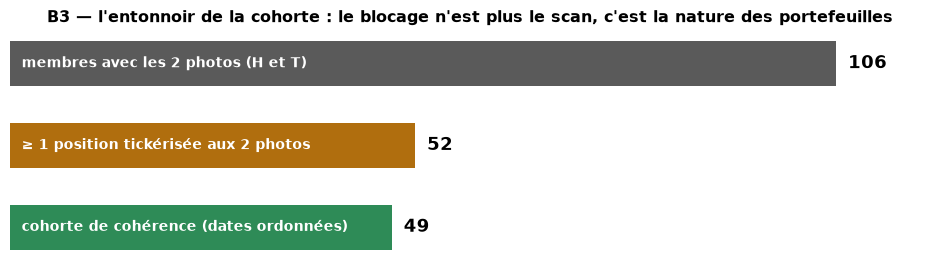

lecture : après B3, presque tous les membres à double photo sont LUS — mais 54 sur 106 ne détiennent aucune action tickérisable (fonds, comptes gérés, immobilier). La cohorte par ticker plafonne structurellement ; l'étape au-delà serait un appariement par NOM d'actif.


In [54]:
# ── §17.3 L'entonnoir honnête : pourquoi 49 membres, et pas 106 ? ─────────────
bgH_all = set(rec_id.loc[(rec_id["filing_type"] == "H") & rec_id["bioguide"].notna(), "bioguide"])
bgT_all = set(rec_id.loc[(rec_id["filing_type"] == "T") & rec_id["bioguide"].notna(), "bioguide"])
les106 = bgH_all & bgT_all
tk_H = set(photos17.loc[photos17["filing_type"] == "H", "bioguide"])
tk_T = set(photos17.loc[photos17["filing_type"] == "T", "bioguide"])
deux_photos_tk = les106 & tk_H & tk_T
valider("F6", "membres H∧T dont le patrimoine reste SANS action tickérisée",
        len(les106 - deux_photos_tk), unite="membre",
        perimetre=f"{len(les106)} membres à double photo — fonds/comptes/immobilier "
        "uniquement : invisibles à un suivi par ticker", section="§17.3")

fig, ax = plt.subplots(figsize=(9.5, 2.8))
etapes = [(f"membres avec les 2 photos (H et T)", len(les106)),
          (f"≥ 1 position tickérisée aux 2 photos", len(deux_photos_tk)),
          (f"cohorte de cohérence (dates ordonnées)", len(ca17))]
y = range(len(etapes))[::-1]
ax.barh(list(y), [e[1] for e in etapes], 0.55,
        color=["#5A5A5A", "#B06E0E", "#2E8B57"])
for yy, (lab, v) in zip(y, etapes):
    ax.text(v + 1.5, yy, f"{v}", va="center", fontsize=13, fontweight="bold")
    ax.text(1.5, yy, lab, va="center", fontsize=10, color="white", fontweight="bold")
ax.set_yticks([]); ax.set_xticks([]); ax.set_xlim(0, 118)
ax.spines[["top", "right", "bottom", "left"]].set_visible(False)
ax.set_title("B3 — l'entonnoir de la cohorte : le blocage n'est plus le scan, "
             "c'est la nature des portefeuilles", fontsize=11.5, fontweight="bold")
plt.tight_layout(); plt.show()
print("lecture : après B3, presque tous les membres à double photo sont LUS — mais "
      f"{len(les106 - deux_photos_tk)} sur {len(les106)} ne détiennent aucune action "
      "tickérisable (fonds, comptes gérés, immobilier). La cohorte par ticker plafonne "
      "structurellement ; l'étape au-delà serait un appariement par NOM d'actif.")

## §13 — Le tableau de bord : toutes les validations, une ligne chacune

Chaque contrôle du notebook a laissé une trace au registre — les voici toutes, avec leurs
trois étiquettes (unité · périmètre · fenêtre). Les **bloquantes** ont déjà prouvé leur
passage (le notebook se serait arrêté sinon).

In [55]:
# ── §13.1 Le registre en tableau ─────────────────────────────────────────────
reg = pd.DataFrame(REGISTRE)
ICONES = {"VERT": "🟢", "ORANGE": "🟠", "ROUGE": "🔴", "INFO": "ℹ️"}
reg["état"] = reg["verdict"].map(ICONES)
aff = reg[["id", "nom", "valeur", "unite", "perimetre", "fenetre", "état", "bloquant", "section"]]
display(aff)
n_rouge = int((reg["verdict"] == "ROUGE").sum())
n_orange = int((reg["verdict"] == "ORANGE").sum())
print(f"{len(reg)} validations · 🔴 {n_rouge} · 🟠 {n_orange}")

,id,nom,valeur,unite,perimetre,fenetre,état,bloquant,section
0,L2a,DocID listés dans deux index (lignes doublonnées),18.0,document,"tous types, House",2014-2026,🟢,False,§1.3
1,D1,part des PTR numériques (préfixe 2),70.7,document,"P, House",2014-2026,🟢,False,§2.1
2,L1,partition du ledger == recensement,1.0,document,"tous types, House",2014-2026,🟢,True,§3.1
3,P1,preuve continue : sha identique au re-téléchar...,20.0,document,échantillon aléatoire n=20,2014-2026,🟢,False,§4.2
4,L4,désaccords préfixe × contenu (numérique sans t...,0.0,document,"docs en cache, types en périmètre",2014-2026,🟢,False,§5.2
5,R1,PTR numériques lisibles avec ≥1 transaction,100.0,document,"P élec texte_ok, House",2014-2026,🟢,False,§7.3
6,R2,rapports FD lisibles découpés en sections,100.0,document,"C/O/H/T/A élec texte_ok, House",2014-2026,🟢,False,§8.4
7,I1-P,dépôts P rattachés à un bioguide,99.9,document,"P, House",2014-2026,🟢,False,§9.3
8,I1-O,dépôts O rattachés à un bioguide,98.9,document,"O, House",2014-2026,🟢,False,§9.3
9,I1-H,dépôts H rattachés à un bioguide,99.2,document,"H, House",2014-2026,🟢,False,§9.3


54 validations · 🔴 0 · 🟠 4


In [56]:
# ── §13.2 MANIFEST du run ────────────────────────────────────────────────────
manifest = {
    "cache_version": 1,
    "flags": {"PREFILL_FROM_OLD": PREFILL_FROM_OLD, "FULL_REDOWNLOAD": FULL_REDOWNLOAD,
              "INCLURE_C": INCLURE_C},
    "sha_index": sha_index,
    "comptes": {
        "recensement": len(recensement),
        "ledger": len(ledger),
        "pdf_en_cache": len(inventaire),
        "transactions_v1": len(txns_v1),
        "transactions_signal_ptr": int((txns_v1["provenance"] == "ptr").sum()),
        "holdings_v1": len(holdings),
        "declarants_rattaches": int(decl["bioguide"].notna().sum()),
    },
    "statuts_ledger": {k: int(v) for k, v in ledger["statut"].value_counts().items()},
    "validations": {r["id"]: {"valeur": (float(r["valeur"]) if isinstance(r["valeur"], (int, float))
                                          else str(r["valeur"])),
                              "verdict": r["verdict"]} for r in REGISTRE},
}
tables_sha = {}
for f in sorted(TABLES.glob("*.csv")):
    tables_sha[f.name] = hashlib.sha256(f.read_bytes()).hexdigest()
manifest["sha_tables"] = tables_sha
(CACHE / "MANIFEST.json").write_text(json.dumps(manifest, indent=2, ensure_ascii=False))
print(f"MANIFEST écrit → {CACHE/'MANIFEST.json'}")
print(json.dumps(manifest["comptes"], indent=2, ensure_ascii=False))

MANIFEST écrit → cache/MANIFEST.json
{
  "recensement": 35377,
  "ledger": 35359,
  "pdf_en_cache": 24078,
  "transactions_v1": 166149,
  "transactions_signal_ptr": 56002,
  "holdings_v1": 198615,
  "declarants_rattaches": 1443
}
